## Model Loading

In [ ]:
import torch
from pathlib import Path
import sys

# 루트 경로 추가 (Model, dataset 로딩 위해)
root_dir = Path('/storage/personal/eungyeop/LLM/tabular/ProtoLLM')
sys.path.append(str(root_dir))

from models.TabularFLM_S import Model
from dataset.data_dataloaders import prepare_embedding_dataloaders
from utils.util import fix_seed
from ot.batch import solve_gromov_batch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


#ckpt_path = "/storage/personal/eungyeop/experiments/checkpoints/gpt2_mean/heart+Cardiovascular_Disease_Dataset+Heart_disease_statlog+Erbil_Cardiovascular_Health_Dataset+heart_failure_clinical_records+cardio_SAheart/Pre/ngraphs-8_nnodes-8_gdim-768_nbasis-2_basis-ind_attn-gat_v1_struct_hidden_dim-192_fgw_alpha-1_alpha-0.7_vq_beta-0.2_kl_gamma-2.0_tau-0.2_target_data-Medicaldataset_entropic_reg-0.01_description-None/50/20260128_122753/best.pt"
#ckpt_path = "/storage/personal/eungyeop/experiments/checkpoints/gpt2_mean/heart+Cardiovascular_Disease_Dataset+Heart_disease_statlog+Erbil_Cardiovascular_Health_Dataset+heart_failure_clinical_records+cardio_SAheart/Pre/ngraphs-8_nnodes-8_gdim-768_nbasis-2_basis-ind_attn-gat_v1_struct_hidden_dim-192_fgw_alpha-1_alpha-0.7_vq_beta-0.2_kl_gamma-2.0_tau-0.2_target_data-Medicaldataset_entropic_reg-0.01_description-Regularization2/50/20260202_173939/best.pt"
#ckpt_path = "/storage/personal/eungyeop/experiments/checkpoints/gpt2_mean/heart+Cardiovascular_Disease_Dataset+Heart_disease_statlog+Erbil_Cardiovascular_Health_Dataset+heart_failure_clinical_records+cardio_SAheart/Pre/ngraphs-8_nnodes-8_gdim-768_nbasis-2_basis-ind_attn-gat_v1_struct_hidden_dim-192_fgw_alpha-1_alpha-0.7_vq_beta-0.2_kl_gamma-2.0_tau-0.2_target_data-Medicaldataset_entropic_reg-0.1_description-Regularization3/50/20260202_211809/best.pt"

#joint_ckpt_pretrain_path = "/storage/personal/eungyeop/experiments/checkpoints/gpt2_mean/heart+Cardiovascular_Disease_Dataset+Heart_disease_statlog+Erbil_Cardiovascular_Health_Dataset+heart_failure_clinical_records+cardio_SAheart/Pre/ngraphs-8_nnodes-8_gdim-768_nbasis-2_basis-ind_attn-gat_v1_struct_hidden_dim-192_fgw_alpha-1_alpha-0.7_vq_beta-0.2_kl_gamma-2.0_tau-0.2_target_data-Medicaldataset_entropic_reg-0.01_description-None/50/20260128_122753/best_joint.pt"
#joint_ckpt_pretrain_path = "/storage/personal/eungyeop/experiments/checkpoints/gpt2_mean/heart+Cardiovascular_Disease_Dataset+Heart_disease_statlog+Erbil_Cardiovascular_Health_Dataset+heart_failure_clinical_records+cardio_SAheart/Pre/ngraphs-8_nnodes-8_gdim-768_nbasis-2_basis-ind_attn-gat_v1_struct_hidden_dim-192_fgw_alpha-1_alpha-0.7_vq_beta-0.2_kl_gamma-2.0_tau-0.2_target_data-Medicaldataset_entropic_reg-0.01_description-Regularization2/50/20260202_173939/best_joint.pt"
#joint_ckpt_pretrain_path = "/storage/personal/eungyeop/experiments/checkpoints/gpt2_mean/heart+Cardiovascular_Disease_Dataset+Heart_disease_statlog+Erbil_Cardiovascular_Health_Dataset+heart_failure_clinical_records+cardio_SAheart/Pre/ngraphs-8_nnodes-8_gdim-768_nbasis-2_basis-ind_attn-gat_v1_struct_hidden_dim-192_fgw_alpha-1_alpha-0.7_vq_beta-0.2_kl_gamma-2.0_tau-0.2_target_data-Medicaldataset_entropic_reg-0.1_description-Regularization3/50/20260202_211809/best_joint.pt"
#ckpt_path = joint_ckpt_pretrain_path

#target_rr_ckpt_path = "/storage/personal/eungyeop/experiments/checkpoints/gpt2_mean/heart+Cardiovascular_Disease_Dataset+Heart_disease_statlog+Erbil_Cardiovascular_Health_Dataset+heart_failure_clinical_records+cardio_SAheart/Few/ngraphs-8_nnodes-8_gdim-768_nbasis-2_basis-ind_attn-gat_v1_struct_hidden_dim-192_fgw_alpha-1_alpha-0.7_vq_beta-0.2_kl_gamma-2.0_tau-0.2_target_data-Medicaldataset_entropic_reg-0.01_description-None/50/20260128_122753/Embed:carte_Edge:mlp_A:gat_v1_S:50_20260128_122753.pt"
target_rr_ckpt_path = "/storage/personal/eungyeop/experiments/checkpoints/gpt2_mean/heart+Cardiovascular_Disease_Dataset+Heart_disease_statlog+Erbil_Cardiovascular_Health_Dataset+heart_failure_clinical_records+cardio_SAheart/Few/ngraphs-8_nnodes-8_gdim-768_nbasis-2_basis-ind_attn-gat_v1_struct_hidden_dim-192_fgw_alpha-1_alpha-0.7_vq_beta-0.2_kl_gamma-2.0_tau-0.2_target_data-Medicaldataset_entropic_reg-0.1_description-Regularization3/50/20260202_211809/Embed:carte_Edge:mlp_A:gat_v1_S:50_20260202_211809.pt"
# checkpoint load
ckpt = torch.load(ckpt_path, map_location=device)
args = ckpt['args']

# 모델 초기화
model = Model(
    args,
    args.input_dim,
    args.hidden_dim,
    args.output_dim,
    args.dropout_rate,
    args.llm_model,
    experiment_id="viz",
    mode="viz"
).to(device)

sd = ckpt['model_state_dict']
missing, unexpected = model.load_state_dict(sd, strict=False)
print("Missing keys:", missing)
print("Unexpected keys:", unexpected)

model.eval()


/home/eungyeop/anaconda3/envs/protollm/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Missing keys: []
Unexpected keys: ['latent_graph.init_node_embeddings', 'latent_graph.init_adj_param']


Model(
  (latent_graph): LatentCompositeGraph()
  (graph_quantizer): GraphQuantizer()
  (gnn_experts): LatentCompositeGNN(
    (graph_gnns): ModuleList(
      (0-7): 8 x lightGraphNeuralNet(
        (dropout): Dropout(p=0.1, inplace=False)
        (linear): Linear(in_features=768, out_features=192, bias=True)
        (update): Linear(in_features=192, out_features=768, bias=True)
        (norm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      )
    )
    (readouts): ModuleList(
      (0-7): 8 x GraphReadout(
        (proj): Sequential(
          (0): Linear(in_features=768, out_features=192, bias=True)
          (1): ReLU()
          (2): Dropout(p=0.1, inplace=False)
          (3): Linear(in_features=192, out_features=768, bias=True)
        )
        (norm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      )
    )
  )
  (basis_layers): ModuleList(
    (0-1): 2 x BasisGATLayer_IND(
      (attn_dropout): Dropout(p=0.1, inplace=False)
      (q_proj_list): ModuleLis

## Source Loading

In [2]:
args2 = args
fix_seed(args2.random_seed)

# source_data가 리스트일 경우 여러 개
sources = args2.source_data if isinstance(args2.source_data, (list, tuple)) else [args2.source_data]

loaders = {}
for src in sources:
    print(f"Loading dataloader for source: {src}")
    res = prepare_embedding_dataloaders(args2, src)
    tr, va, te = res['loaders']
    
    from torch.utils.data import ConcatDataset, DataLoader
    ds = ConcatDataset([tr.dataset, va.dataset, te.dataset])
    
    loaders[src] = DataLoader(ds, batch_size=32, shuffle=False)


>>> [System] Seed 42 FIXED. Deterministic algorithms ENABLED.
Loading dataloader for source: Medicaldataset
Loading embeddings from: /storage/personal/eungyeop/dataset/embedding/tabular_embeddings_carte/gpt2_mean/embedding_Medicaldataset.pkl
>>> [DataLoader] Created isolated generator with seed 42
Training data size: 791
Validation data size: 264
Test data size: 264
Loading dataloader for source: Cardiovascular_Disease_Dataset
Loading embeddings from: /storage/personal/eungyeop/dataset/embedding/tabular_embeddings_carte/gpt2_mean/embedding_Cardiovascular_Disease_Dataset.pkl
>>> [DataLoader] Created isolated generator with seed 42
Training data size: 600
Validation data size: 200
Test data size: 200
Loading dataloader for source: Heart_disease_statlog
Loading embeddings from: /storage/personal/eungyeop/dataset/embedding/tabular_embeddings_carte/gpt2_mean/embedding_Heart_disease_statlog.pkl
>>> [DataLoader] Created isolated generator with seed 42
Training data size: 162
Validation data s

In [3]:
import torch.nn.functional as F

@torch.no_grad()
def extract_basis_attention_and_embedding(model, batch):
    batch = {k: (v.to(device) if isinstance(v, torch.Tensor) else v) for k, v in batch.items()}

    # desc/name/value gather
    desc_embeddings, name_embeddings, value_embeddings = [], [], []
    if all(k in batch for k in ['cat_name_embeddings', 'cat_value_embeddings', 'cat_desc_embeddings']):
        desc_embeddings.append(batch['cat_desc_embeddings'])
        name_embeddings.append(batch['cat_name_embeddings'])
        value_embeddings.append(batch['cat_value_embeddings'])
    if all(k in batch for k in ['num_prompt_embeddings', 'num_desc_embeddings']):
        desc_embeddings.append(batch['num_desc_embeddings'])
        name_embeddings.append(batch['num_name_embeddings'])
        value_embeddings.append(batch['num_prompt_embeddings'])

    desc = torch.cat(desc_embeddings, dim=1)
    name = torch.cat(name_embeddings, dim=1)
    value = torch.cat(value_embeddings, dim=1)

    # CLS + value token concat
    x_basis = torch.cat([model.basis_cls.expand(value.size(0), 1, model.input_dim), value], dim=1)

    attentions = []

    # each BasisGAT layer
    for l in range(model.num_basis_layers):
        norm_x = model.basis_layer_norms[l](x_basis)
        basis_outputs, att = model.basis_layers[l](name, norm_x)
        
        # attention shape: [B, H, T, T]
        attentions.append(att[0].detach().cpu().numpy())
        
        x_basis = x_basis + basis_outputs.reshape(x_basis.size(0), x_basis.size(1), model.input_dim)

    embeddings = x_basis[0].detach().cpu().numpy()  # CLS+tokens, shape [T, D]
    return attentions, embeddings

import matplotlib.pyplot as plt
import numpy as np
import os
def plot_attention_heatmap(att, feature_names, title):
    H, T, _ = att.shape
    # ---- Bigger, readable figure ----
    figsize_x = max(8, T * 0.8)  # at least width 8
    figsize_y = max(4, H * 3)    # at least height 4

    plt.figure(figsize=(figsize_x, figsize_y))

    for h in range(H):
        plt.subplot(1, H, h+1)
        plt.imshow(att[h], cmap='viridis')

        plt.xticks(range(T), feature_names, rotation=90, fontsize=10)
        plt.yticks(range(T), feature_names, fontsize=10)

        plt.title(f"{title} - Head {h}", fontsize=14)
        plt.colorbar()

    plt.tight_layout()
    plt.show()
from sklearn.manifold import TSNE

def plot_embedding_tsne(emb):
    # emb: [T, D]
    tsne = TSNE(n_components=2, perplexity=10, learning_rate=100)
    xy = tsne.fit_transform(emb)

    plt.figure(figsize=(6, 6))
    plt.scatter(xy[:, 0], xy[:, 1])
    for i in range(xy.shape[0]):
        plt.text(xy[i,0], xy[i,1], str(i), fontsize=8)
    plt.title("t-SNE of embeddings (CLS + features)")
    plt.show()

# ---- viz utilities ----
def set_attention_save_dir( experiment_id, mode):
    base_viz_dir = f"/storage/personal/eungyeop/experiments/visualization/{args.llm_model}/{args.source_data}/{mode}/{experiment_id}"
    attention_save_dir = os.path.join(base_viz_dir, 'attention_maps')
    os.makedirs(attention_save_dir, exist_ok=True)

def extract_feature_names( batch):
    names = []
    if 'cat_desc_texts' in batch:
        for t in batch['cat_desc_texts']:
            names.append(str(t[0] if isinstance(t, tuple) else t).split(",")[0].split("'")[0])
    if 'num_desc_texts' in batch:
        for t in batch['num_desc_texts']:
            names.append(str(t[0] if isinstance(t, tuple) else t).split(",")[0].split("'")[0])
    uniq = []
    seen = set()
    for n in names:
        if n not in seen:
            seen.add(n); uniq.append(n)
    return uniq

def save_attention_maps_to_file( attention_weights, batch, labels=None, sample_ids=None):
    if attention_save_dir is None:
        return
    node_names = ["CLS"] + extract_feature_names(batch)
    for layer_idx, layer_attention in enumerate(attention_weights):
        B = layer_attention.shape[0]
        for b in range(B):
            att = layer_attention[b].mean(dim=0).detach().cpu().numpy()
            sid = sample_ids[b] if sample_ids is not None else attention_counter
            lab = labels[b].item() if labels is not None else "unknown"
            np.savez(os.path.join(attention_save_dir, f"layer_{layer_idx}_sample_{sid}_label_{lab}.npz"),
                        attention_map=att, feature_names=np.array(node_names),
                        layer_idx=layer_idx, sample_id=sid, label=lab)
            attention_counter += 1

import numpy as np

def summarize_embedding_stats(emb, feature_names):
    """
    emb: numpy array [T, D]
    feature_names: list of T names ("CLS" + variable names)
    """
    T, D = emb.shape
    
    print("=== Embedding statistics per token (CLS + features) ===")
    stats = {}
    
    for i in range(T):
        vec = emb[i]
        mean = vec.mean()
        std = vec.std()
        
        stats[feature_names[i]] = {
            'mean': float(mean),
            'std': float(std)
        }
        print(f"{feature_names[i]:>15}  | mean={mean:.4f} | std={std:.4f}")
    
    # 전체 embedding 분포 요약
    print("\n=== Global embedding statistics ===")
    print(f"global mean: {emb.mean():.4f}")
    print(f"global std : {emb.std():.4f}")
    
    return stats

import matplotlib.pyplot as plt
import numpy as np

def plot_attention_with_inverse(
    att,
    feature_names,
    title="Attention",
    value_fontsize=6,
    tick_fontsize=8,
    title_fontsize=12,
    figsize_scale=1.0,
):
    H, T, _ = att.shape

    figsize_x = max(10, T * 0.7) * figsize_scale
    figsize_y = max(5, H * 3) * figsize_scale

    fig, axes = plt.subplots(H, 2, figsize=(figsize_x, figsize_y))
    if H == 1:
        axes = np.expand_dims(axes, 0)

    cmap = "viridis"

    for h in range(H):
        # ---- LEFT: Attention ----
        left_vmin = att[h].min()
        left_vmax = att[h].max()

        ax = axes[h, 0]
        im = ax.imshow(att[h], cmap=cmap, vmin=left_vmin, vmax=left_vmax)
        ax.set_title(f"{title} - Head {h}", fontsize=title_fontsize)

        ax.set_xticks(range(T))
        ax.set_yticks(range(T))
        ax.set_xticklabels(feature_names, rotation=90, fontsize=tick_fontsize)
        ax.set_yticklabels(feature_names, fontsize=tick_fontsize)

        for i in range(T):
            for j in range(T):
                ax.text(j, i, f"{att[h, i, j]:.2f}",
                        ha="center", va="center",
                        fontsize=value_fontsize,
                        color="white" if att[h, i, j] > (left_vmin+left_vmax)/2 else "black")

        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.02)

        # ---- RIGHT: (1 - Attention) ----
        inv = 1 - att[h]
        right_vmin = inv.min()
        right_vmax = inv.max()

        ax2 = axes[h, 1]
        im2 = ax2.imshow(inv, cmap=cmap, vmin=right_vmin, vmax=right_vmax)
        ax2.set_title(f"(1 - Attention) - Head {h}", fontsize=title_fontsize)

        ax2.set_xticks(range(T))
        ax2.set_yticks(range(T))
        ax2.set_xticklabels(feature_names, rotation=90, fontsize=tick_fontsize)
        ax2.set_yticklabels(feature_names, fontsize=tick_fontsize)

        for i in range(T):
            for j in range(T):
                ax2.text(j, i, f"{inv[i, j]:.2f}",
                         ha="center", va="center",
                         fontsize=value_fontsize,
                         color="white" if inv[i, j] > (right_vmin+right_vmax)/2 else "black")

        fig.colorbar(im2, ax=ax2, fraction=0.046, pad=0.02)

    plt.tight_layout()
    plt.show()


## Source 1 attention map Loading

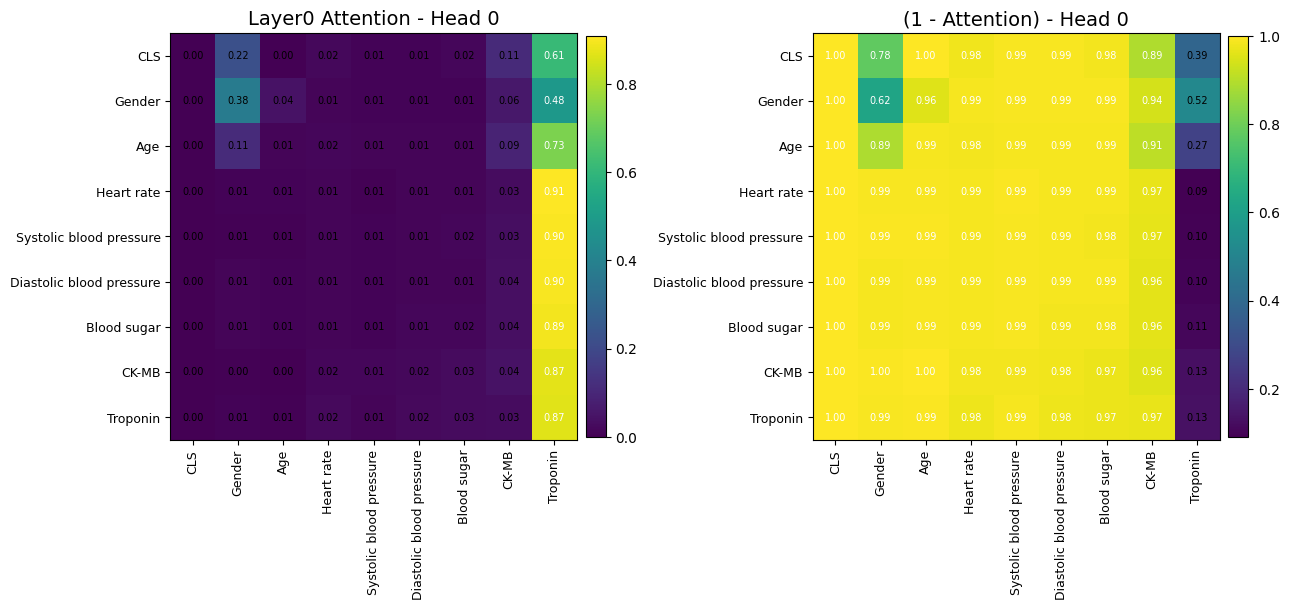

=== Embedding statistics per token (CLS + features) ===
            CLS  | mean=0.0135 | std=0.3489
         Gender  | mean=0.0378 | std=2.3892
            Age  | mean=0.0397 | std=1.8443
     Heart rate  | mean=0.0752 | std=1.7994
Systolic blood pressure  | mean=0.0949 | std=2.1245
Diastolic blood pressure  | mean=0.0583 | std=1.3593
    Blood sugar  | mean=0.3669 | std=8.7036
          CK-MB  | mean=-0.3402 | std=6.9477
       Troponin  | mean=-0.1676 | std=3.5171

=== Global embedding statistics ===
global mean: 0.0198
global std : 4.1569


In [4]:
src = sources[0]   # 첫 source
loader = loaders[src]

batch = next(iter(loader))

atts, emb = extract_basis_attention_and_embedding(model, batch)

# feature names 가져오기
var_names = extract_feature_names(batch)
feature_names = ["CLS"] + var_names

# 첫 layer attention 시각화
#plot_attention_heatmap(atts[0], feature_names, "Layer0 Attention")
plot_attention_with_inverse(
    att=atts[0],
    feature_names=feature_names,
    title="Layer0 Attention",
    value_fontsize=7,
    tick_fontsize=9,
    title_fontsize=14,
    figsize_scale=1.3,
)
stats = summarize_embedding_stats(emb, feature_names)



## Affinity Two sample

In [5]:
import numpy as np
from collections import defaultdict
@torch.no_grad()
def collect_all_samples_from_source(model, loader, source_name):
    """
    한 source의 모든 샘플에 대해 node embedding과 affinity 추출
    
    Returns:
        all_embeddings: list of [N, D] arrays (CLS 제외한 variable nodes만)
        all_affinities: list of [N, N] arrays (1 - attention, Var-Var만)
        all_labels: list of labels
        all_feature_names: list of feature name lists
    """
    all_embeddings = []
    all_affinities = []
    all_labels = []
    all_feature_names = []
    
    for batch in loader:
        batch = {k: (v.to(device) if isinstance(v, torch.Tensor) else v) for k, v in batch.items()}
        
        # desc/name/value gather
        desc_embeddings, name_embeddings, value_embeddings = [], [], []
        if all(k in batch for k in ['cat_name_embeddings', 'cat_value_embeddings', 'cat_desc_embeddings']):
            desc_embeddings.append(batch['cat_desc_embeddings'])
            name_embeddings.append(batch['cat_name_embeddings'])
            value_embeddings.append(batch['cat_value_embeddings'])
        if all(k in batch for k in ['num_prompt_embeddings', 'num_desc_embeddings']):
            desc_embeddings.append(batch['num_desc_embeddings'])
            name_embeddings.append(batch['num_name_embeddings'])
            value_embeddings.append(batch['num_prompt_embeddings'])

        name = torch.cat(name_embeddings, dim=1)
        value = torch.cat(value_embeddings, dim=1)
        
        B = value.size(0)

        # CLS + value token concat
        x_basis = torch.cat([model.basis_cls.expand(B, 1, model.input_dim), value], dim=1)

        last_att = None
        
        # each BasisGAT layer
        for l in range(model.num_basis_layers):
            norm_x = model.basis_layer_norms[l](x_basis)
            basis_outputs, att = model.basis_layers[l](name, norm_x)
            
            # attention shape: [B, H, T, T]
            last_att = att
            
            x_basis = x_basis + basis_outputs.reshape(x_basis.size(0), x_basis.size(1), model.input_dim)

        # last_att: [B, H, T, T]
        # Head 0 사용
        last_att = last_att[:, 0, :, :]  # [B, T, T]
        
        # Feature names
        var_names = extract_feature_names(batch)
        
        for b in range(B):
            # CLS 제외 (1:부터)
            node_emb = x_basis[b, 1:, :].detach().cpu().numpy()  # [N, D]
            
            # Var-Var attention만 (CLS 제외)
            var_att = last_att[b, 1:, 1:].detach().cpu().numpy()  # [N, N]
            
            # 1 - attention = distance/affinity
            affinity = 1.0 - var_att
            
            all_embeddings.append(node_emb)
            all_affinities.append(affinity)
            all_labels.append(batch['y'][b].item())
            all_feature_names.append(var_names)
    
    return all_embeddings, all_affinities, all_labels, all_feature_names

def compute_frobenius_distances(embeddings, affinities):
    """
    모든 샘플 쌍의 Frobenius distance 계산
    
    Returns:
        emb_distances: [n_samples, n_samples] embedding Frobenius distances
        aff_distances: [n_samples, n_samples] affinity Frobenius distances
    """
    n = len(embeddings)
    emb_distances = np.zeros((n, n))
    aff_distances = np.zeros((n, n))
    
    for i in range(n):
        for j in range(i+1, n):
            # Embedding Frobenius distance
            emb_diff = np.linalg.norm(embeddings[i] - embeddings[j], ord='fro')
            emb_distances[i, j] = emb_diff
            emb_distances[j, i] = emb_diff
            
            # Affinity Frobenius distance
            aff_diff = np.linalg.norm(affinities[i] - affinities[j], ord='fro')
            aff_distances[i, j] = aff_diff
            aff_distances[j, i] = aff_diff
    
    return emb_distances, aff_distances

def find_most_similar_and_different_by_label(reference_idx, distances, labels):
    """
    Reference 샘플과 같은/다른 레이블 내에서 가장 유사/상이한 샘플 찾기
    
    Returns:
        most_similar_same_label_idx: 같은 레이블 중 가장 유사
        most_different_other_label_idx: 다른 레이블 중 가장 상이
    """
    n = len(distances)
    ref_label = labels[reference_idx]
    
    # 같은 레이블 샘플들
    same_label_mask = np.array([labels[i] == ref_label for i in range(n)])
    same_label_mask[reference_idx] = False  # 자기자신 제외
    
    # 다른 레이블 샘플들
    other_label_mask = np.array([labels[i] != ref_label for i in range(n)])
    
    # 같은 레이블 중 가장 유사 (거리 최소)
    dist_same_label = distances[reference_idx].copy()
    dist_same_label[~same_label_mask] = np.inf
    most_similar_same_label_idx = np.argmin(dist_same_label)
    
    # 다른 레이블 중 가장 상이 (거리 최대)
    dist_other_label = distances[reference_idx].copy()
    dist_other_label[~other_label_mask] = -np.inf
    most_different_other_label_idx = np.argmax(dist_other_label)
    
    return most_similar_same_label_idx, most_different_other_label_idx

In [6]:
# 1. 데이터 수집
src = sources[1]  # 첫 번째 source
loader = loaders[src]

print(f"Collecting samples from source: {src}")
embeddings, affinities, labels, feature_names_list = collect_all_samples_from_source(model, loader, src)

print(f"Total samples collected: {len(embeddings)}")
print(f"Node embedding shape: {embeddings[0].shape}")
print(f"Affinity shape: {affinities[0].shape}")

# 2. Frobenius distance 계산
print("Computing Frobenius distances...")
emb_distances, aff_distances = compute_frobenius_distances(embeddings, affinities)

print(f"Embedding distance matrix shape: {emb_distances.shape}")
print(f"Affinity distance matrix shape: {aff_distances.shape}")

# 3. Reference 샘플 선택 (예: 첫 번째 샘플)
reference_idx = 1

# Affinity 기준으로 같은 레이블에서 가장 유사, 다른 레이블에서 가장 상이한 샘플 찾기
similar_idx, different_idx = find_most_similar_and_different_by_label(reference_idx, aff_distances, labels)

print(f"\n=== Analysis based on Affinity Frobenius Distance (Label-aware) ===")
print(f"Reference sample: {reference_idx} (label: {labels[reference_idx]})")
print(f"\nMost similar (SAME label): {similar_idx} (label: {labels[similar_idx]})")
print(f"  → Affinity Frobenius distance: {aff_distances[reference_idx, similar_idx]:.4f}")
print(f"\nMost different (OTHER label): {different_idx} (label: {labels[different_idx]})")
print(f"  → Affinity Frobenius distance: {aff_distances[reference_idx, different_idx]:.4f}")

Total samples collected: 1000
Node embedding shape: (13, 768)
Affinity shape: (13, 13)
Computing Frobenius distances...
Embedding distance matrix shape: (1000, 1000)
Affinity distance matrix shape: (1000, 1000)

=== Analysis based on Affinity Frobenius Distance (Label-aware) ===
Reference sample: 1 (label: 1)

Most similar (SAME label): 788 (label: 1)
  → Affinity Frobenius distance: 0.0532

Most different (OTHER label): 642 (label: 0)
  → Affinity Frobenius distance: 1.2430



=== Reference Sample Affinity ===


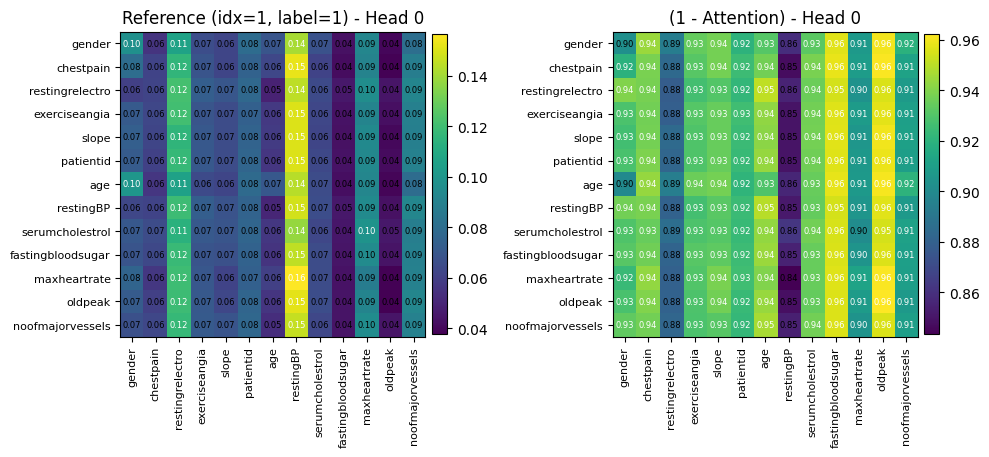


=== Most Similar Sample (SAME Label) Affinity ===
Frobenius distance: 0.0532


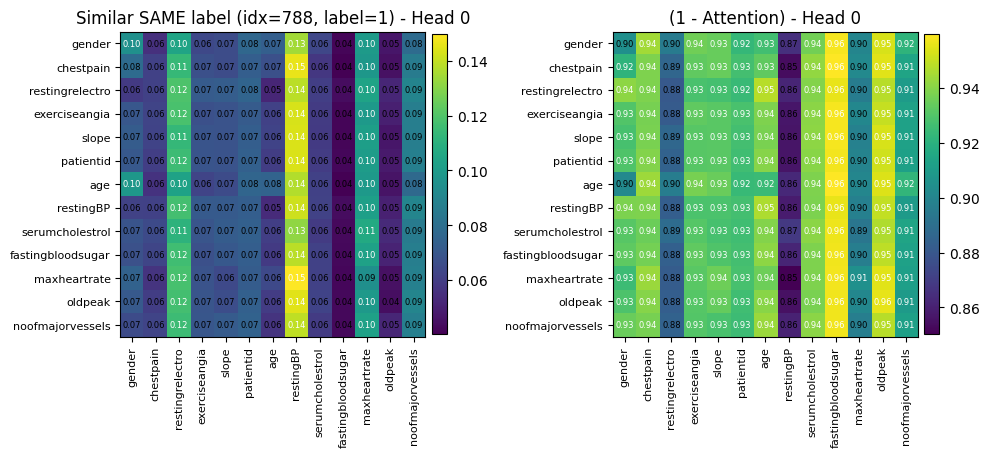


=== Most Different Sample (OTHER Label) Affinity ===
Frobenius distance: 1.2430


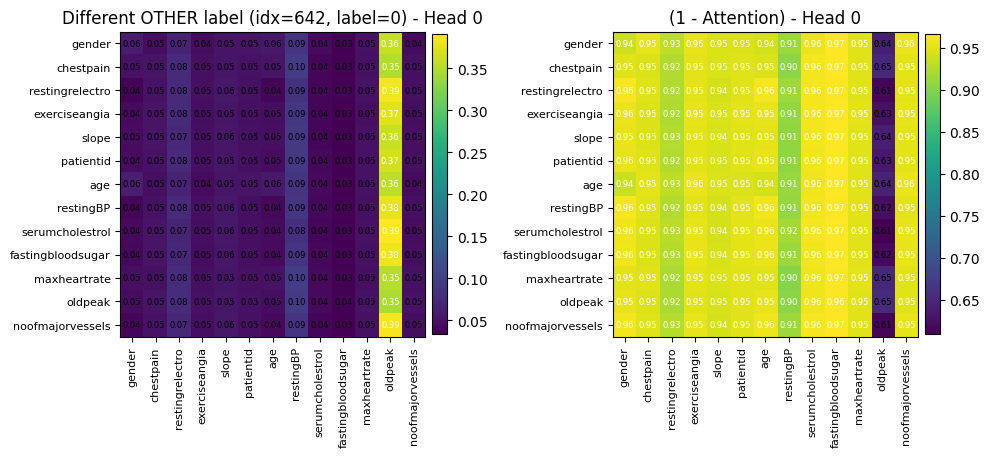

In [7]:
# 4. 시각화
feature_names = ["CLS"] + feature_names_list[0]
var_names = feature_names_list[0]

# Reference 샘플 affinity
ref_aff = affinities[reference_idx]
# Most similar (same label) 샘플 affinity
sim_aff = affinities[similar_idx]
# Most different (other label) 샘플 affinity
diff_aff = affinities[different_idx]

# 3D attention shape로 변환 (plot 함수 호환)
ref_aff_3d = ref_aff[np.newaxis, :, :]  # [1, N, N]
sim_aff_3d = sim_aff[np.newaxis, :, :]
diff_aff_3d = diff_aff[np.newaxis, :, :]

print("\n=== Reference Sample Affinity ===")
plot_attention_with_inverse(
    att=1.0 - ref_aff_3d,  # affinity를 다시 attention으로
    feature_names=var_names,
    title=f"Reference (idx={reference_idx}, label={labels[reference_idx]})",
    value_fontsize=6,
    tick_fontsize=8,
    title_fontsize=12,
    figsize_scale=1.0
)

print("\n=== Most Similar Sample (SAME Label) Affinity ===")
print(f"Frobenius distance: {aff_distances[reference_idx, similar_idx]:.4f}")
plot_attention_with_inverse(
    att=1.0 - sim_aff_3d,
    feature_names=var_names,
    title=f"Similar SAME label (idx={similar_idx}, label={labels[similar_idx]})",
    value_fontsize=6,
    tick_fontsize=8,
    title_fontsize=12,
    figsize_scale=1.0
)

print("\n=== Most Different Sample (OTHER Label) Affinity ===")
print(f"Frobenius distance: {aff_distances[reference_idx, different_idx]:.4f}")
plot_attention_with_inverse(
    att=1.0 - diff_aff_3d,
    feature_names=var_names,
    title=f"Different OTHER label (idx={different_idx}, label={labels[different_idx]})",
    value_fontsize=6,
    tick_fontsize=8,
    title_fontsize=12,
    figsize_scale=1.0
)

## Multi-Source Joint checkpoint

In [8]:
joint_ckpt_pretrain = torch.load(joint_ckpt_pretrain_path, map_location=device)
joint_args = joint_ckpt_pretrain['args']

# Joint 모델 초기화
joint_model_pretrain = Model(
    joint_args,
    joint_args.input_dim,
    joint_args.hidden_dim,
    joint_args.output_dim,
    joint_args.dropout_rate,
    joint_args.llm_model,
    experiment_id="joint_viz",
    mode="Full"
).to(device)

joint_sd = joint_ckpt_pretrain['model_state_dict']
missing, unexpected = joint_model_pretrain.load_state_dict(joint_sd, strict=False)
print("Joint Model Loaded")
print("Missing keys:", missing)
print("Unexpected keys:", unexpected)

joint_model_pretrain.eval()

Joint Model Loaded
Missing keys: []
Unexpected keys: ['latent_graph.init_node_embeddings', 'latent_graph.init_adj_param']


Model(
  (latent_graph): LatentCompositeGraph()
  (graph_quantizer): GraphQuantizer()
  (gnn_experts): LatentCompositeGNN(
    (graph_gnns): ModuleList(
      (0-7): 8 x lightGraphNeuralNet(
        (dropout): Dropout(p=0.1, inplace=False)
        (linear): Linear(in_features=768, out_features=192, bias=True)
        (update): Linear(in_features=192, out_features=768, bias=True)
        (norm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      )
    )
    (readouts): ModuleList(
      (0-7): 8 x GraphReadout(
        (proj): Sequential(
          (0): Linear(in_features=768, out_features=192, bias=True)
          (1): ReLU()
          (2): Dropout(p=0.1, inplace=False)
          (3): Linear(in_features=192, out_features=768, bias=True)
        )
        (norm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      )
    )
  )
  (basis_layers): ModuleList(
    (0-1): 2 x BasisGATLayer_IND(
      (attn_dropout): Dropout(p=0.1, inplace=False)
      (q_proj_list): ModuleLis

## 1. Qualitative Analysis - Label-conditioned Optimal Transport Plan 

In [9]:
@torch.no_grad()
def compute_transport_plans_for_samples(model, sample_indices, embeddings, affinities):
    """
    3개 샘플 (ref, similar, different) x 8개 LCG = 24개 Transport Plan 계산
    
    Args:
        model: Joint trained model
        sample_indices: [ref_idx, similar_idx, different_idx]
        embeddings: list of node embeddings
        affinities: list of affinity matrices
    
    Returns:
        plans: [3, 8, N, K] Transport Plans
        distances: [3, 8] FGW distances
        coordinates: [3, 8] Soft assignments (pi)
    """
    # LCG 가져오기
    lcg_feat, lcg_struct = model.latent_graph()  # [M, K, D], [M, K, K]
    M, K, D = lcg_feat.shape
    
    n_samples = len(sample_indices)
    
    # 결과 저장
    all_plans = []
    all_distances = []
    all_coordinates = []
    
    for idx in sample_indices:
        # Source 준비
        src_feat = torch.from_numpy(embeddings[idx]).float().to(device).unsqueeze(0)  # [1, N, D]
        src_str = torch.from_numpy(affinities[idx]).float().to(device).unsqueeze(0)   # [1, N, N]
        
        N = src_feat.shape[1]
        
        # Expand for M LCGs
        src_feat_exp = src_feat.unsqueeze(1).expand(1, M, N, D).reshape(M, N, D)  # [M, N, D]
        src_str_exp = src_str.unsqueeze(1).expand(1, M, N, N).reshape(M, N, N)    # [M, N, N]
        
        # LCG 준비
        lcg_feat_exp = lcg_feat  # [M, K, D]
        lcg_str_exp = lcg_struct  # [M, K, K]
        
        # FGW 계산 (GraphQuantizer의 compute_fgw 재현)
        dist_sq = torch.cdist(src_feat_exp, lcg_feat_exp, p=2) ** 2
        tau = model.graph_quantizer.tau
        M_cost = 1.0 - torch.exp(-dist_sq / (D * tau))
        
        a = torch.ones(M, N, device=device) / N
        b = torch.ones(M, K, device=device) / K
        
        alpha = model.graph_quantizer.alpha
        reg = model.graph_quantizer.reg
        
        # Solve FGW
        result = solve_gromov_batch(
            src_str_exp, lcg_str_exp, M=M_cost, alpha=alpha, reg=reg,
            a=a, b=b, max_iter=10, tol=1e-3, grad='envelope'
        )
        
        distances = result.value.detach().cpu().numpy()  # [M]
        plans = result.plan.detach().cpu().numpy()       # [M, N, K]
        
        # Soft assignment (pi)
        soft_tau = model.graph_quantizer.soft_tau
        pi = torch.softmax(-result.value / soft_tau, dim=0).detach().cpu().numpy()  # [M]
        
        all_plans.append(plans)
        all_distances.append(distances)
        all_coordinates.append(pi)
    
    all_plans = np.array(all_plans)           # [3, M, N, K]
    all_distances = np.array(all_distances)   # [3, M]
    all_coordinates = np.array(all_coordinates)  # [3, M]
    
    return all_plans, all_distances, all_coordinates

def plot_transport_plans_grid(plans, coordinates, distances, sample_indices, labels, var_names):
    """
    3 x 8 Grid로 Transport Plan 시각화
    + 각 LCG별로 Reference vs Similar, Reference vs Different의 Frobenius norm 표시
    
    Args:
        plans: [3, 8, N, K]
        coordinates: [3, 8] (pi values)
        distances: [3, 8] (FGW distances)
        sample_indices: [ref_idx, similar_idx, different_idx]
        labels: list of all labels
        var_names: list of variable names
    """
    n_samples = 3
    n_lcgs = 8
    
    fig, axes = plt.subplots(n_samples, n_lcgs, figsize=(24, 9))
    
    sample_names = ['Reference', 'Similar (Same Label)', 'Different (Other Label)']
    
    # 각 LCG별 Frobenius norm 계산
    frob_norms_similar = []  # Reference vs Similar
    frob_norms_different = []  # Reference vs Different
    
    for j in range(n_lcgs):
        plan_ref = plans[0, j]      # Reference
        plan_sim = plans[1, j]      # Similar
        plan_diff = plans[2, j]     # Different
        
        frob_ref_sim = np.linalg.norm(plan_ref - plan_sim, ord='fro')
        frob_ref_diff = np.linalg.norm(plan_ref - plan_diff, ord='fro')
        
        frob_norms_similar.append(frob_ref_sim)
        frob_norms_different.append(frob_ref_diff)
    
    for i in range(n_samples):
        for j in range(n_lcgs):
            ax = axes[i, j]
            
            plan = plans[i, j]  # [N, K]
            pi = coordinates[i, j]
            dist = distances[i, j]
            
            # Heatmap
            im = ax.imshow(plan, cmap='viridis', aspect='auto')
            
            # Title
            if i == 0:
                ax.set_title(f'LCG {j}\nπ={pi:.3f}\nD={dist:.3f}', fontsize=10)
            else:
                ax.set_title(f'π={pi:.3f}\nD={dist:.3f}', fontsize=9)
            
            # Y-axis (Source variables)
            if j == 0:
                ax.set_ylabel(f'{sample_names[i]}\n(idx={sample_indices[i]}, label={labels[sample_indices[i]]})', 
                             fontsize=9)
                ax.set_yticks(range(len(var_names)))
                ax.set_yticklabels(var_names, fontsize=7)
            else:
                ax.set_yticks([])
            
            # X-axis (LCG nodes)
            if i == n_samples - 1:
                ax.set_xlabel(f'LCG Nodes (K={plan.shape[1]})', fontsize=8)
                ax.set_xticks(range(plan.shape[1]))
                ax.set_xticklabels(range(plan.shape[1]), fontsize=7)
            else:
                ax.set_xticks([])
            
            # Frobenius norm 표시 (Different row의 맨 아래)
            if i == n_samples - 1:
                frob_sim = frob_norms_similar[j]
                frob_diff = frob_norms_different[j]
                
                # X-axis label 아래에 Frobenius norm 추가
                ax.text(0.5, -0.5, f'Frob: Sim={frob_sim:.3f} vs Diff={frob_diff:.3f}',
                       transform=ax.transAxes,
                       ha='center', va='top',
                       fontsize=10, color='red',
                       bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.3))
            
            # Colorbar
            plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.08)  # Frobenius norm 텍스트 공간 확보
    plt.suptitle('Transport Plans: Reference vs Similar vs Different (across 8 LCGs)', 
                 fontsize=14, y=0.99)
    plt.show()

In [10]:
# 실행
print("Computing Transport Plans for 3 samples x 8 LCGs...")
sample_indices = [reference_idx, similar_idx, different_idx]

plans, distances, coordinates = compute_transport_plans_for_samples(
    joint_model_pretrain, sample_indices, embeddings, affinities
)

print(f"Plans shape: {plans.shape}")  # [3, 8, N, K]
print(f"Distances shape: {distances.shape}")  # [3, 8]
print(f"Coordinates shape: {coordinates.shape}")  # [3, 8]

print("\n=== Coordinates (pi) ===")
print("Reference:", coordinates[0])
print("Similar:", coordinates[1])
print("Different:", coordinates[2])

print("\n=== FGW Distances ===")
print("Reference:", distances[0])
print("Similar:", distances[1])
print("Different:", distances[2])

Computing Transport Plans for 3 samples x 8 LCGs...
Plans shape: (3, 8, 13, 8)
Distances shape: (3, 8)
Coordinates shape: (3, 8)

=== Coordinates (pi) ===
Reference: [1.1557545e-05 2.3760194e-04 1.6413204e-02 2.2224141e-02 4.3267268e-03
 2.3031665e-01 1.5762086e-04 7.2631246e-01]
Similar: [1.1453133e-05 2.3770888e-04 1.6272062e-02 2.1669108e-02 4.3271887e-03
 2.2812189e-01 1.5824380e-04 7.2920239e-01]
Different: [1.0911641e-05 2.3949704e-04 1.4786890e-02 2.5924396e-02 4.9926345e-03
 2.3364352e-01 1.5539074e-04 7.2024673e-01]

=== FGW Distances ===
Reference: [0.4779051  0.4476725  0.40532005 0.40228912 0.4186528  0.37890637
 0.45177653 0.36742112]
Similar: [0.47592705 0.4455992  0.40333763 0.40047327 0.41658294 0.37693334
 0.44966832 0.3653126 ]
Different: [0.47736445 0.44647735 0.4052478  0.39963338 0.41610557 0.37764725
 0.45080334 0.36638927]


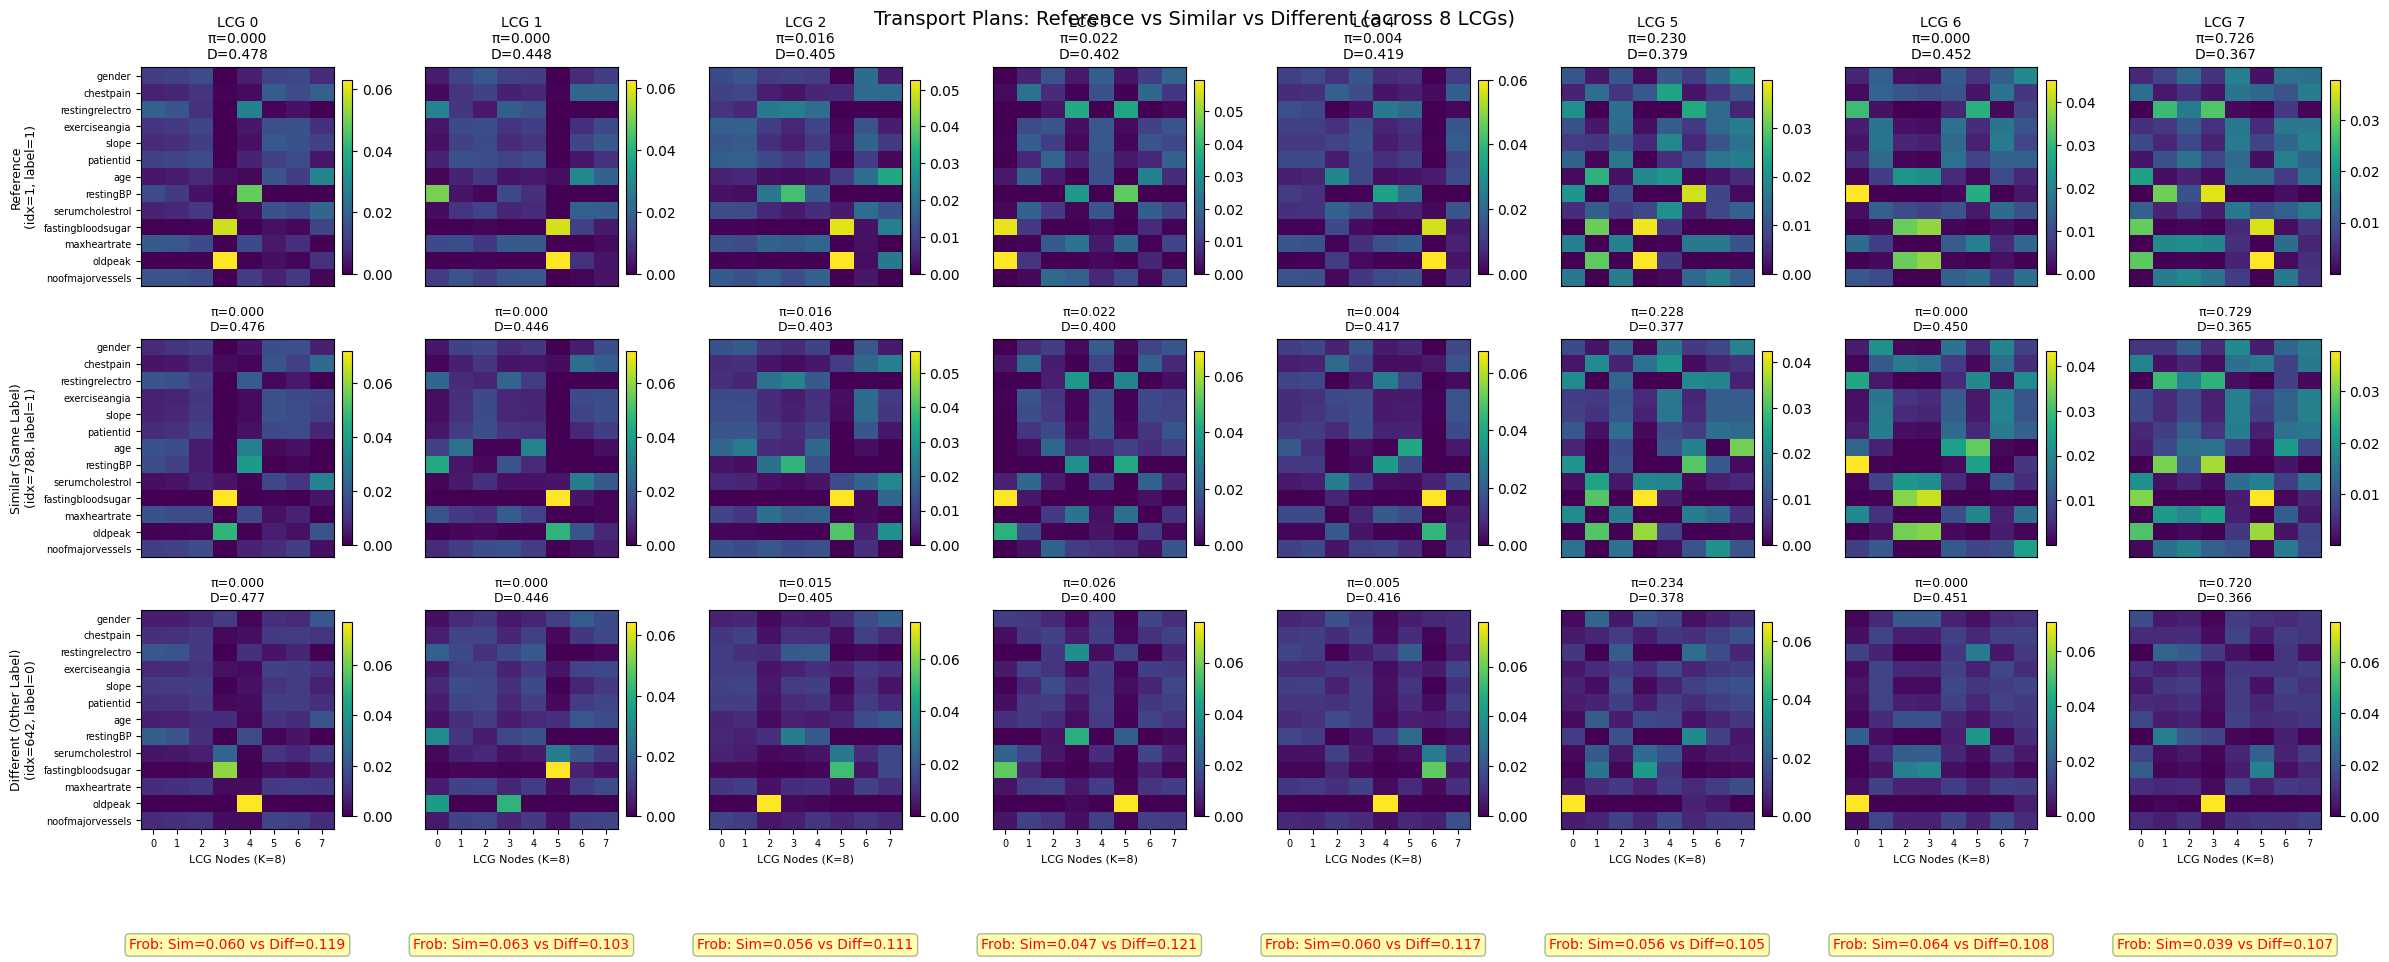

In [11]:
# 시각화
plot_transport_plans_grid(
    plans, coordinates, distances, 
    sample_indices, labels, var_names
)

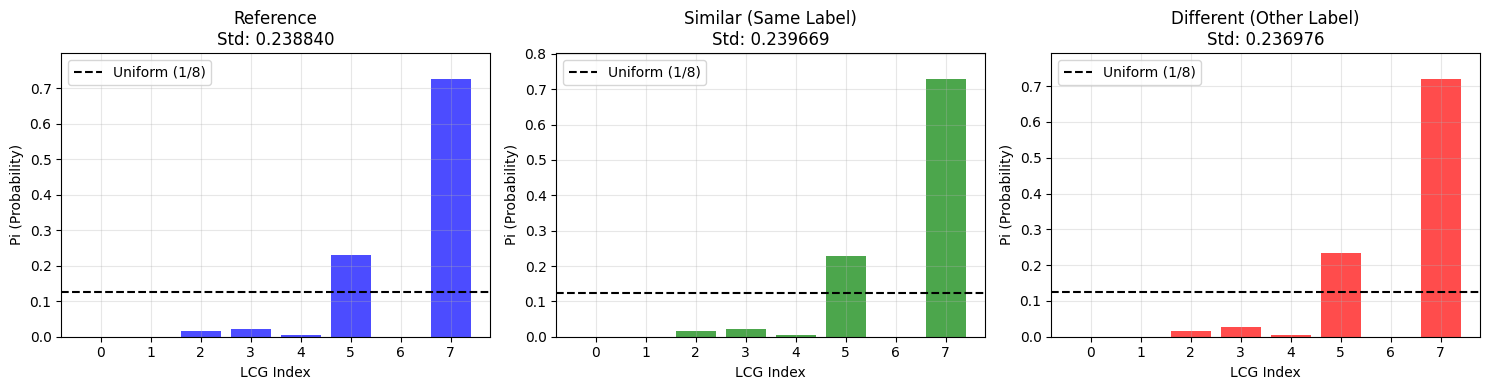

In [12]:
# 시각화: Pi 비교
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sample_names = ['Reference', 'Similar (Same Label)', 'Different (Other Label)']
colors = ['blue', 'green', 'red']

for i, (coord, name, color) in enumerate(zip(coordinates, sample_names, colors)):
    ax = axes[i]
    ax.bar(range(8), coord, color=color, alpha=0.7)
    ax.set_xlabel('LCG Index')
    ax.set_ylabel('Pi (Probability)')
    ax.set_title(f'{name}\nStd: {coord.std():.6f}')
    ax.set_ylim([0, max(0.2, coord.max() * 1.1)])
    ax.axhline(y=1/8, color='black', linestyle='--', label='Uniform (1/8)')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Qualitative Analysis - Optimal Transport Plan + Coordinate (1)

- Source 별 결과

Total samples collected: 1000
Node embedding shape: (13, 768)
Affinity shape: (13, 13)
Computing Frobenius distances...
Embedding distance matrix shape: (1000, 1000)
Affinity distance matrix shape: (1000, 1000)

=== Analysis based on affinity Frobenius Distance (Label-aware) ===
Reference sample: 0 (label: 1)

Most similar (SAME label): 710 (label: 1)
  → distance: 0.0783

Most different (OTHER label): 642 (label: 0)
  → distance: 1.1945

Computing Transport Plans for 3 samples x 8 LCGs...


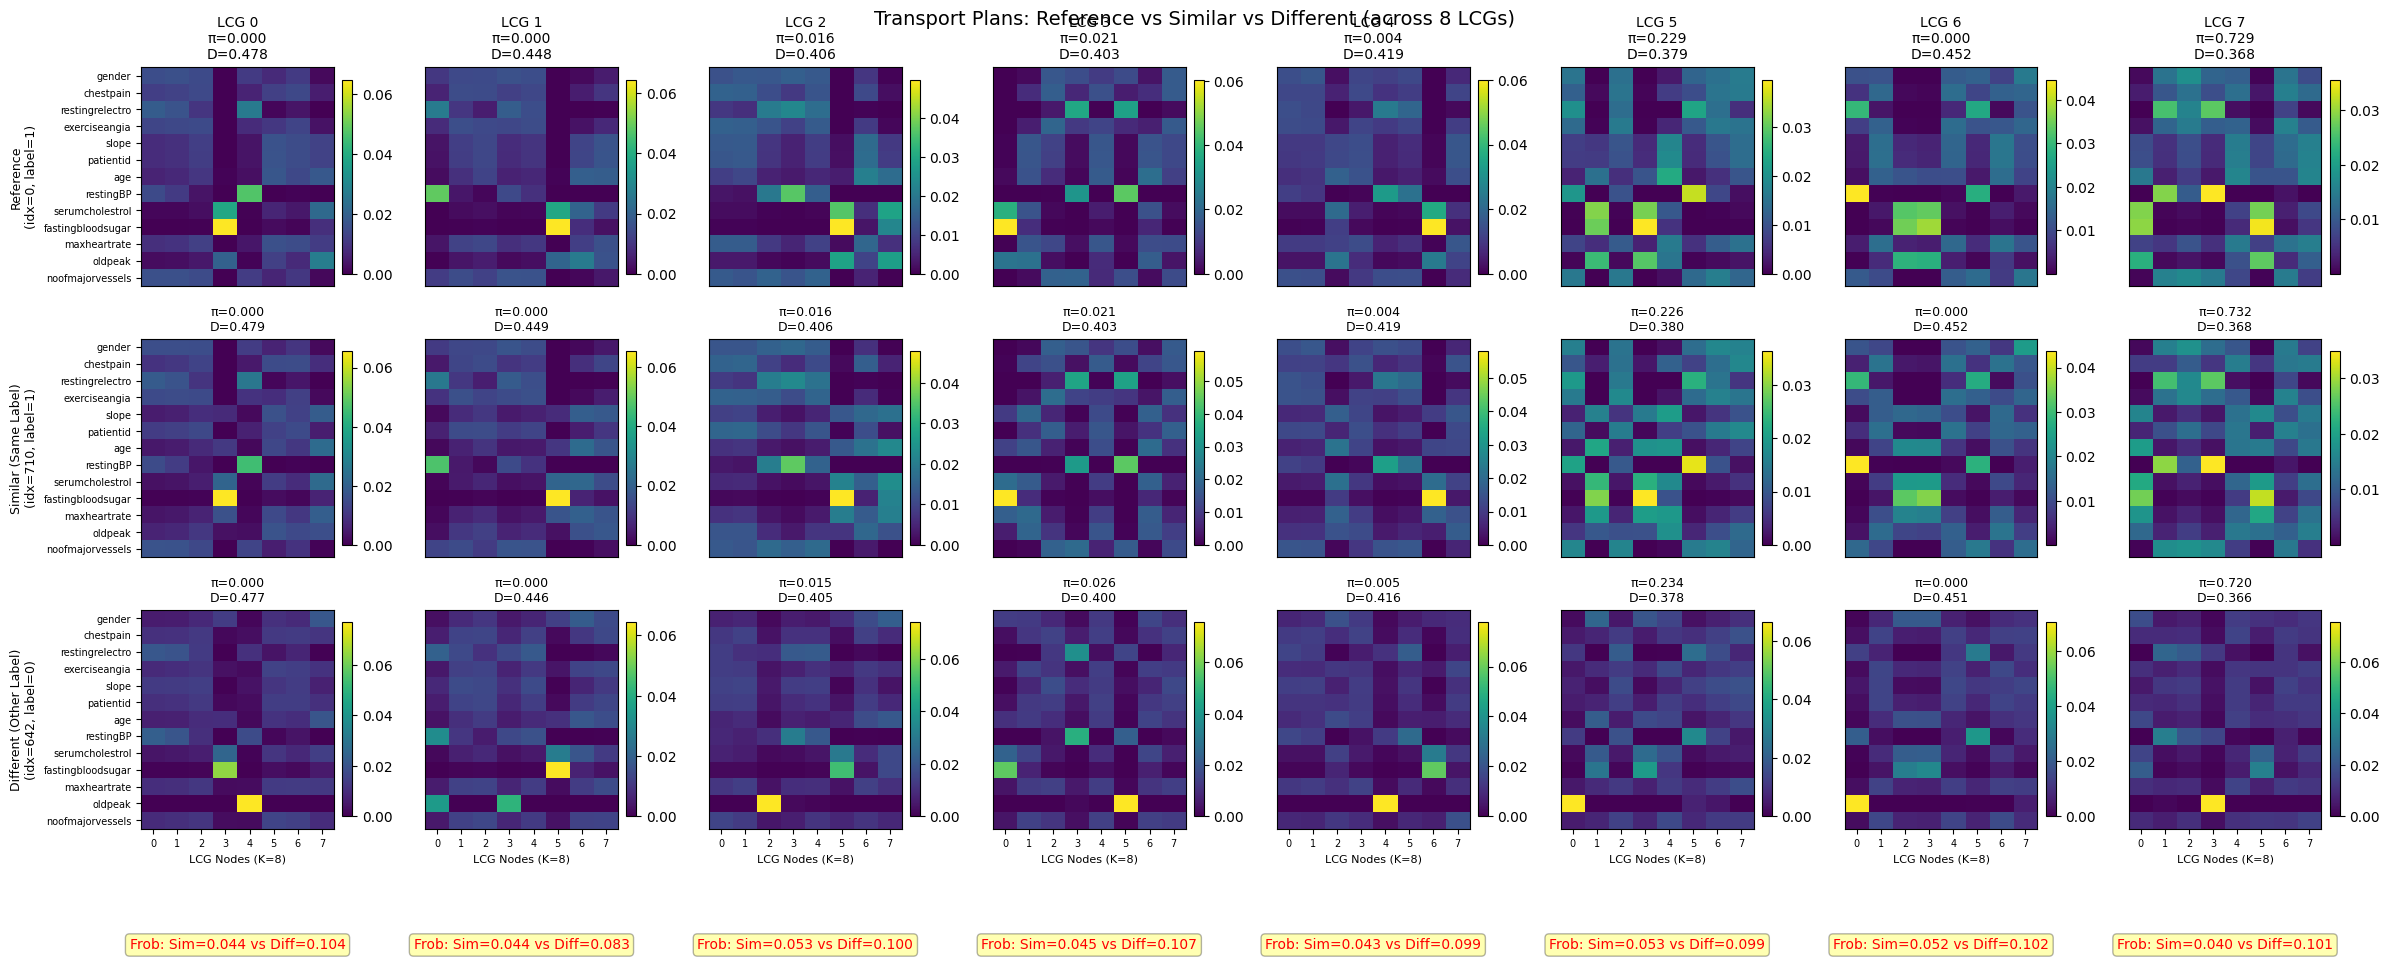

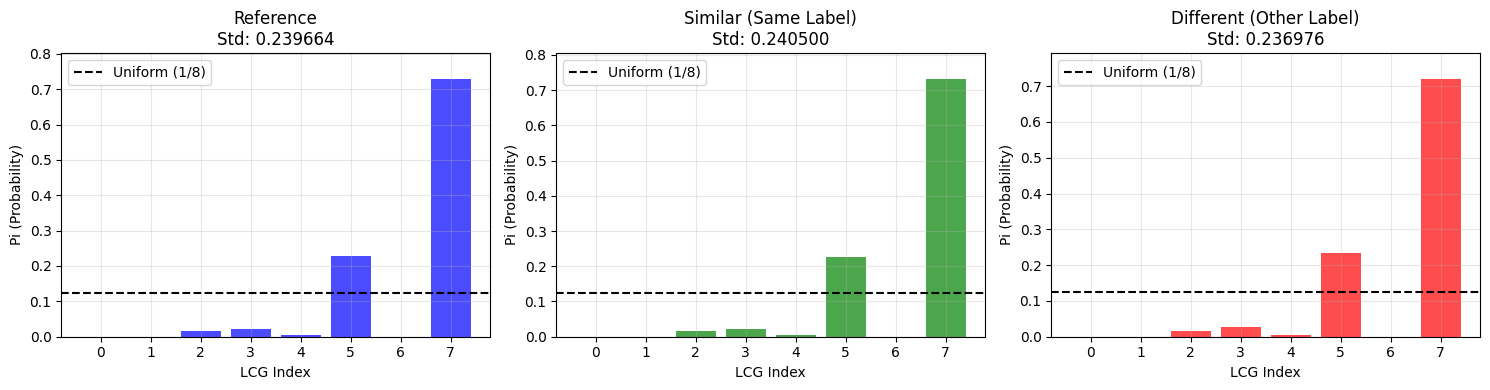

In [13]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from collections import defaultdict

# =========================================================
# 0) (helper) label-aware ref/sim/diff pick
# =========================================================
def find_most_similar_and_different_by_label(reference_idx, distances, labels):
    n = len(distances)
    ref_label = labels[reference_idx]

    same_label_mask = np.array([labels[i] == ref_label for i in range(n)], dtype=bool)
    same_label_mask[reference_idx] = False

    other_label_mask = np.array([labels[i] != ref_label for i in range(n)], dtype=bool)

    dist_same = distances[reference_idx].copy()
    dist_same[~same_label_mask] = np.inf
    most_similar_same_label_idx = int(np.argmin(dist_same))

    dist_other = distances[reference_idx].copy()
    dist_other[~other_label_mask] = -np.inf
    most_different_other_label_idx = int(np.argmax(dist_other))

    return most_similar_same_label_idx, most_different_other_label_idx


# =========================================================
# 1) collect all samples (embeddings + affinity) from ONE source loader
#    - 너가 준 로직 그대로: last_att(head0) -> var-var -> affinity = 1-att
# =========================================================
@torch.no_grad()
def collect_all_samples_from_source(model, loader, device, extract_feature_names_fn=None):
    """
    Returns:
        all_embeddings: list of [N,D] (CLS 제외 var nodes)
        all_affinities: list of [N,N] (1-attention, Var-Var)
        all_labels: list[int]
        all_feature_names: list[var_names]  (extract_feature_names_fn 제공 시)
    """
    all_embeddings = []
    all_affinities = []
    all_labels = []
    all_feature_names = []

    for batch in loader:
        batch = {k: (v.to(device) if isinstance(v, torch.Tensor) else v) for k, v in batch.items()}

        # desc/name/value gather (너 코드 그대로)
        desc_embeddings, name_embeddings, value_embeddings = [], [], []
        if all(k in batch for k in ['cat_name_embeddings', 'cat_value_embeddings', 'cat_desc_embeddings']):
            desc_embeddings.append(batch['cat_desc_embeddings'])
            name_embeddings.append(batch['cat_name_embeddings'])
            value_embeddings.append(batch['cat_value_embeddings'])

        if all(k in batch for k in ['num_prompt_embeddings', 'num_desc_embeddings']):
            desc_embeddings.append(batch['num_desc_embeddings'])
            name_embeddings.append(batch['num_name_embeddings'])
            value_embeddings.append(batch['num_prompt_embeddings'])

        name  = torch.cat(name_embeddings, dim=1)
        value = torch.cat(value_embeddings, dim=1)

        B = value.size(0)

        # CLS + value token concat
        x_basis = torch.cat([model.basis_cls.expand(B, 1, model.input_dim), value], dim=1)

        last_att = None

        for l in range(model.num_basis_layers):
            norm_x = model.basis_layer_norms[l](x_basis)
            basis_outputs, att = model.basis_layers[l](name, norm_x)  # att: [B,H,T,T]
            last_att = att
            x_basis = x_basis + basis_outputs.reshape(x_basis.size(0), x_basis.size(1), model.input_dim)

        # last_att: [B,H,T,T] -> head0 -> [B,T,T]
        last_att = last_att[:, 0, :, :]

        # var names
        if extract_feature_names_fn is not None:
            var_names = extract_feature_names_fn(batch)
        else:
            var_names = None

        for b in range(B):
            node_emb = x_basis[b, 1:, :].detach().cpu().numpy()          # [N,D]
            var_att  = last_att[b, 1:, 1:].detach().cpu().numpy()        # [N,N]
            affinity = 1.0 - var_att                                    # [N,N]

            all_embeddings.append(node_emb)
            all_affinities.append(affinity)
            all_labels.append(int(batch['y'][b].item()))
            all_feature_names.append(var_names)

    return all_embeddings, all_affinities, all_labels, all_feature_names


# =========================================================
# 2) Frobenius distance matrix (O(n^2))
# =========================================================
def compute_frobenius_distances(embeddings, affinities):
    n = len(embeddings)
    emb_distances = np.zeros((n, n), dtype=np.float32)
    aff_distances = np.zeros((n, n), dtype=np.float32)

    for i in range(n):
        for j in range(i + 1, n):
            emb_diff = np.linalg.norm(embeddings[i] - embeddings[j], ord='fro')
            emb_distances[i, j] = emb_diff
            emb_distances[j, i] = emb_diff

            aff_diff = np.linalg.norm(affinities[i] - affinities[j], ord='fro')
            aff_distances[i, j] = aff_diff
            aff_distances[j, i] = aff_diff

    return emb_distances, aff_distances


# =========================================================
# 3) FGW plans + pi (너 코드 그대로)
#    NOTE: solve_gromov_batch는 네 세션에 이미 import 되어 있어야 함
# =========================================================
@torch.no_grad()
def compute_transport_plans_for_samples(model, sample_indices, embeddings, affinities, device):
    lcg_feat, lcg_struct = model.latent_graph()  # [M,K,D], [M,K,K]
    M, K, D = lcg_feat.shape

    all_plans = []
    all_distances = []
    all_coordinates = []

    for idx in sample_indices:
        src_feat = torch.from_numpy(embeddings[idx]).float().to(device).unsqueeze(0)   # [1,N,D]
        src_str  = torch.from_numpy(affinities[idx]).float().to(device).unsqueeze(0)  # [1,N,N]
        N = src_feat.shape[1]

        src_feat_exp = src_feat.unsqueeze(1).expand(1, M, N, D).reshape(M, N, D)
        src_str_exp  = src_str.unsqueeze(1).expand(1, M, N, N).reshape(M, N, N)

        dist_sq = torch.cdist(src_feat_exp, lcg_feat, p=2) ** 2
        tau = model.graph_quantizer.tau
        M_cost = 1.0 - torch.exp(-dist_sq / (D * tau))

        a = torch.ones(M, N, device=device) / N
        b = torch.ones(M, K, device=device) / K

        alpha = model.graph_quantizer.alpha
        reg   = model.graph_quantizer.reg

        result = solve_gromov_batch(
            src_str_exp, lcg_struct, M=M_cost, alpha=alpha, reg=reg,
            a=a, b=b, max_iter=10, tol=1e-3, grad='envelope'
        )

        distances = result.value.detach().cpu().numpy()  # [M]
        plans     = result.plan.detach().cpu().numpy()   # [M,N,K]

        soft_tau = model.graph_quantizer.soft_tau
        pi = torch.softmax(-result.value / soft_tau, dim=0).detach().cpu().numpy()  # [M]

        all_plans.append(plans)
        all_distances.append(distances)
        all_coordinates.append(pi)

    return np.array(all_plans), np.array(all_distances), np.array(all_coordinates)


# =========================================================
# 4) plot grid (너 코드 그대로)
# =========================================================
def plot_transport_plans_grid(plans, coordinates, distances, sample_indices, labels, var_names):
    n_samples = 3
    n_lcgs = 8

    fig, axes = plt.subplots(n_samples, n_lcgs, figsize=(24, 9))
    sample_names = ['Reference', 'Similar (Same Label)', 'Different (Other Label)']

    frob_norms_similar = []
    frob_norms_different = []
    for j in range(n_lcgs):
        plan_ref  = plans[0, j]
        plan_sim  = plans[1, j]
        plan_diff = plans[2, j]
        frob_norms_similar.append(np.linalg.norm(plan_ref - plan_sim, ord='fro'))
        frob_norms_different.append(np.linalg.norm(plan_ref - plan_diff, ord='fro'))

    for i in range(n_samples):
        for j in range(n_lcgs):
            ax = axes[i, j]
            plan = plans[i, j]
            pi   = coordinates[i, j]
            dist = distances[i, j]

            im = ax.imshow(plan, cmap='viridis', aspect='auto')

            if i == 0:
                ax.set_title(f'LCG {j}\nπ={pi:.3f}\nD={dist:.3f}', fontsize=10)
            else:
                ax.set_title(f'π={pi:.3f}\nD={dist:.3f}', fontsize=9)

            if j == 0:
                ax.set_ylabel(
                    f'{sample_names[i]}\n(idx={sample_indices[i]}, label={labels[sample_indices[i]]})',
                    fontsize=9
                )
                ax.set_yticks(range(len(var_names)))
                ax.set_yticklabels(var_names, fontsize=7)
            else:
                ax.set_yticks([])

            if i == n_samples - 1:
                ax.set_xlabel(f'LCG Nodes (K={plan.shape[1]})', fontsize=8)
                ax.set_xticks(range(plan.shape[1]))
                ax.set_xticklabels(range(plan.shape[1]), fontsize=7)
            else:
                ax.set_xticks([])

            if i == n_samples - 1:
                ax.text(
                    0.5, -0.5, f'Frob: Sim={frob_norms_similar[j]:.3f} vs Diff={frob_norms_different[j]:.3f}',
                    transform=ax.transAxes,
                    ha='center', va='top',
                    fontsize=10, color='red',
                    bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.3)
                )

            plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.subplots_adjust(bottom=0.08)
    plt.suptitle('Transport Plans: Reference vs Similar vs Different (across 8 LCGs)',
                 fontsize=14, y=0.99)
    plt.show()


# =========================================================
# 5) plot pi 비교 (너 코드 그대로)
# =========================================================
def plot_pi_bars(coordinates):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    sample_names = ['Reference', 'Similar (Same Label)', 'Different (Other Label)']
    colors = ['blue', 'green', 'red']

    for i, (coord, name, color) in enumerate(zip(coordinates, sample_names, colors)):
        ax = axes[i]
        ax.bar(range(8), coord, color=color, alpha=0.7)
        ax.set_xlabel('LCG Index')
        ax.set_ylabel('Pi (Probability)')
        ax.set_title(f'{name}\nStd: {coord.std():.6f}')
        ax.set_ylim([0, max(0.2, coord.max() * 1.1)])
        ax.axhline(y=1/8, color='black', linestyle='--', label='Uniform (1/8)')
        ax.legend()
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


# =========================================================
# 6) WRAP-UP (한 방에)
#    - model, loader만 넣으면: 수집 -> 거리 -> ref/sim/diff -> FGW -> 두 plot
#    - var_names는 extract_feature_names로 뽑거나, 없으면 feature_names_list[0]에서 가져옴
# =========================================================
def run_transport_plan_wrapup(
    model,
    loader,
    device,
    source_name="",
    reference_idx=0,
    distance_mode="affinity",   # "affinity" or "embedding"
    extract_feature_names_fn=None,
):
    print(f"Collecting samples from source: {source_name}")
    embeddings, affinities, labels, feature_names_list = collect_all_samples_from_source(
        model=model,
        loader=loader,
        device=device,
        extract_feature_names_fn=extract_feature_names_fn
    )

    print(f"Total samples collected: {len(embeddings)}")
    print(f"Node embedding shape: {embeddings[0].shape}")
    print(f"Affinity shape: {affinities[0].shape}")

    print("Computing Frobenius distances...")
    emb_distances, aff_distances = compute_frobenius_distances(embeddings, affinities)

    print(f"Embedding distance matrix shape: {emb_distances.shape}")
    print(f"Affinity distance matrix shape: {aff_distances.shape}")

    if reference_idx < 0 or reference_idx >= len(labels):
        raise IndexError(f"reference_idx out of range: {reference_idx} (n={len(labels)})")

    dist_mat = aff_distances if distance_mode == "affinity" else emb_distances
    similar_idx, different_idx = find_most_similar_and_different_by_label(reference_idx, dist_mat, labels)

    print(f"\n=== Analysis based on {distance_mode} Frobenius Distance (Label-aware) ===")
    print(f"Reference sample: {reference_idx} (label: {labels[reference_idx]})")
    print(f"\nMost similar (SAME label): {similar_idx} (label: {labels[similar_idx]})")
    print(f"  → distance: {dist_mat[reference_idx, similar_idx]:.4f}")
    print(f"\nMost different (OTHER label): {different_idx} (label: {labels[different_idx]})")
    print(f"  → distance: {dist_mat[reference_idx, different_idx]:.4f}")

    sample_indices = [reference_idx, similar_idx, different_idx]

    print("\nComputing Transport Plans for 3 samples x 8 LCGs...")
    plans, distances, coordinates = compute_transport_plans_for_samples(
        model=model,
        sample_indices=sample_indices,
        embeddings=embeddings,
        affinities=affinities,
        device=device
    )

    # var_names: 우선 feature_names_list[0] (너 코드처럼)
    # extract_feature_names_fn이 batch->list를 리턴하면 이미 list로 들어있음
    var_names = feature_names_list[0]
    if var_names is None:
        # fallback: generic names
        N = embeddings[0].shape[0]
        var_names = [f"v{i}" for i in range(N)]

    # ---- plots (너 방식 그대로) ----
    plot_transport_plans_grid(
        plans, coordinates, distances,
        sample_indices=sample_indices,
        labels=labels,
        var_names=var_names
    )
    plot_pi_bars(coordinates)

    return {
        "embeddings": embeddings,
        "affinities": affinities,
        "labels": labels,
        "feature_names_list": feature_names_list,
        "emb_distances": emb_distances,
        "aff_distances": aff_distances,
        "sample_indices": sample_indices,
        "plans": plans,
        "distances": distances,
        "coordinates": coordinates,
        "var_names": var_names
    }


# =========================================================
# 실행 예시
# =========================================================
src = sources[1]
loader = loaders[src]
out = run_transport_plan_wrapup(
    model=model,
    loader=loader,
    device=device,
    source_name=src,
    reference_idx=0,
    distance_mode="affinity",
    extract_feature_names_fn=extract_feature_names  # 네가 이미 갖고 있으면
)


Total samples collected: 270
Node embedding shape: (13, 768)
Affinity shape: (13, 13)
Computing Frobenius distances...
Embedding distance matrix shape: (270, 270)
Affinity distance matrix shape: (270, 270)

=== Analysis based on affinity Frobenius Distance (Label-aware) ===
Reference sample: 5 (label: 1)

Most similar (SAME label): 136 (label: 1)
  → distance: 0.5850

Most different (OTHER label): 111 (label: 0)
  → distance: 1.8927

Computing Transport Plans for 3 samples x 8 LCGs...


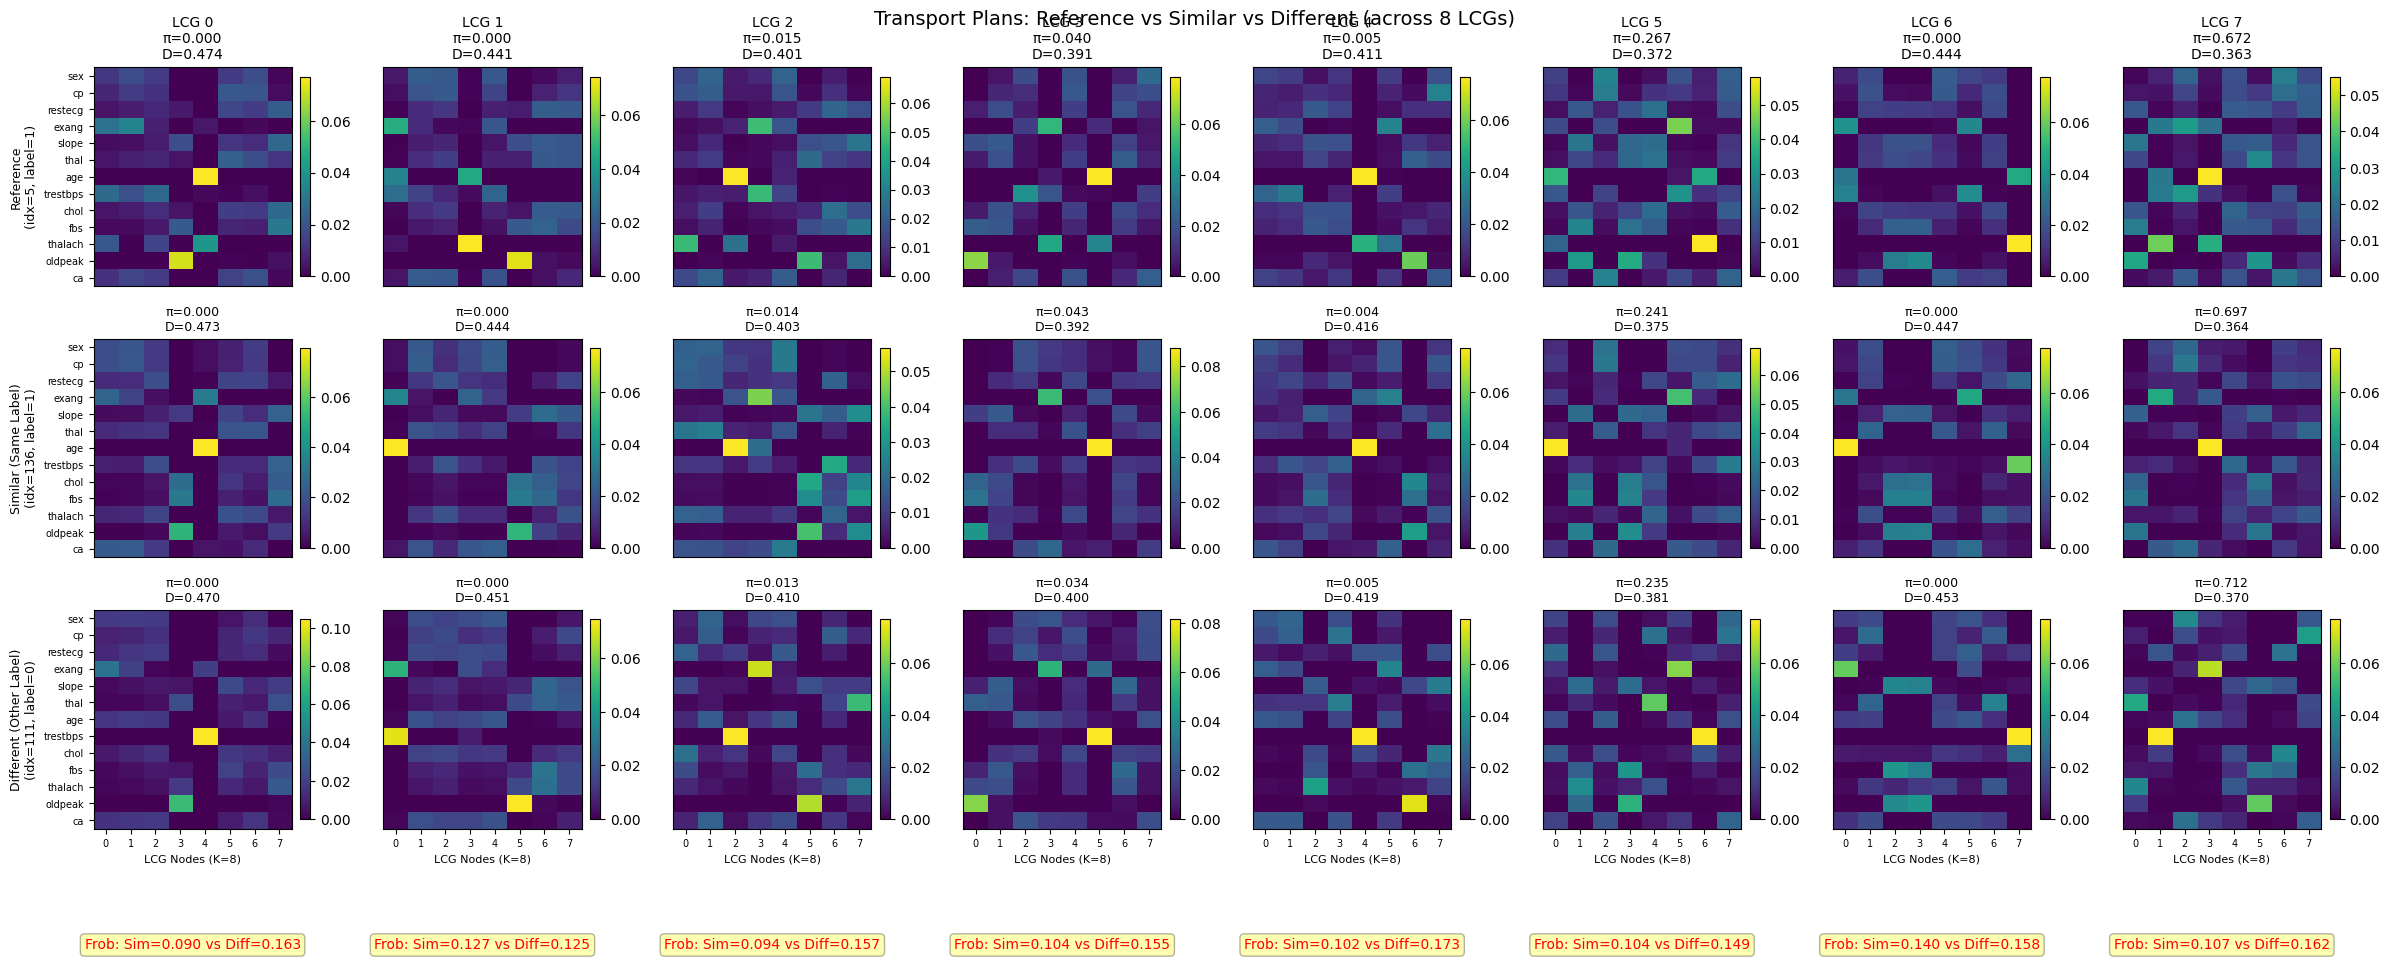

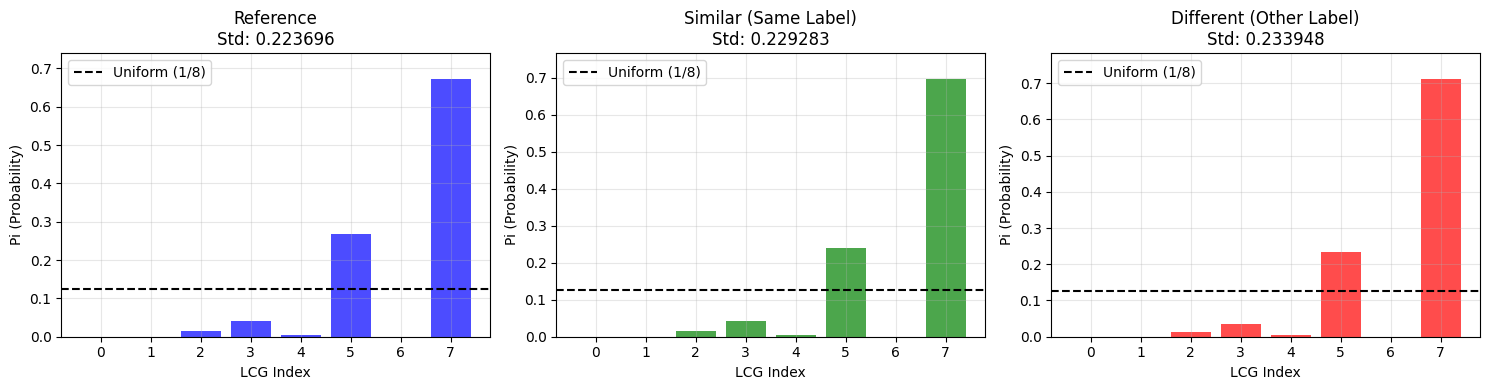

In [14]:
src = sources[2]
loader = loaders[src]
out = run_transport_plan_wrapup(
    model=model,
    loader=loader,
    device=device,
    source_name=src,
    reference_idx=5,
    distance_mode="affinity",
    extract_feature_names_fn=extract_feature_names  # 네가 이미 갖고 있으면
)

In [15]:
sources[3]

'Erbil_Cardiovascular_Health_Dataset'

Total samples collected: 287
Node embedding shape: (20, 768)
Affinity shape: (20, 20)
Computing Frobenius distances...
Embedding distance matrix shape: (287, 287)
Affinity distance matrix shape: (287, 287)

=== Analysis based on affinity Frobenius Distance (Label-aware) ===
Reference sample: 5 (label: 1)

Most similar (SAME label): 195 (label: 1)
  → distance: 0.1409

Most different (OTHER label): 213 (label: 0)
  → distance: 0.7604

Computing Transport Plans for 3 samples x 8 LCGs...


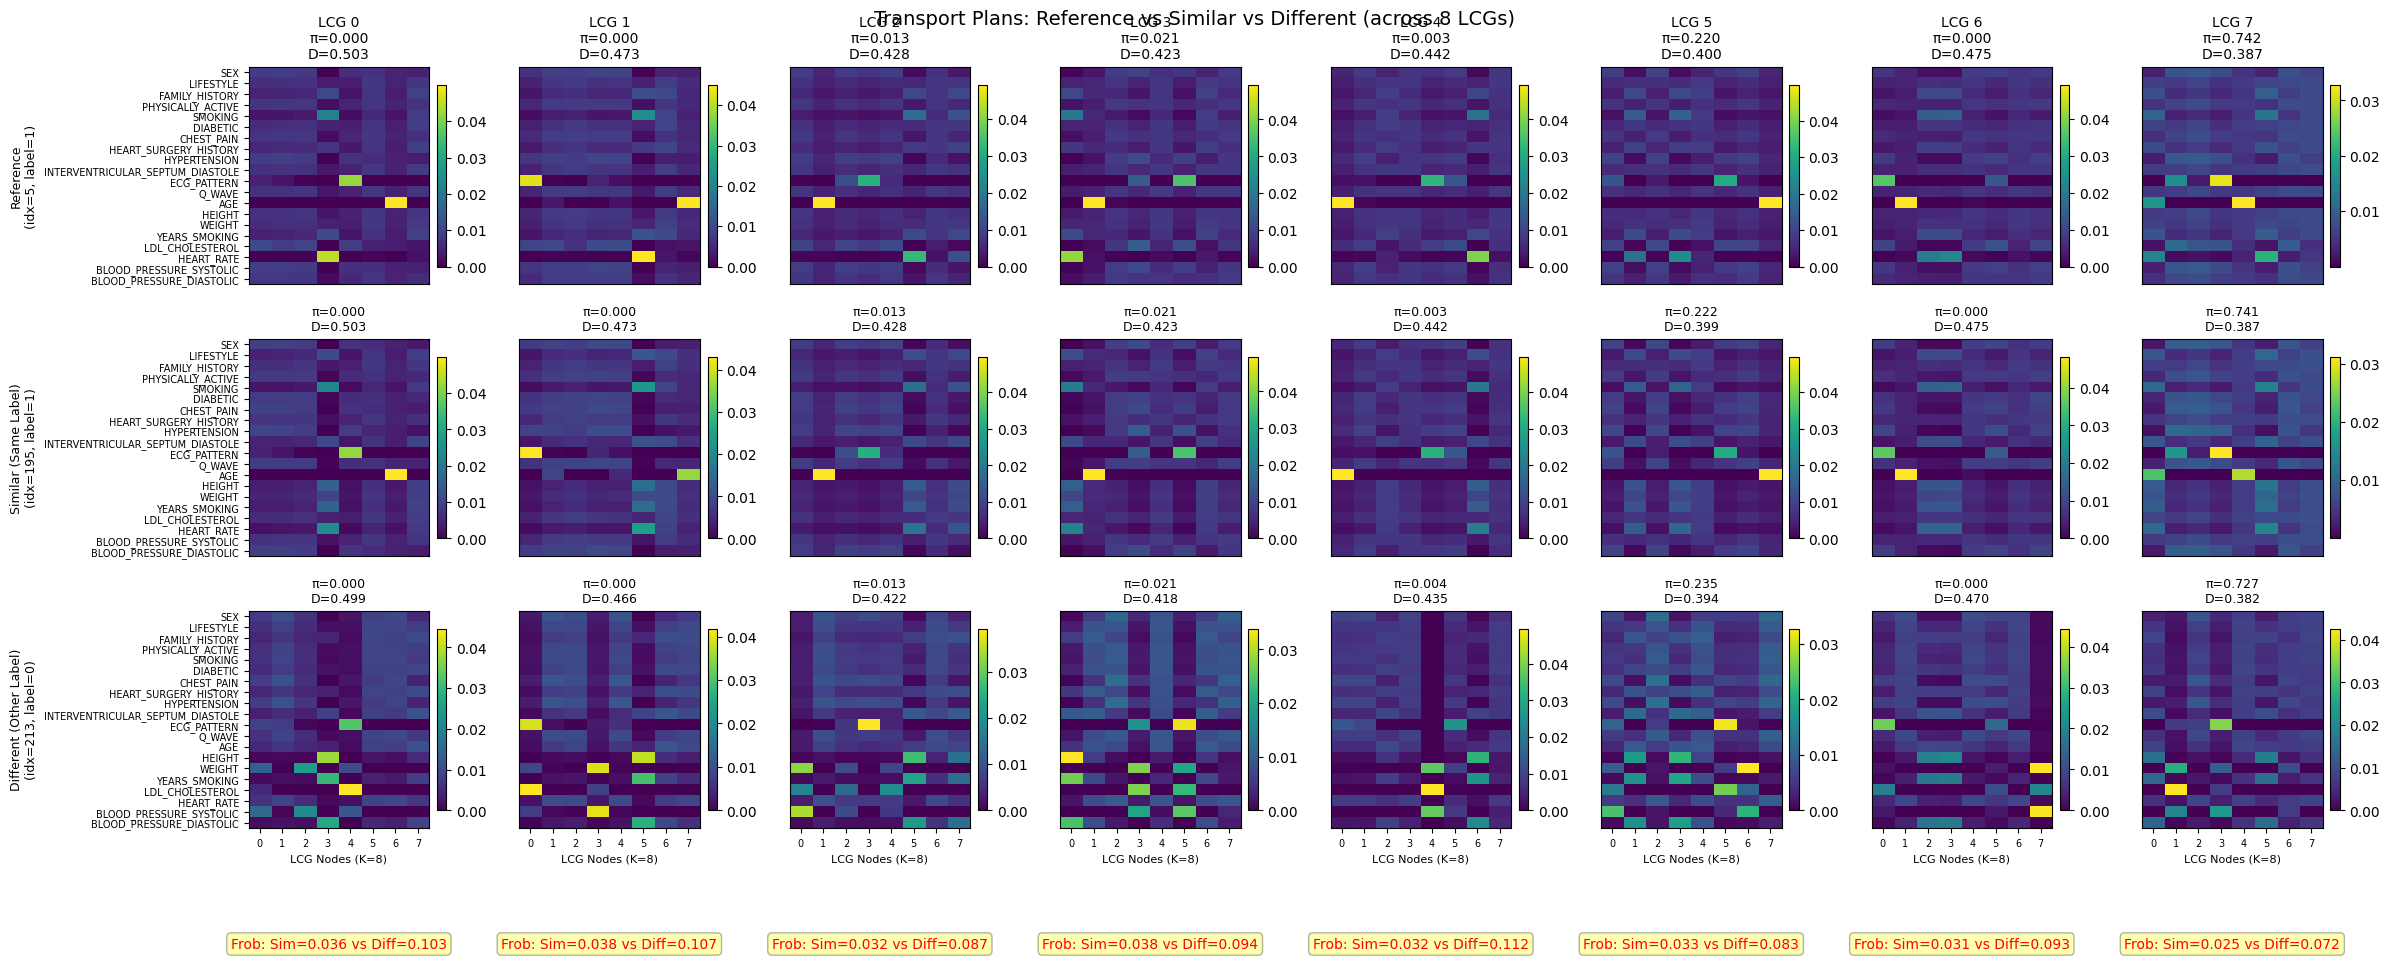

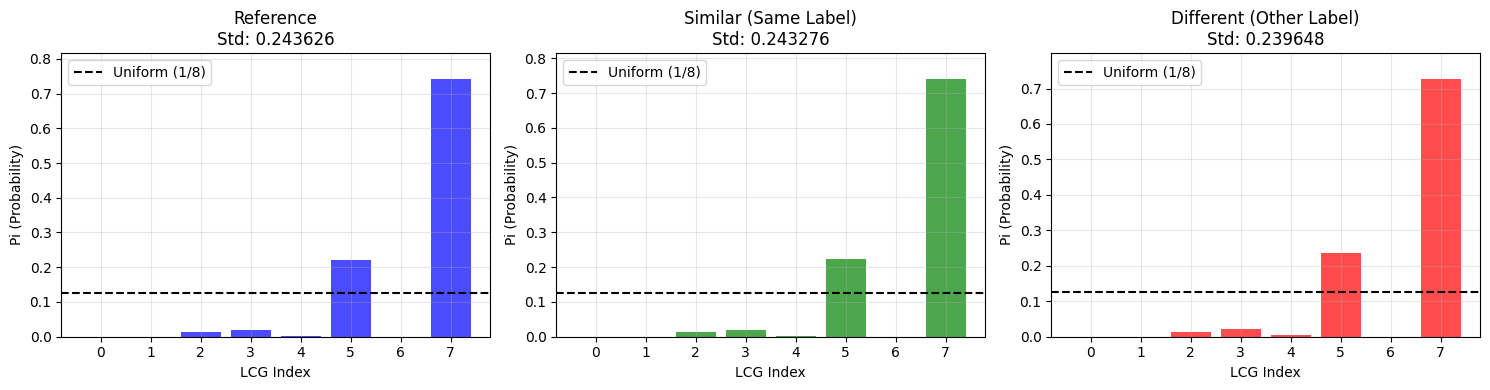

In [16]:
src = sources[3]
loader = loaders[src]
out = run_transport_plan_wrapup(
    model=model,
    loader=loader,
    device=device,
    source_name=src,
    reference_idx=5,
    distance_mode="affinity",
    extract_feature_names_fn=extract_feature_names  # 네가 이미 갖고 있으면
)

Total samples collected: 1319
Node embedding shape: (8, 768)
Affinity shape: (8, 8)
Computing Frobenius distances...
Embedding distance matrix shape: (1319, 1319)
Affinity distance matrix shape: (1319, 1319)

=== Analysis based on affinity Frobenius Distance (Label-aware) ===
Reference sample: 5 (label: 1)

Most similar (SAME label): 130 (label: 1)
  → distance: 0.1298

Most different (OTHER label): 117 (label: 0)
  → distance: 0.8563

Computing Transport Plans for 3 samples x 8 LCGs...


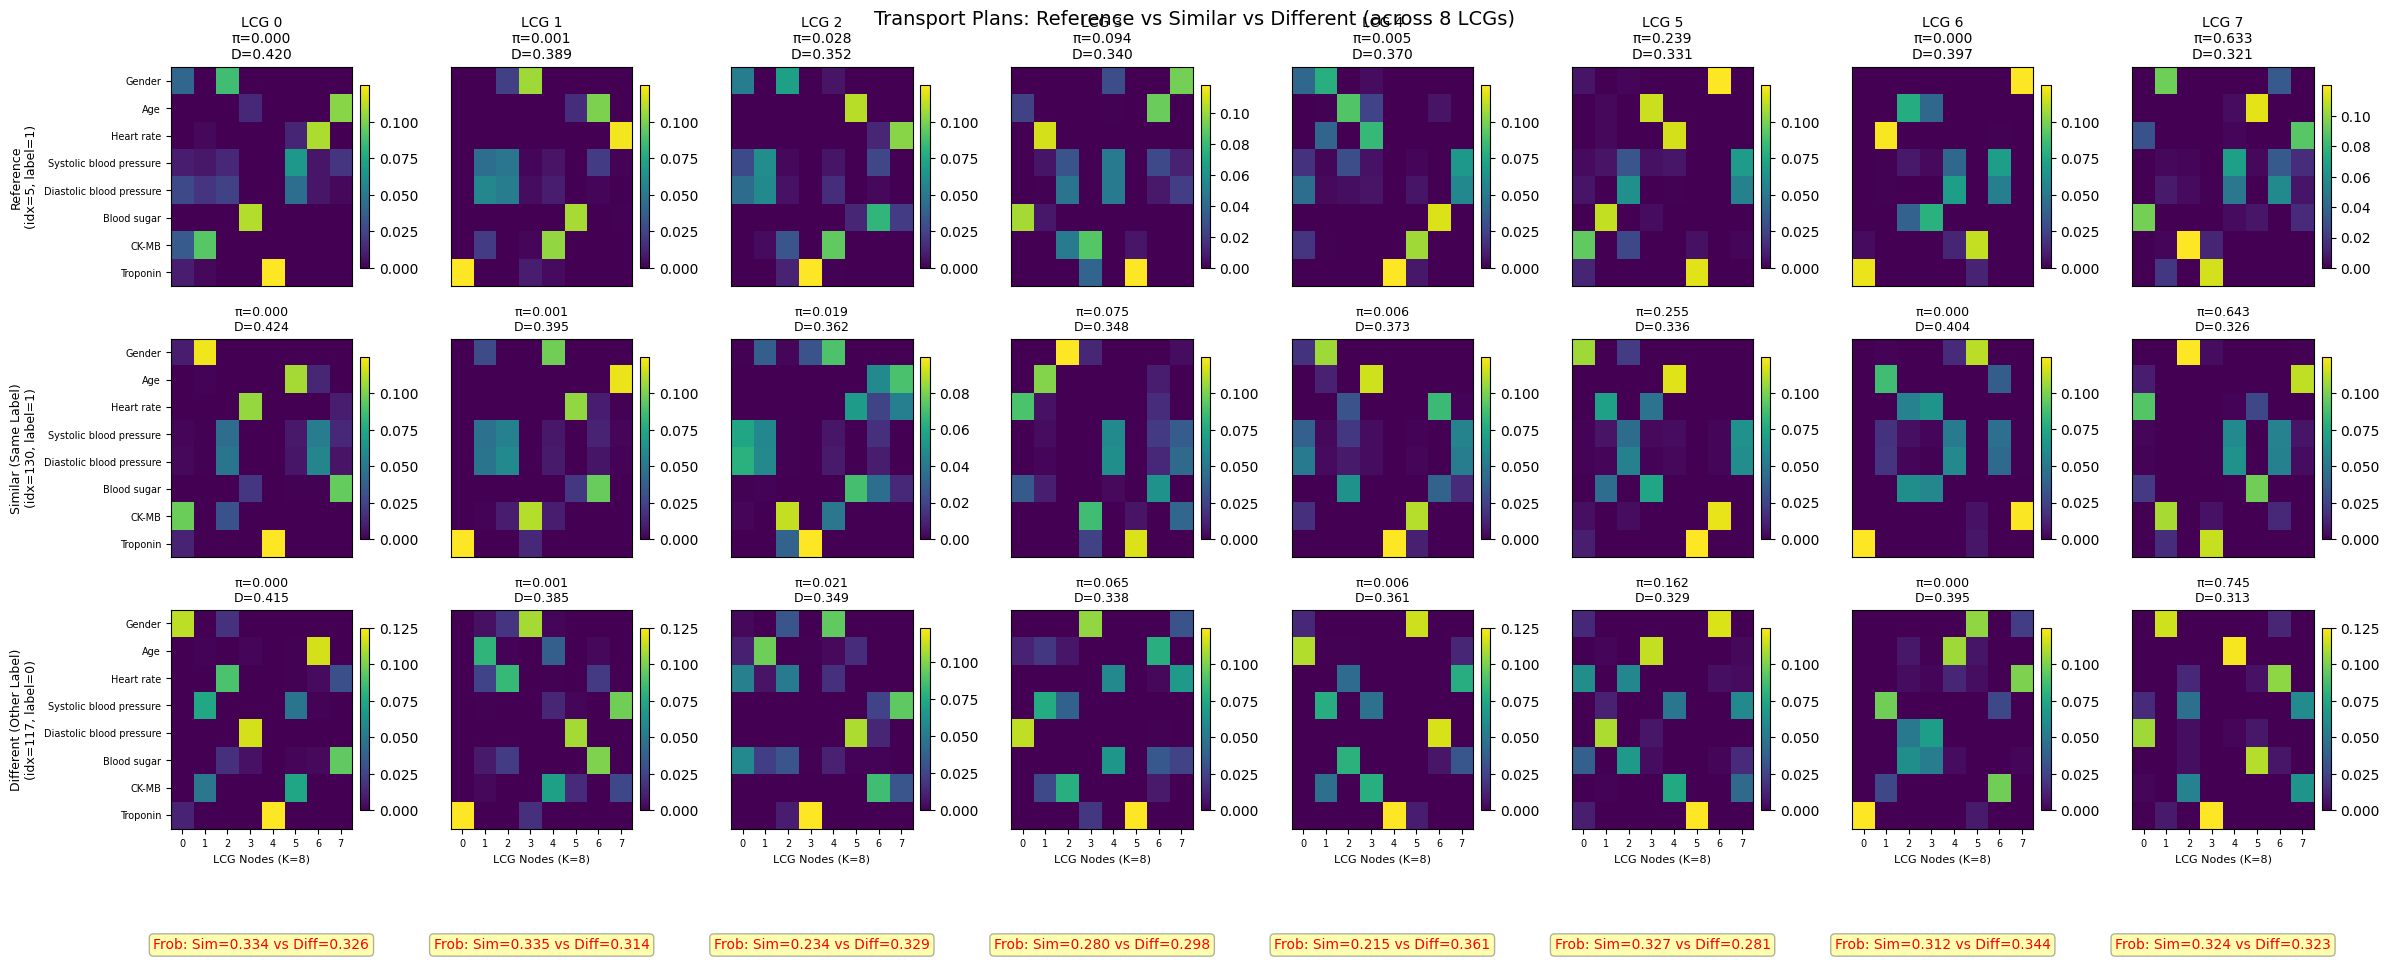

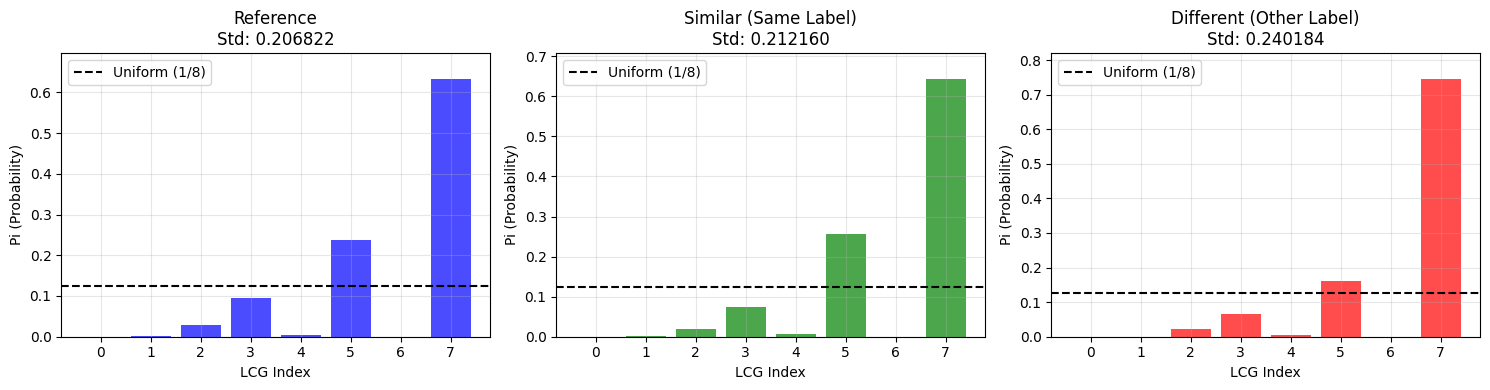

In [17]:
src = sources[0]
loader = loaders[src]
out = run_transport_plan_wrapup(
    model=model,
    loader=loader,
    device=device,
    source_name=src,
    reference_idx=5,
    distance_mode="affinity",
    extract_feature_names_fn=extract_feature_names  # 네가 이미 갖고 있으면
)

## Qualitative - Transport Plan, Coordinate (2)

In [18]:
import numpy as np
import torch
import matplotlib.pyplot as plt

# 네 환경에서 이미 쓰던 것 그대로
# from ot.batch import solve_gromov_batch


# =========================================================
# (A) 너가 준 그대로: loader -> embeddings / affinities / labels 수집
# =========================================================
@torch.no_grad()
def collect_all_samples_from_source(model, loader, device, extract_feature_names_fn):
    all_embeddings = []
    all_affinities = []
    all_labels = []
    all_feature_names = []

    for batch in loader:
        batch = {k: (v.to(device) if isinstance(v, torch.Tensor) else v) for k, v in batch.items()}

        # desc/name/value gather
        desc_embeddings, name_embeddings, value_embeddings = [], [], []
        if all(k in batch for k in ['cat_name_embeddings', 'cat_value_embeddings', 'cat_desc_embeddings']):
            desc_embeddings.append(batch['cat_desc_embeddings'])
            name_embeddings.append(batch['cat_name_embeddings'])
            value_embeddings.append(batch['cat_value_embeddings'])
        if all(k in batch for k in ['num_prompt_embeddings', 'num_desc_embeddings']):
            desc_embeddings.append(batch['num_desc_embeddings'])
            name_embeddings.append(batch['num_name_embeddings'])
            value_embeddings.append(batch['num_prompt_embeddings'])

        name  = torch.cat(name_embeddings, dim=1)
        value = torch.cat(value_embeddings, dim=1)

        B = value.size(0)

        # CLS + value token concat
        x_basis = torch.cat([model.basis_cls.expand(B, 1, model.input_dim), value], dim=1)

        last_att = None

        # each BasisGAT layer
        for l in range(model.num_basis_layers):
            norm_x = model.basis_layer_norms[l](x_basis)
            basis_outputs, att = model.basis_layers[l](name, norm_x)  # att: [B,H,T,T]
            last_att = att
            x_basis = x_basis + basis_outputs.reshape(x_basis.size(0), x_basis.size(1), model.input_dim)

        # last_att: [B,H,T,T] -> head 0
        last_att = last_att[:, 0, :, :]  # [B,T,T]

        # Feature names
        var_names = extract_feature_names_fn(batch)

        for b in range(B):
            # CLS 제외
            node_emb = x_basis[b, 1:, :].detach().cpu().numpy()  # [N,D]
            var_att  = last_att[b, 1:, 1:].detach().cpu().numpy()  # [N,N]
            affinity = 1.0 - var_att  # (너 코드 그대로)

            all_embeddings.append(node_emb)
            all_affinities.append(affinity)
            all_labels.append(int(batch['y'][b].item()))
            all_feature_names.append(var_names)

    return all_embeddings, all_affinities, all_labels, all_feature_names


# =========================================================
# (B) 너가 준 그대로: Frobenius distance
# =========================================================
def compute_frobenius_distances(embeddings, affinities):
    n = len(embeddings)
    emb_distances = np.zeros((n, n))
    aff_distances = np.zeros((n, n))

    for i in range(n):
        for j in range(i + 1, n):
            emb_diff = np.linalg.norm(embeddings[i] - embeddings[j], ord='fro')
            emb_distances[i, j] = emb_diff
            emb_distances[j, i] = emb_diff

            aff_diff = np.linalg.norm(affinities[i] - affinities[j], ord='fro')
            aff_distances[i, j] = aff_diff
            aff_distances[j, i] = aff_diff

    return emb_distances, aff_distances


# =========================================================
# (C) 핵심 수정: reference 기준
#   - similar: 같은 label 중 affinity distance 최소
#   - other  : 다른 label 중 affinity distance 최소 (attention은 유사, label만 다름)
# =========================================================
def find_similar_same_and_similar_other_by_label(reference_idx, distances, labels):
    n = len(labels)
    ref_label = labels[reference_idx]

    same_mask = np.array([labels[i] == ref_label for i in range(n)], dtype=bool)
    same_mask[reference_idx] = False

    other_mask = np.array([labels[i] != ref_label for i in range(n)], dtype=bool)

    if same_mask.sum() == 0:
        raise RuntimeError(f"No same-label sample exists for reference label={ref_label}")
    if other_mask.sum() == 0:
        raise RuntimeError("No other-label sample exists")

    d_same = distances[reference_idx].copy()
    d_same[~same_mask] = np.inf
    similar_idx = int(np.argmin(d_same))

    d_other = distances[reference_idx].copy()
    d_other[~other_mask] = np.inf
    other_idx = int(np.argmin(d_other))  # <-- '다른 레이블인데 attention 유사'를 강제

    return similar_idx, other_idx


# =========================================================
# (D) 너가 준 그대로: transport plan + pi
# =========================================================
@torch.no_grad()
def compute_transport_plans_for_samples(model, sample_indices, embeddings, affinities, device):
    lcg_feat, lcg_struct = model.latent_graph()  # [M,K,D], [M,K,K]
    M, K, D = lcg_feat.shape

    all_plans = []
    all_distances = []
    all_coordinates = []

    for idx in sample_indices:
        src_feat = torch.from_numpy(embeddings[idx]).float().to(device).unsqueeze(0)   # [1,N,D]
        src_str  = torch.from_numpy(affinities[idx]).float().to(device).unsqueeze(0)  # [1,N,N]
        N = src_feat.shape[1]

        src_feat_exp = src_feat.unsqueeze(1).expand(1, M, N, D).reshape(M, N, D)  # [M,N,D]
        src_str_exp  = src_str.unsqueeze(1).expand(1, M, N, N).reshape(M, N, N)   # [M,N,N]

        dist_sq = torch.cdist(src_feat_exp, lcg_feat, p=2) ** 2
        tau = model.graph_quantizer.tau
        M_cost = 1.0 - torch.exp(-dist_sq / (D * tau))

        a = torch.ones(M, N, device=device) / N
        b = torch.ones(M, K, device=device) / K

        alpha = model.graph_quantizer.alpha
        reg   = model.graph_quantizer.reg

        result = solve_gromov_batch(
            src_str_exp, lcg_struct, M=M_cost, alpha=alpha, reg=reg,
            a=a, b=b, max_iter=10, tol=1e-3, grad='envelope'
        )

        distances = result.value.detach().cpu().numpy()  # [M]
        plans     = result.plan.detach().cpu().numpy()   # [M,N,K]

        soft_tau = model.graph_quantizer.soft_tau
        pi = torch.softmax(-result.value / soft_tau, dim=0).detach().cpu().numpy()  # [M]

        all_plans.append(plans)
        all_distances.append(distances)
        all_coordinates.append(pi)

    return np.array(all_plans), np.array(all_distances), np.array(all_coordinates)  # [3,M,N,K], [3,M], [3,M]


# =========================================================
# (E) 너가 준 그대로: 3x8 plan grid
# =========================================================
def plot_transport_plans_grid(plans, coordinates, distances, sample_indices, labels, var_names):
    n_samples = 3
    n_lcgs = 8

    fig, axes = plt.subplots(n_samples, n_lcgs, figsize=(24, 9))
    sample_names = ['Reference', 'Similar (Same Label)', 'Different (Other Label)']

    frob_norms_similar = []
    frob_norms_different = []
    for j in range(n_lcgs):
        plan_ref = plans[0, j]
        plan_sim = plans[1, j]
        plan_diff = plans[2, j]
        frob_norms_similar.append(np.linalg.norm(plan_ref - plan_sim, ord='fro'))
        frob_norms_different.append(np.linalg.norm(plan_ref - plan_diff, ord='fro'))

    for i in range(n_samples):
        for j in range(n_lcgs):
            ax = axes[i, j]
            plan = plans[i, j]
            pi   = coordinates[i, j]
            dist = distances[i, j]

            im = ax.imshow(plan, cmap='viridis', aspect='auto')

            if i == 0:
                ax.set_title(f'LCG {j}\nπ={pi:.3f}\nD={dist:.3f}', fontsize=10)
            else:
                ax.set_title(f'π={pi:.3f}\nD={dist:.3f}', fontsize=9)

            if j == 0:
                ax.set_ylabel(
                    f'{sample_names[i]}\n(idx={sample_indices[i]}, label={labels[sample_indices[i]]})',
                    fontsize=9
                )
                ax.set_yticks(range(len(var_names)))
                ax.set_yticklabels(var_names, fontsize=7)
            else:
                ax.set_yticks([])

            if i == n_samples - 1:
                ax.set_xlabel(f'LCG Nodes (K={plan.shape[1]})', fontsize=8)
                ax.set_xticks(range(plan.shape[1]))
                ax.set_xticklabels(range(plan.shape[1]), fontsize=7)
            else:
                ax.set_xticks([])

            if i == n_samples - 1:
                ax.text(
                    0.5, -0.5,
                    f'Frob: Sim={frob_norms_similar[j]:.3f} vs Diff={frob_norms_different[j]:.3f}',
                    transform=ax.transAxes, ha='center', va='top',
                    fontsize=10, color='red',
                    bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.3)
                )

            plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.subplots_adjust(bottom=0.08)

    plt.show()


# =========================================================
# (F) 요청한 2x3: (위) coordinate bar / (아래) attention map
#   - coordinate 색: 파란/초록/빨강 (원래 코드 그대로)
#   - y-limit / uniform line / grid도 원래 코드 그대로
#   - [수정] colorbar가 attention map 위에 겹치지 않게: 오른쪽에 전용 cax를 만들어서 밖으로 뺌
# =========================================================
def plot_coord_and_attention_2x3(sample_indices, coordinates, affinities, labels, var_names, title_prefix=""):
    # coordinates: [3,M]
    M = coordinates.shape[1]

    # affinity = 1 - att 이었으니 attention 복원
    atts = [1.0 - affinities[idx] for idx in sample_indices]

    # attention 비교 가능하게 shared scale
    vmin = min(float(np.min(a)) for a in atts)
    vmax = max(float(np.max(a)) for a in atts)

    fig, axes = plt.subplots(2, 3, figsize=(18, 8))

    sample_names = ['Reference', 'Similar (Same Label)', 'Different (Other Label)']
    colors = ['blue', 'green', 'red']  # <-- 원래 코드 그대로

    # ---- top row: coordinate (원래 스타일 그대로) ----
    for i, (coord, name, color) in enumerate(zip(coordinates, sample_names, colors)):
        ax = axes[0, i]
        ax.bar(range(M), coord, color=color, alpha=0.7)
        ax.set_xlabel('LCG Index')
        ax.set_ylabel('Pi (Probability)')
        ax.set_title(f'{name}\nStd: {coord.std():.6f}')
        ax.set_ylim([0, max(0.2, float(coord.max()) * 1.1)])
        ax.axhline(y=1/M, color='black', linestyle='--', label=f'Uniform (1/{M})')
        ax.legend()
        ax.grid(True, alpha=0.3)

    # ---- bottom row: attention map ----
    ims = []
    for i in range(3):
        ax = axes[1, i]
        im = ax.imshow(atts[i], cmap='viridis', aspect='auto', vmin=vmin, vmax=vmax)
        ims.append(im)
        ax.set_title('Attention (Var-Var)')
        ax.set_xlabel('variables')
        ax.set_ylabel('variables')

        ax.set_xticks(range(len(var_names)))
        ax.set_yticks(range(len(var_names)))
        ax.set_xticklabels(var_names, rotation=90, fontsize=7)
        ax.set_yticklabels(var_names, fontsize=7)

    fig.suptitle(f'{title_prefix} 2x3: Coordinate(pi) + Attention map', fontsize=14)

    # [핵심] 오른쪽 공간을 먼저 확보하고, colorbar 전용 축(cax)을 만들어 바깥으로 뺌
    plt.tight_layout(rect=[0, 0, 0.92, 0.95])  # <-- 오른쪽 8% 비워두기

    # bottom-right attention axis 기준으로 cax 위치 계산(겹침 방지)
    pos = axes[1, 2].get_position()
    cax = fig.add_axes([pos.x1 + 0.01, pos.y0, 0.012, pos.height])  # (x, y, w, h)
    fig.colorbar(ims[-1], cax=cax)

    plt.show()


# =========================================================
# (G) WRAP-UP: 한 방에 실행
#   reference 기준:
#     - similar: same label & attention 유사(aff dist 최소)
#     - other  : other label & attention 유사(aff dist 최소)
# =========================================================
def run_ref_sim_other_attention_viz(
    model,
    loader,
    device,
    source_name,
    extract_feature_names_fn,
    reference_idx=0
):
    print(f"Collecting samples from source: {source_name}")
    embeddings, affinities, labels, feature_names_list = collect_all_samples_from_source(
        model=model,
        loader=loader,
        device=device,
        extract_feature_names_fn=extract_feature_names_fn
    )

    print(f"Total samples collected: {len(embeddings)}")
    print(f"Node embedding shape: {embeddings[0].shape}")
    print(f"Affinity shape: {affinities[0].shape}")

    print("Computing Frobenius distances...")
    emb_distances, aff_distances = compute_frobenius_distances(embeddings, affinities)

    similar_idx, other_idx = find_similar_same_and_similar_other_by_label(
        reference_idx=reference_idx,
        distances=aff_distances,
        labels=labels
    )

    print("\n=== Picked indices ===")
    print(f"Reference: {reference_idx} (label={labels[reference_idx]})")
    print(f"Similar (SAME label, min aff-dist): {similar_idx} (label={labels[similar_idx]}), dist={aff_distances[reference_idx, similar_idx]:.4f}")
    print(f"Other  (OTHER label, min aff-dist): {other_idx} (label={labels[other_idx]}), dist={aff_distances[reference_idx, other_idx]:.4f}")

    sample_indices = [int(reference_idx), int(similar_idx), int(other_idx)]

    # var names
    var_names = feature_names_list[0]
    if var_names is None:
        N = embeddings[0].shape[0]
        var_names = [f"v{i}" for i in range(N)]

    # FGW + 시각화
    plans, distances, coordinates = compute_transport_plans_for_samples(
        model=model,
        sample_indices=sample_indices,
        embeddings=embeddings,
        affinities=affinities,
        device=device
    )

    # 3x8 (원래 코드)
    plot_transport_plans_grid(
        plans=plans,
        coordinates=coordinates,
        distances=distances,
        sample_indices=sample_indices,
        labels=labels,
        var_names=var_names
    )

    # 2x3 (요청한 것 + coordinate 색/스타일 원래대로)  <-- 여기 colorbar 겹침 수정됨
    plot_coord_and_attention_2x3(
        sample_indices=sample_indices,
        coordinates=coordinates,
        affinities=affinities,
        labels=labels,
        var_names=var_names,
        title_prefix=f"[{source_name}]"
    )

    return {
        "embeddings": embeddings,
        "affinities": affinities,
        "labels": labels,
        "feature_names_list": feature_names_list,
        "aff_distances": aff_distances,
        "sample_indices": sample_indices,
        "plans": plans,
        "distances": distances,
        "coordinates": coordinates,
        "var_names": var_names
    }




Total samples collected: 1319
Node embedding shape: (8, 768)
Affinity shape: (8, 8)
Computing Frobenius distances...

=== Picked indices ===
Reference: 16 (label=0)
Similar (SAME label, min aff-dist): 1316 (label=0), dist=0.0889
Other  (OTHER label, min aff-dist): 650 (label=1), dist=0.1545


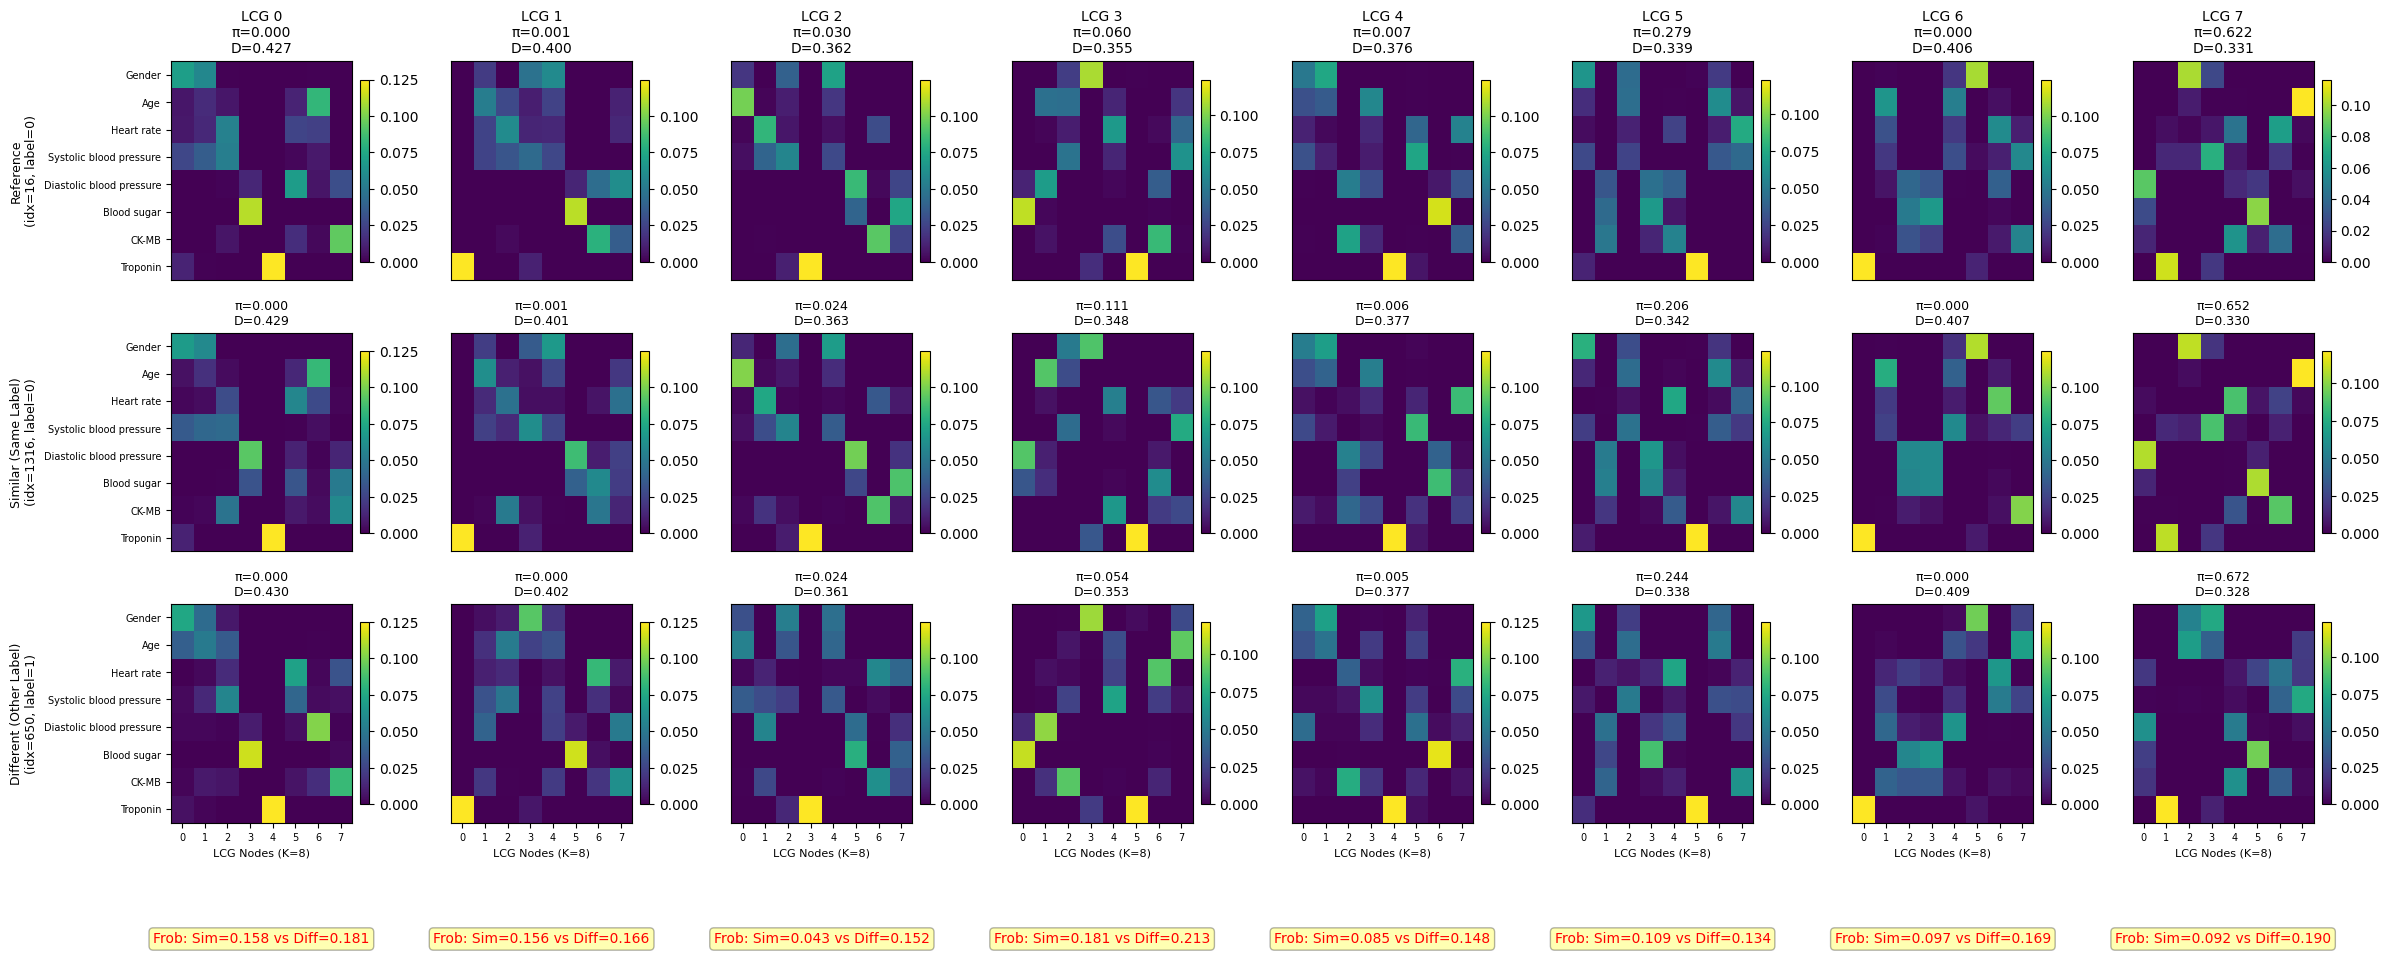

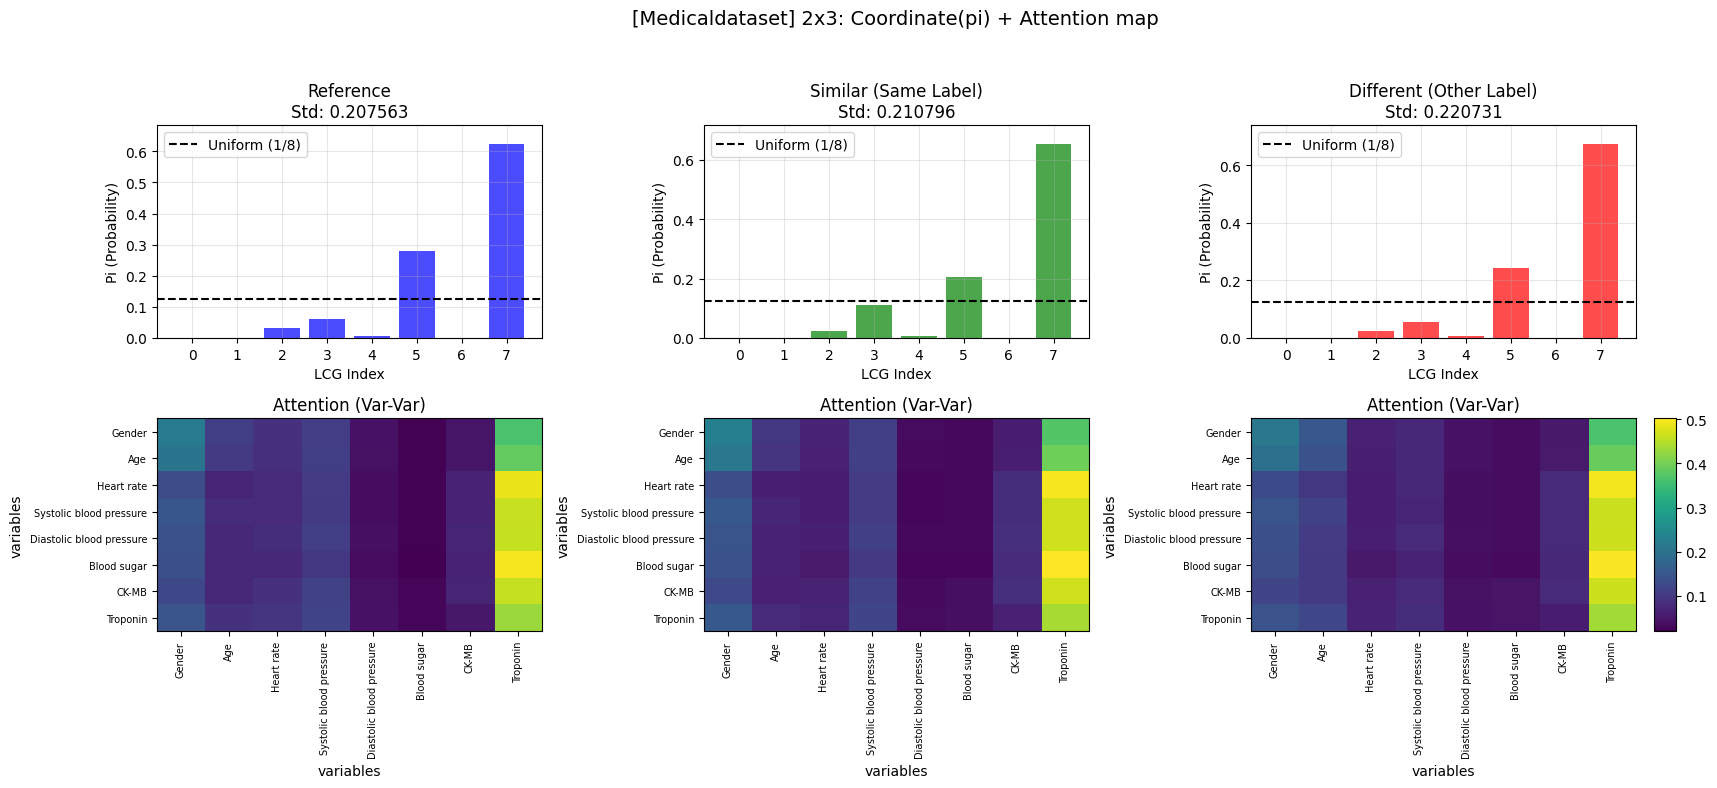

In [19]:

# =========================================================
# 실행 예시
# =========================================================
src = sources[0]
loader = loaders[src]
out = run_ref_sim_other_attention_viz(
    model=joint_model_pretrain,
    loader=loader,
    device=device,
    source_name=src,
    extract_feature_names_fn=extract_feature_names,
    reference_idx=16
)

## Coordinate Clustering

In [20]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from ot.batch import solve_gromov_batch

@torch.no_grad()
def _pi_batch(model, batch, device):
    batch = {k: (v.to(device) if isinstance(v, torch.Tensor) else v) for k, v in batch.items()}

    # ---- name/value gather (네 코드 규칙 그대로) ----
    name_embeddings, value_embeddings = [], []
    if all(k in batch for k in ['cat_name_embeddings', 'cat_value_embeddings', 'cat_desc_embeddings']):
        name_embeddings.append(batch['cat_name_embeddings'])
        value_embeddings.append(batch['cat_value_embeddings'])
    if all(k in batch for k in ['num_prompt_embeddings', 'num_desc_embeddings']):
        name_embeddings.append(batch['num_name_embeddings'])
        value_embeddings.append(batch['num_prompt_embeddings'])

    name  = torch.cat(name_embeddings, dim=1)   # [B, N, D]
    value = torch.cat(value_embeddings, dim=1)  # [B, N, D]
    B = value.size(0)

    # ---- basis forward to get last attention + node embeddings ----
    x_basis = torch.cat([model.basis_cls.expand(B, 1, model.input_dim), value], dim=1)

    last_att = None
    for l in range(model.num_basis_layers):
        norm_x = model.basis_layer_norms[l](x_basis)
        basis_outputs, att = model.basis_layers[l](name, norm_x)  # att: [B,H,T,T]
        last_att = att
        x_basis = x_basis + basis_outputs.reshape(x_basis.size(0), x_basis.size(1), model.input_dim)

    # ---- var node embeddings / affinity (1 - att) ----
    node_emb = x_basis[:, 1:, :]                 # [B, N, D]
    var_att  = last_att[:, 0, 1:, 1:]            # [B, N, N] (head0)
    src_str  = (1.0 - var_att).contiguous()      # [B, N, N]
    src_feat = node_emb.contiguous()             # [B, N, D]

    # ---- LCG ----
    lcg_feat, lcg_struct = model.latent_graph()  # [M,K,D], [M,K,K]
    M, K, D = lcg_feat.shape
    N = src_feat.shape[1]

    # ---- expand to (B*M) ----
    src_feat_exp = src_feat.unsqueeze(1).expand(B, M, N, D).reshape(B * M, N, D)
    src_str_exp  = src_str.unsqueeze(1).expand(B, M, N, N).reshape(B * M, N, N)
    lcg_feat_exp = lcg_feat.unsqueeze(0).expand(B, M, K, D).reshape(B * M, K, D)
    lcg_str_exp  = lcg_struct.unsqueeze(0).expand(B, M, K, K).reshape(B * M, K, K)

    # ---- feature cost with tau ----
    dist_sq = torch.cdist(src_feat_exp, lcg_feat_exp, p=2) ** 2
    scale_factor = dist_sq.max() + 1e-8
    dist_norm = dist_sq / scale_factor
    M_cost = 1.0 - torch.exp(-dist_norm / args.tau)

    a = torch.ones(B * M, N, device=device) / N
    b = torch.ones(B * M, K, device=device) / K

    alpha = model.graph_quantizer.alpha
    reg   = model.graph_quantizer.reg

    result = solve_gromov_batch(
        src_str_exp, lcg_str_exp, M=M_cost, alpha=alpha, reg=reg,
        a=a, b=b, max_iter=10, tol=1e-3, grad='envelope'
    )

    d = result.value.reshape(B, M)  # [B,M]
    soft_tau = model.graph_quantizer.soft_tau
    pi = torch.softmax(-d / soft_tau, dim=1)     # [B,M]
    return pi.detach().cpu().numpy()

def pi_wrap(model, loaders_by_src, device, max_batches=200, per_src=False, title="pi_pop"):
    model.eval()

    def _collect_for_loader(loader):
        pis = []
        for bi, batch in enumerate(loader):
            if (max_batches is not None) and (bi >= max_batches):
                break
            pi = _pi_batch(model, batch, device)   # [B,M]
            pis.append(pi)
        return np.concatenate(pis, axis=0) if len(pis) > 0 else None  # [N,M]

    def _plot(pis, tag):
        M = pis.shape[1]
        mean_pi = pis.mean(axis=0)                 # [M]
        usage = np.bincount(pis.argmax(axis=1), minlength=M) / pis.shape[0]

        fig, axes = plt.subplots(1, 2, figsize=(12, 4))
        axes[0].bar(range(M), mean_pi)
        axes[0].axhline(1.0/M, linestyle="--")
        axes[0].set_title(f"{tag} | mean(pi)")
        axes[0].set_xlabel("LCG index"); axes[0].set_ylabel("prob")

        axes[1].bar(range(M), usage)
        axes[1].axhline(1.0/M, linestyle="--")
        axes[1].set_title(f"{tag} | argmax usage")
        axes[1].set_xlabel("LCG index"); axes[1].set_ylabel("fraction")

        plt.tight_layout()
        plt.show()

    if per_src:
        out = {}
        for src, loader in loaders_by_src.items():
            pis = _collect_for_loader(loader)
            if pis is None:
                continue
            _plot(pis, f"{title}:{src} (n={pis.shape[0]})")
            out[src] = pis
        return out
    else:
        all_pis = []
        for src, loader in loaders_by_src.items():
            pis = _collect_for_loader(loader)
            if pis is None:
                continue
            all_pis.append(pis)
        pis = np.concatenate(all_pis, axis=0)
        _plot(pis, f"{title}:POOLED (n={pis.shape[0]})")
        return pis


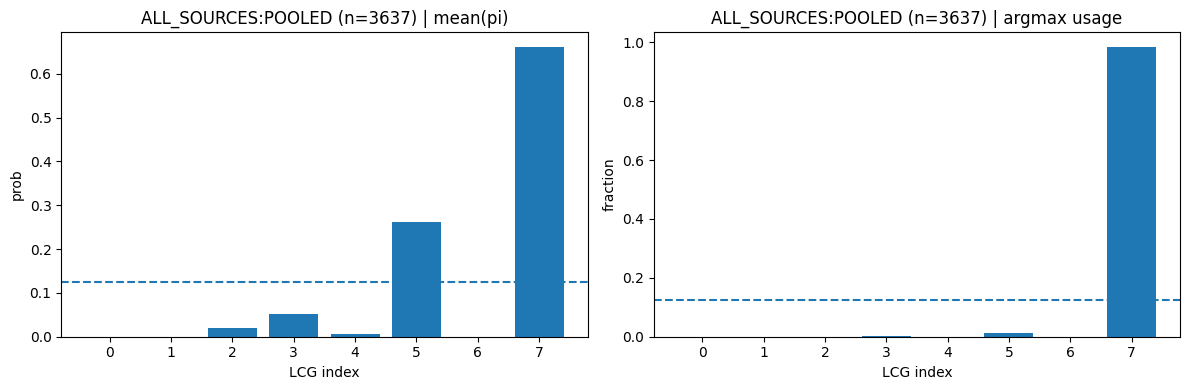

In [21]:
loaders_by_src = {src: loaders[src] for src in sources}  
pis = pi_wrap(model, loaders_by_src, device, max_batches=None, per_src=False, title="ALL_SOURCES")


## Qualitative Analysis 2. Latent Graph node usage

In [22]:
import matplotlib.pyplot as plt
import numpy as np
from collections import defaultdict

@torch.no_grad()
def collect_all_source_assignments(model, loaders, sources, device):
    """
    모든 source의 모든 샘플에 대해 LCG assignment 수집
    
    Returns:
        assignments: [N_total] - 각 샘플이 어느 LCG node에 할당되었는지
        source_labels: [N_total] - 각 샘플이 어느 source에서 왔는지
    """
    lcg_feat, lcg_struct = model.latent_graph()  # [M, K, D], [M, K, K]
    M, K, D = lcg_feat.shape
    
    all_assignments = []
    all_source_labels = []
    
    for src_idx, src in enumerate(sources):
        loader = loaders[src]
        
        for batch in loader:
            batch = {k: (v.to(device) if isinstance(v, torch.Tensor) else v) 
                    for k, v in batch.items()}
            
            # desc/name/value gather
            desc_embeddings, name_embeddings, value_embeddings = [], [], []
            if all(k in batch for k in ['cat_name_embeddings', 'cat_value_embeddings', 'cat_desc_embeddings']):
                desc_embeddings.append(batch['cat_desc_embeddings'])
                name_embeddings.append(batch['cat_name_embeddings'])
                value_embeddings.append(batch['cat_value_embeddings'])
            if all(k in batch for k in ['num_prompt_embeddings', 'num_desc_embeddings']):
                desc_embeddings.append(batch['num_desc_embeddings'])
                name_embeddings.append(batch['num_name_embeddings'])
                value_embeddings.append(batch['num_prompt_embeddings'])

            name = torch.cat(name_embeddings, dim=1)
            value = torch.cat(value_embeddings, dim=1)
            
            B = value.size(0)
            N = value.size(1)

            # CLS + value
            x_basis = torch.cat([model.basis_cls.expand(B, 1, model.input_dim), value], dim=1)

            # GAT forward
            last_att = None
            for l in range(model.num_basis_layers):
                norm_x = model.basis_layer_norms[l](x_basis)
                basis_outputs, att = model.basis_layers[l](name, norm_x)
                last_att = att
                x_basis = x_basis + basis_outputs.reshape(x_basis.size(0), x_basis.size(1), model.input_dim)

            # Source features (CLS 제외)
            src_feat = x_basis[:, 1:, :]  # [B, N, D]
            
            # Affinity (Var-Var, CLS 제외)
            src_str = 1.0 - last_att[:, 0, 1:, 1:]  # [B, N, N]
            
            # Expand for M LCGs
            src_feat_exp = src_feat.unsqueeze(1).expand(B, M, N, D).reshape(B*M, N, D)
            src_str_exp = src_str.unsqueeze(1).expand(B, M, N, N).reshape(B*M, N, N)
            
            lcg_feat_exp = lcg_feat.unsqueeze(0).expand(B, M, K, D).reshape(B*M, K, D)
            lcg_str_exp = lcg_struct.unsqueeze(0).expand(B, M, K, K).reshape(B*M, K, K)
            
            # FGW 계산
            dist_sq = torch.cdist(src_feat_exp, lcg_feat_exp, p=2) ** 2
            tau = model.graph_quantizer.tau
            M_cost = 1.0 - torch.exp(-dist_sq / (D * tau))
            
            a = torch.ones(B*M, N, device=device) / N
            b = torch.ones(B*M, K, device=device) / K
            
            alpha = model.graph_quantizer.alpha
            reg = model.graph_quantizer.reg
            
            result = solve_gromov_batch(
                src_str_exp, lcg_str_exp, M=M_cost, alpha=alpha, reg=reg,
                a=a, b=b, max_iter=10, tol=1e-3, grad='envelope'
            )
            
            # Transport Plan: [B*M, N, K] → [B, M, N, K]
            plan = result.plan.reshape(B, M, N, K)
            
            # 각 샘플의 각 node가 어느 LCG node에 가장 많이 할당되었는지
            # Plan shape: [B, M, N, K]
            # Max over (M, K) → 어느 (LCG, Node)에 가장 많이?
            plan_flat = plan.reshape(B, M*K, N)  # [B, M*K, N]
            
            for b in range(B):
                for n in range(N):
                    # 이 node의 transport plan: [M*K]
                    transport = plan_flat[b, :, n].detach().cpu().numpy()
                    
                    # 가장 높은 할당을 받은 (LCG, Node)
                    best_idx = np.argmax(transport)
                    
                    all_assignments.append(best_idx)
                    all_source_labels.append(src_idx)
    
    return np.array(all_assignments), np.array(all_source_labels)

def plot_codebook_usage_argmax(assignments, source_labels, sources, M=8, K=8):
    """
    Argmax 기반 codebook usage 시각화
    
    Args:
        assignments: [N_total] - LCG*K index (0~63)
        source_labels: [N_total] - source index (0~3)
        sources: list of source names
        M: number of LCGs
        K: number of nodes per LCG
    """
    # 무지개 색상 (8개 LCG)
    colors = plt.cm.rainbow(np.linspace(0, 1, M))
    
    # LCG별, Node별 카운트
    counts = np.zeros((M, K))
    
    for assignment in assignments:
        lcg_idx = assignment // K
        node_idx = assignment % K
        if lcg_idx < M and node_idx < K:
            counts[lcg_idx, node_idx] += 1
    
    # Plot
    fig, ax = plt.subplots(figsize=(18, 6))
    
    x_positions = []
    bar_colors = []
    bar_heights = []
    
    current_x = 0
    for m in range(M):
        for k in range(K):
            x_positions.append(current_x)
            bar_colors.append(colors[m])
            bar_heights.append(counts[m, k])
            current_x += 1
    
    bars = ax.bar(x_positions, bar_heights, color=bar_colors, edgecolor='black', linewidth=0.5)
    
    # X-axis labels
    ax.set_xlabel('LCG Node Index (Color=Graph ID)', fontsize=14)
    ax.set_ylabel('Selection Count', fontsize=14)
    ax.set_title('Best Init: Codebook Usage (Count of Argmax)', fontsize=16)
    
    # X-ticks
    ax.set_xticks(range(0, M*K, 5))
    ax.set_xticklabels(range(0, M*K, 5))
    
    # Grid
    ax.grid(axis='y', alpha=0.3)
    
    # LCG 경계선
    for m in range(1, M):
        ax.axvline(x=m*K - 0.5, color='black', linewidth=2, linestyle='--', alpha=0.5)
    
    plt.tight_layout()
    plt.show()
    
    # Statistics
    print("\n=== Codebook Usage Statistics (Argmax) ===")
    total_assignments = len(assignments)
    print(f"Total assignments: {total_assignments}")
    
    for m in range(M):
        lcg_count = counts[m].sum()
        print(f"LCG {m}: {int(lcg_count):5d} ({lcg_count/total_assignments*100:.1f}%)")
        
        # 가장 많이 사용된 node
        max_node = np.argmax(counts[m])
        max_count = counts[m, max_node]
        print(f"  → Most used node: {max_node} ({int(max_count)} times)")

Total samples collected: 41010
Assignment range: [0, 63]


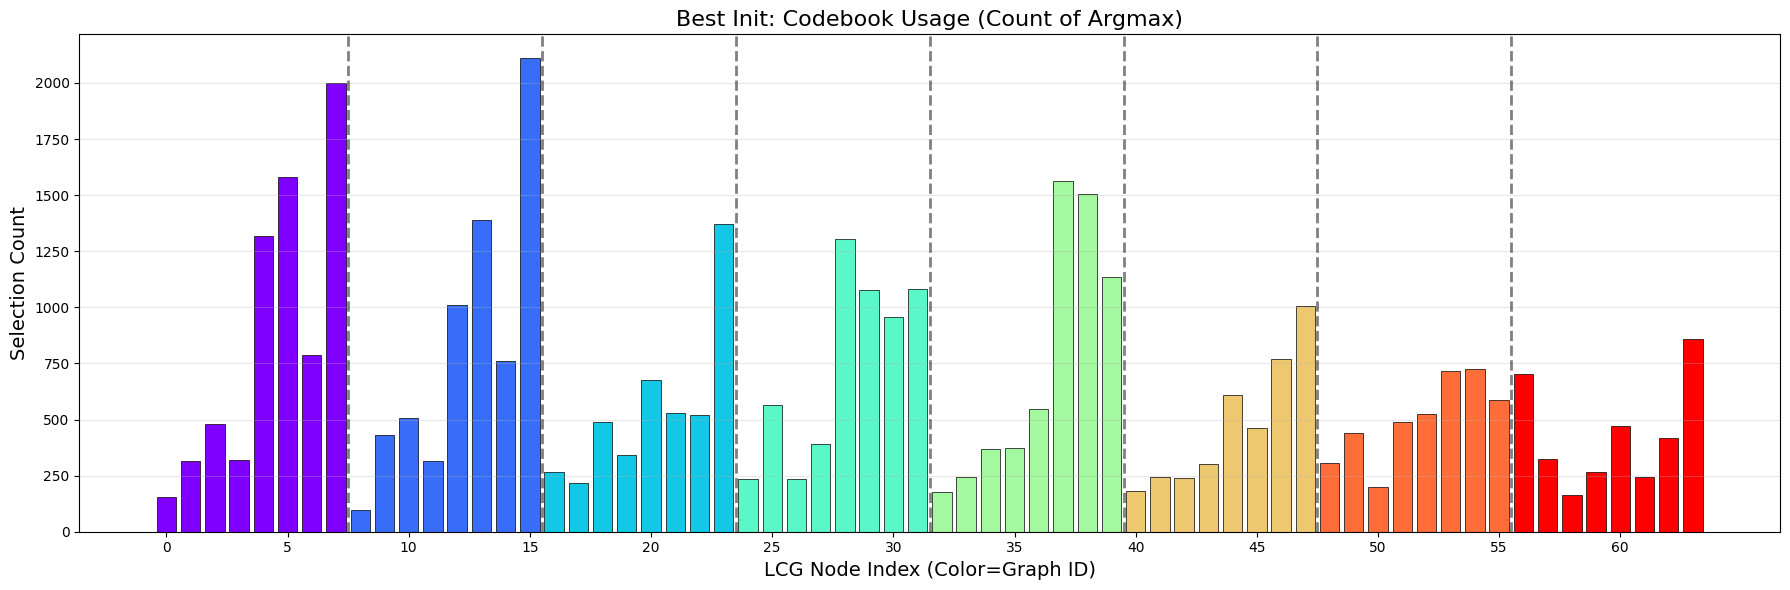


=== Codebook Usage Statistics (Argmax) ===
Total assignments: 41010
LCG 0:  6961 (17.0%)
  → Most used node: 7 (1998 times)
LCG 1:  6623 (16.1%)
  → Most used node: 7 (2111 times)
LCG 2:  4406 (10.7%)
  → Most used node: 7 (1371 times)
LCG 3:  5843 (14.2%)
  → Most used node: 4 (1304 times)
LCG 4:  5920 (14.4%)
  → Most used node: 5 (1565 times)
LCG 5:  3813 (9.3%)
  → Most used node: 7 (1007 times)
LCG 6:  3988 (9.7%)
  → Most used node: 6 (725 times)
LCG 7:  3456 (8.4%)
  → Most used node: 7 (861 times)


In [23]:
# 실행
print("Collecting assignments from all sources...")
assignments, source_labels = collect_all_source_assignments(
    joint_model_pretrain, loaders, sources, device
)

print(f"Total samples collected: {len(assignments)}")
print(f"Assignment range: [{assignments.min()}, {assignments.max()}]")

# 시각화
plot_codebook_usage_argmax(assignments, source_labels, sources, M=8, K=8)

## Qualitative Analysis 3 - Coordinates

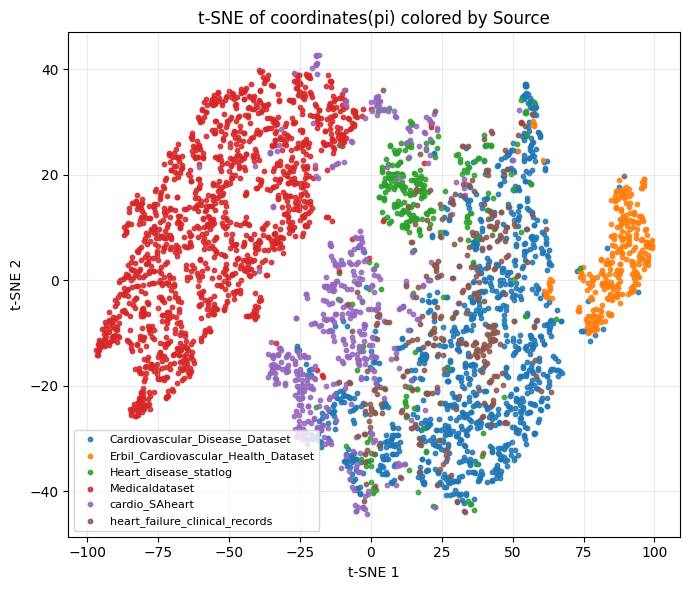

In [24]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

@torch.no_grad()
def collect_all_coordinates(model, loaders, device):
    model.eval()
    coords, labels, sources = [], [], []

    for src_name, loader in loaders.items():
        for batch in loader:
            batch = {k: (v.to(device) if torch.is_tensor(v) else v) for k, v in batch.items()}

            # LCG 경로를 타면서 pi 계산되게
            _ = model.predict(batch, return_all=True)

            pi = model.graph_quantizer.last_pi  # [B, M]
            if pi is None:
                raise RuntimeError("last_pi가 None임. use_lcg=True인지 확인해.")

            coords.append(pi.detach().cpu().numpy())
            sources.extend([src_name] * pi.shape[0])

            if "y" in batch:
                labels.extend(batch["y"].detach().cpu().numpy().reshape(-1).tolist())
            else:
                labels.extend([-1] * pi.shape[0])

    coords = np.concatenate(coords, axis=0)  # [N_total, M]
    labels = np.array(labels)
    sources = np.array(sources, dtype=object)
    return coords, labels, sources


# 1) collect
coords, labels, sources = collect_all_coordinates(model, loaders, device)
N = coords.shape[0]

# 2) t-SNE
perp = max(5, min(30, (N - 1) // 3))
tsne = TSNE(n_components=2, perplexity=perp, learning_rate=200, init="pca", random_state=42)
xy = tsne.fit_transform(coords)  # [N,2]

# 3) plot: color by SOURCE (no KMeans)
uniq_sources = sorted(list(set(sources.tolist())))

plt.figure(figsize=(7, 6))
for s in uniq_sources:
    mask = (sources == s)
    plt.scatter(
        xy[mask, 0], xy[mask, 1],
        s=10, alpha=0.85, label=str(s)
    )

plt.title("t-SNE of coordinates(pi) colored by Source")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.grid(True, alpha=0.25)
plt.legend(fontsize=8, frameon=True, loc="best")
plt.tight_layout()
plt.show()


In [25]:
loaders

{'Medicaldataset': <torch.utils.data.dataloader.DataLoader at 0x7f60b9f629e0>,
 'Cardiovascular_Disease_Dataset': <torch.utils.data.dataloader.DataLoader at 0x7f5e9c2f4a60>,
 'Heart_disease_statlog': <torch.utils.data.dataloader.DataLoader at 0x7f5e9c2f4940>,
 'Erbil_Cardiovascular_Health_Dataset': <torch.utils.data.dataloader.DataLoader at 0x7f5ec009fd60>,
 'cardio_SAheart': <torch.utils.data.dataloader.DataLoader at 0x7f5e9c2f5390>,
 'heart_failure_clinical_records': <torch.utils.data.dataloader.DataLoader at 0x7f5e9c183250>}

Using source: Heart_disease_statlog


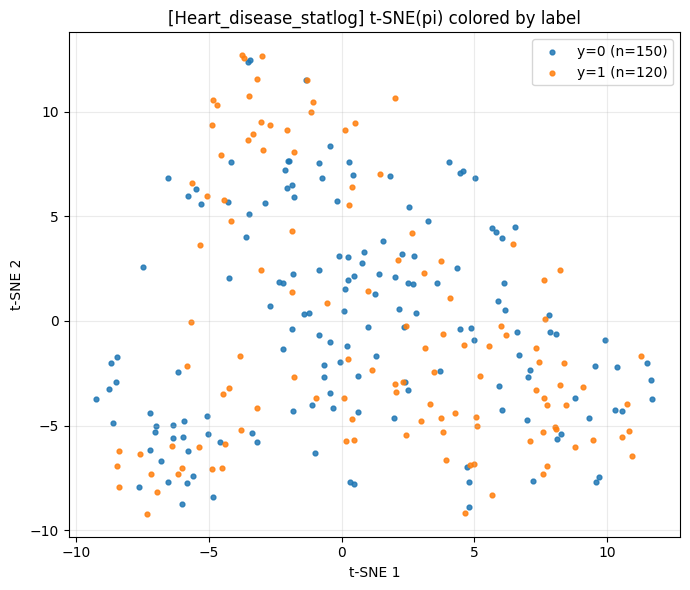

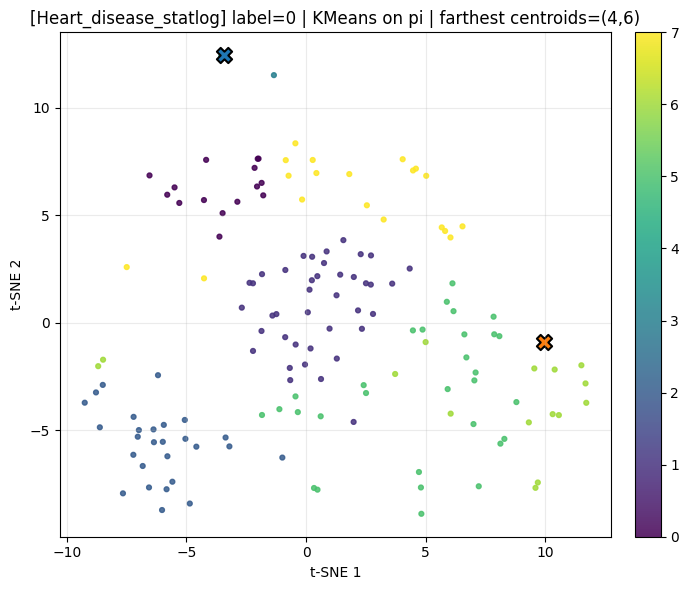

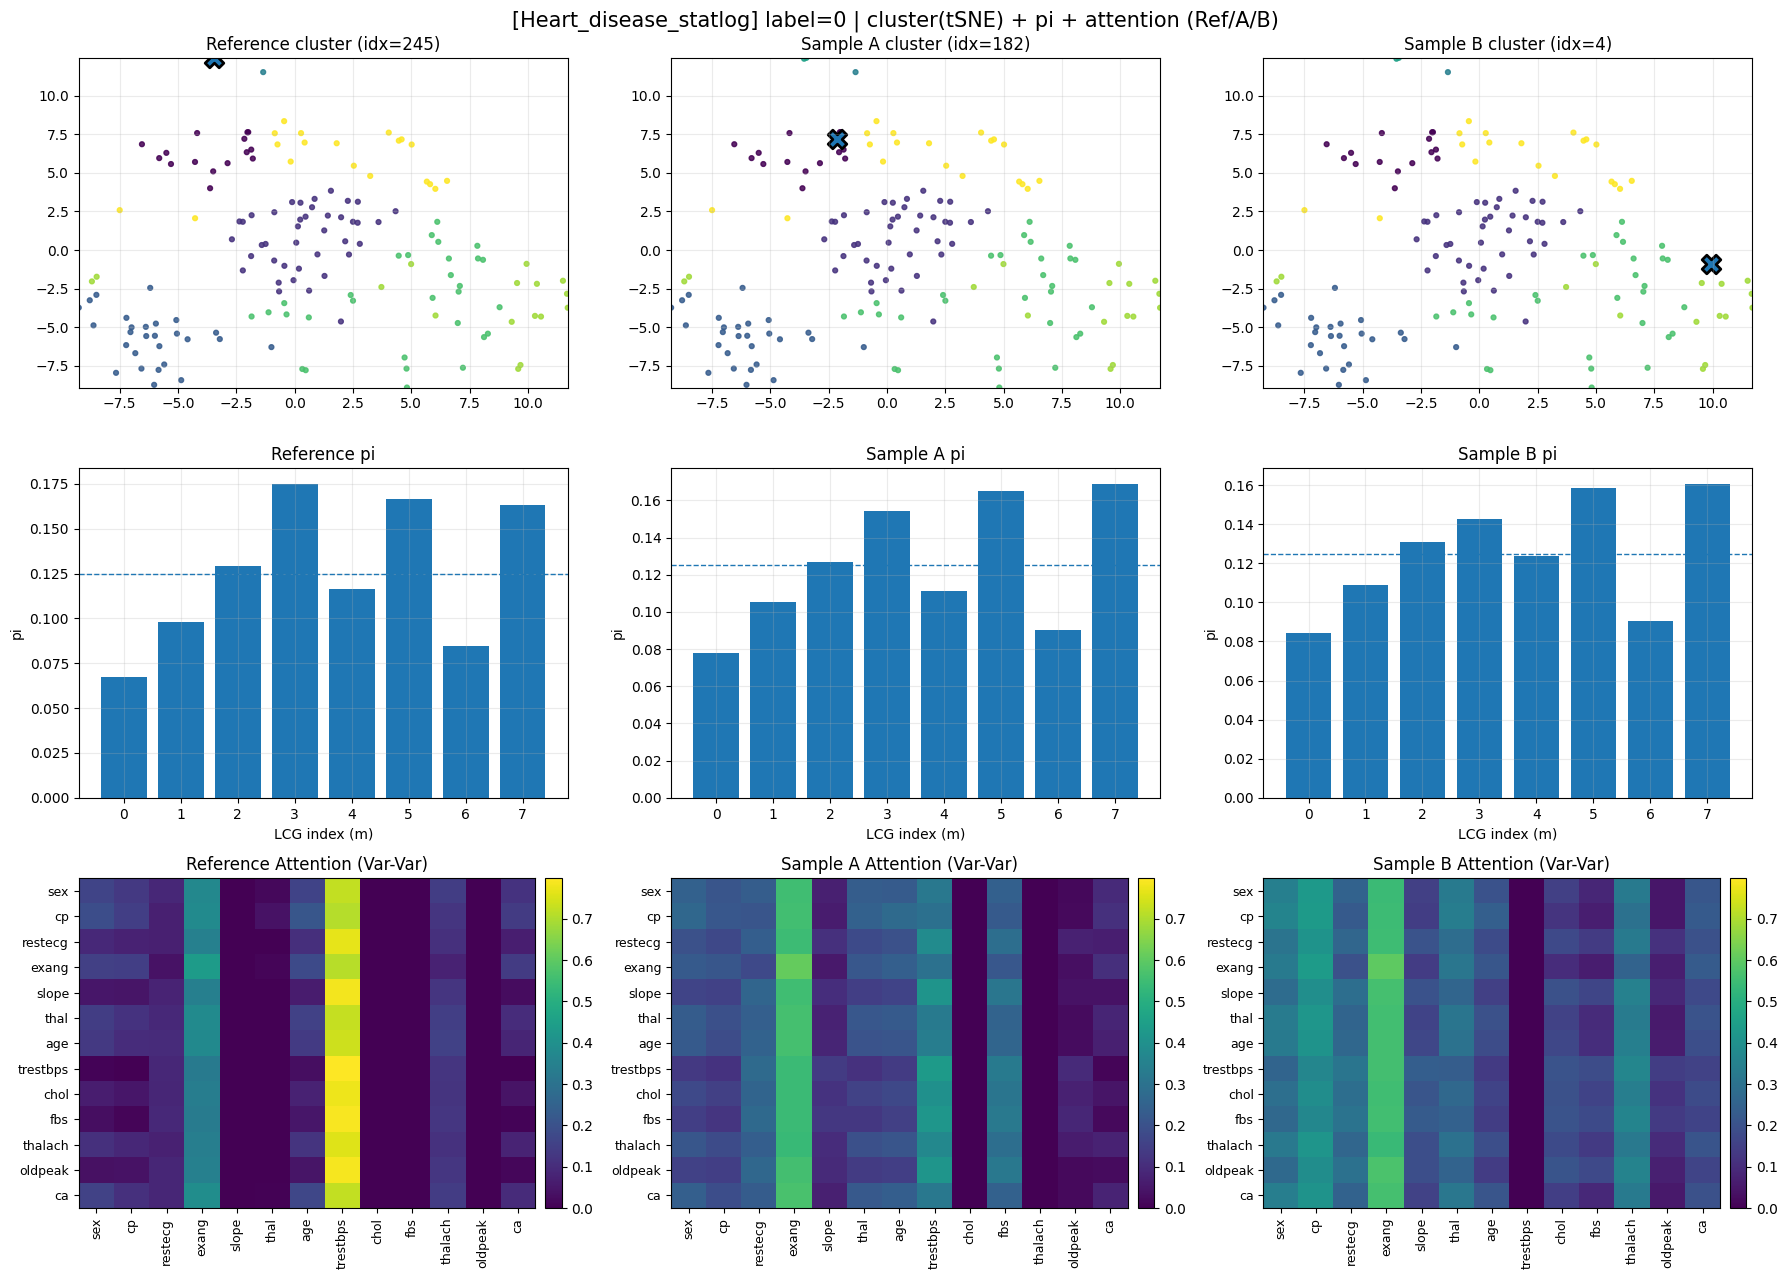

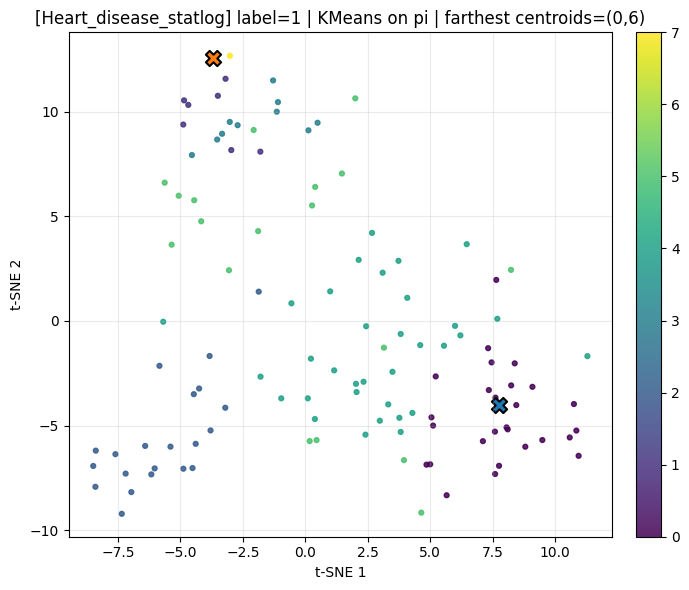

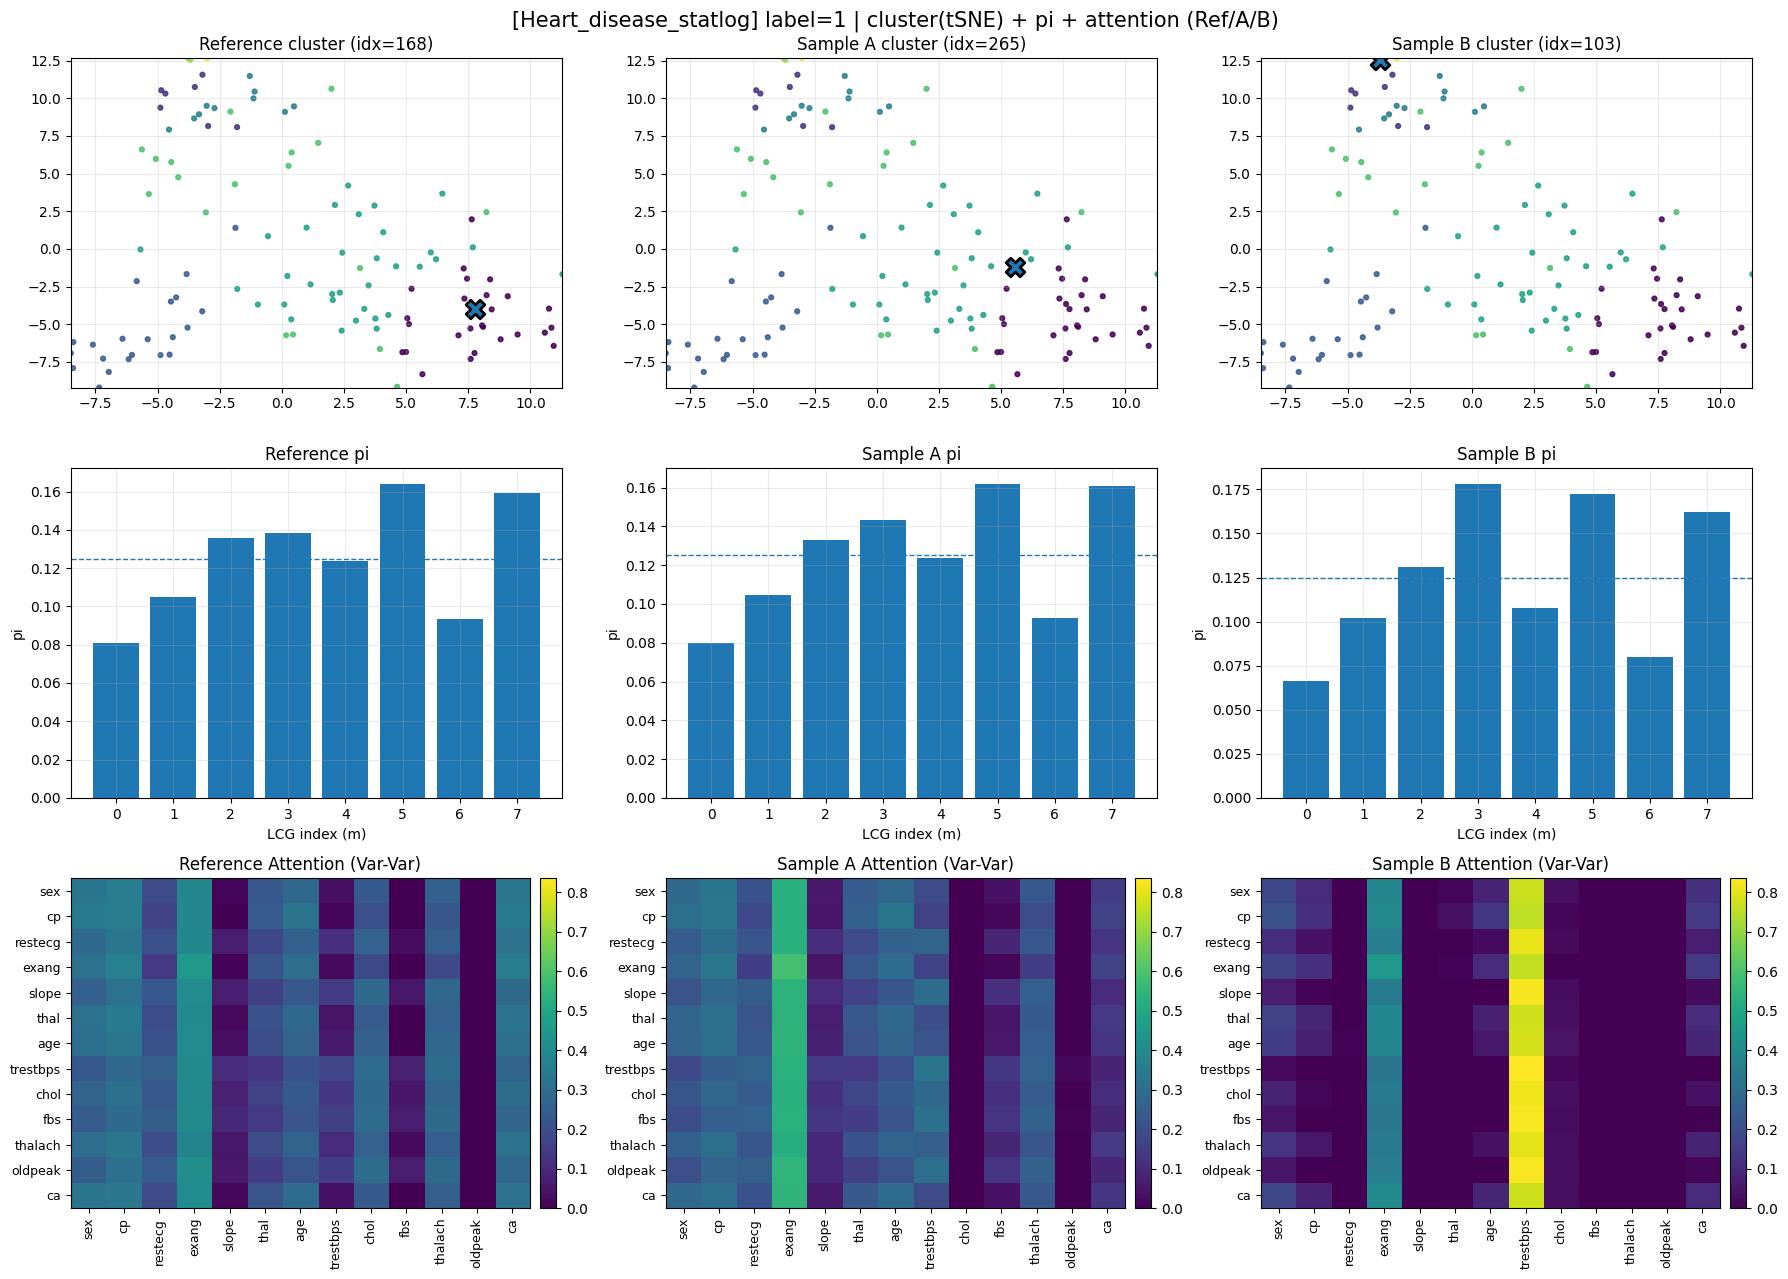

In [26]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans

# ----------------------------
# 0) Medicaldataset loader 찾기
# ----------------------------
def get_loader_by_key(loaders, key="heart"):
    for k in loaders.keys():
        if str(k).lower() == str(key).lower():
            return k, loaders[k]
    for k in loaders.keys():
        if str(key).lower() in str(k).lower():
            return k, loaders[k]
    raise KeyError(f"'{key}' loader not found. available={list(loaders.keys())}")

# ----------------------------
# 0.5) 변수 이름 추출 (중복 제거 X, 길이 최대한 유지)
# ----------------------------
def extract_feature_names(batch):
    names = []

    if 'cat_desc_texts' in batch:
        for t in batch['cat_desc_texts']:
            v = t[0] if isinstance(t, (tuple, list)) and len(t) > 0 else t
            names.append(str(v).split(",")[0].split("'")[0].strip())

    if 'num_desc_texts' in batch:
        for t in batch['num_desc_texts']:
            v = t[0] if isinstance(t, (tuple, list)) and len(t) > 0 else t
            names.append(str(v).split(",")[0].split("'")[0].strip())

    return names

# ------------------------------------------------------
# 1) Medicaldataset 전체에서 pi + attention 수집
# ------------------------------------------------------
@torch.no_grad()
def collect_pi_and_affinity_for_one_source(model, loader, device):
    model.eval()
    pis = []
    ys = []
    affs = []
    names = []

    for batch in loader:
        batch_t = {k: (v.to(device) if torch.is_tensor(v) else v) for k, v in batch.items()}

        _ = model.predict(batch_t, return_all=True)

        pi = model.graph_quantizer.last_pi          # [B, M]
        P_1matt  = model._last_P_basis              # [B, N, N]  == (1 - att)

        if pi is None or P_1matt is None:
            raise RuntimeError("pi 또는 _last_P_basis가 None. args.use_lcg=True인지 확인.")

        # attention 자체로 변환
        att = 1.0 - P_1matt
        att = torch.clamp(att, 0.0, 1.0)

        # 변수명은 batch 기준으로 뽑음 (배치 내 샘플들 동일 전제)
        var_names = extract_feature_names(batch)

        B = pi.shape[0]
        for b in range(B):
            A = att[b].detach().cpu().numpy()
            N = A.shape[0]

            # 축 라벨 길이를 A 크기에 맞춤 (v0 같은 거 안 쓰고, 가능한 이름만 씀)
            if N == len(var_names) + 1:
                node_names = ["CLS"] + var_names
            elif N == len(var_names):
                node_names = var_names
            elif N < len(var_names):
                node_names = var_names[:N]
            else:
                node_names = var_names + [""] * (N - len(var_names))

            pis.append(pi[b].detach().cpu().numpy())              # [M]
            ys.append(int(batch_t["y"][b].item()))
            affs.append(A)                                        # [N,N]  (attention)
            names.append(node_names)                              # 길이 N 라벨

    pis = np.stack(pis, axis=0)
    ys  = np.array(ys, dtype=int)
    return pis, ys, affs, names

# ------------------------------------------------------
# 2) label 내부 KMeans + "가장 먼 centroid 2개"
# ------------------------------------------------------
def kmeans_farthest_centroids_pick_samples(pis, ys, label, k=8, seed=42):
    idx = np.where(ys == label)[0]
    if len(idx) < 2:
        raise ValueError(f"label={label} samples too few: {len(idx)}")

    X = pis[idx]  # [n_lab, M]
    k_eff = min(k, len(idx))
    km = KMeans(n_clusters=k_eff, random_state=seed, n_init=20)
    cid = km.fit_predict(X)
    C = km.cluster_centers_  # [k_eff, M]

    dist = np.linalg.norm(C[:, None, :] - C[None, :, :], axis=-1)
    np.fill_diagonal(dist, -np.inf)
    a, b = np.unravel_index(np.argmax(dist), dist.shape)

    def pick_nearest(centroid):
        d = np.linalg.norm(X - centroid[None, :], axis=1)
        return idx[int(np.argmin(d))]

    samp_a = pick_nearest(C[a])
    samp_b = pick_nearest(C[b])

    return {
        "idx_lab": idx,
        "X_lab": X,
        "cid": cid,
        "km": km,
        "centroid_pair": (a, b),
        "sample_pair": (samp_a, samp_b),
    }

# ------------------------------------------------------
# 3) Plot: (i) label별 전체 tSNE, (ii) label 내부 cluster tSNE
# ------------------------------------------------------
def plot_tsne_by_label(pis, ys, title_prefix="[heart]", seed=42):
    N = pis.shape[0]
    perp = max(5, min(40, (N - 1) // 3))
    xy = TSNE(n_components=2, perplexity=perp, learning_rate=200, init="pca", random_state=seed).fit_transform(pis)

    plt.figure(figsize=(7, 6))
    for lab in [0, 1]:
        m = (ys == lab)
        plt.scatter(xy[m, 0], xy[m, 1], s=12, alpha=0.85, label=f"y={lab} (n={m.sum()})")
    plt.title(f"{title_prefix} t-SNE(pi) colored by label")
    plt.xlabel("t-SNE 1"); plt.ylabel("t-SNE 2")
    plt.grid(True, alpha=0.25)
    plt.legend(frameon=True)
    plt.tight_layout()
    plt.show()
    return xy

def plot_label_clusters_and_pick(xy_all, result, ys, label, title_prefix="[heart]"):
    idx = result["idx_lab"]
    cid = result["cid"]
    samp_a, samp_b = result["sample_pair"]

    xy = xy_all[idx]

    plt.figure(figsize=(7, 6))
    sc = plt.scatter(xy[:, 0], xy[:, 1], c=cid, s=12, alpha=0.85)

    ia = np.where(idx == samp_a)[0][0]
    ib = np.where(idx == samp_b)[0][0]
    plt.scatter(xy[ia, 0], xy[ia, 1], s=120, marker="X", edgecolors="black", linewidths=1.5)
    plt.scatter(xy[ib, 0], xy[ib, 1], s=120, marker="X", edgecolors="black", linewidths=1.5)

    a, b = result["centroid_pair"]
    plt.title(f"{title_prefix} label={label} | KMeans on pi | farthest centroids=({a},{b})")
    plt.xlabel("t-SNE 1"); plt.ylabel("t-SNE 2")
    plt.grid(True, alpha=0.25)
    plt.colorbar(sc, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()

# ------------------------------------------------------
# (NEW) centroid(a0) 기준 ref / A / B 뽑기
# ------------------------------------------------------
def pick_ref_A_B_near_centroids(res):
    idx_lab = res["idx_lab"]          # global indices for this label
    X       = res["X_lab"]            # [n_lab, M]
    cid     = res["cid"]              # [n_lab]
    C       = res["km"].cluster_centers_
    a0, b0  = res["centroid_pair"]    # farthest centroid pair

    cent0   = C[a0]
    centfar = C[b0]

    d0   = np.linalg.norm(X - cent0[None, :], axis=1)
    dfar = np.linalg.norm(X - centfar[None, :], axis=1)

    # Reference: centroid(a0)에서 자기 cluster(a0) 내부 가장 가까운 샘플
    mask_ref = (cid == a0)
    ref_local = int(np.argmin(np.where(mask_ref, d0, np.inf)))
    ref_global = int(idx_lab[ref_local])

    # Sample A: centroid(a0)에서 다른 cluster 중 가장 가까운 샘플
    mask_A = (cid != a0)
    if mask_A.sum() == 0:
        A_local = ref_local
    else:
        A_local = int(np.argmin(np.where(mask_A, d0, np.inf)))
    A_global = int(idx_lab[A_local])

    # Sample B: farthest centroid(b0)에서 자기 cluster(b0) 내부 가장 가까운 샘플
    mask_B = (cid == b0)
    B_local = int(np.argmin(np.where(mask_B, dfar, np.inf)))
    B_global = int(idx_lab[B_local])

    return {
        "a0": a0, "b0": b0,
        "ref_global": ref_global, "A_global": A_global, "B_global": B_global,
        "ref_local": ref_local, "A_local": A_local, "B_local": B_local,
    }

# ------------------------------------------------------
# (NEW) 2x3 plot: coord(3) + attention(3) with 변수명
# ------------------------------------------------------
def plot_three_samples_cluster_pi_attention_3x3(
    xy_all, res, pis, affs, names,
    ref_global, A_global, B_global,
    ref_local, A_local, B_local,
    title
):
    """
    3x3 grid (requested order):
      row0: cluster(tSNE) scatter + highlight (Ref/A/B)
      row1: pi bar (Ref/A/B)
      row2: attention heatmap (Ref/A/B)
    """
    idx_lab = res["idx_lab"]
    cid     = res["cid"]
    xy_lab  = xy_all[idx_lab]   # [n_lab, 2]

    # --- data ---
    pi_ref = pis[ref_global]
    pi_A   = pis[A_global]
    pi_B   = pis[B_global]

    A_ref = affs[ref_global]
    A_A   = affs[A_global]
    A_B   = affs[B_global]

    n_ref = names[ref_global]
    n_A   = names[A_global]
    n_B   = names[B_global]

    # --- scales ---
    vmin = min(A_ref.min(), A_A.min(), A_B.min())
    vmax = max(A_ref.max(), A_A.max(), A_B.max())

    x_min, x_max = xy_lab[:, 0].min(), xy_lab[:, 0].max()
    y_min, y_max = xy_lab[:, 1].min(), xy_lab[:, 1].max()

    M = pi_ref.shape[0]
    uniform = 1.0 / M

    fig, axes = plt.subplots(3, 3, figsize=(18, 13))

    # ----------------
    # helpers
    # ----------------
    def draw_cluster(ax, highlight_local, panel_title):
        ax.scatter(xy_lab[:, 0], xy_lab[:, 1], c=cid, s=12, alpha=0.85)
        ax.scatter(
            xy_lab[highlight_local, 0], xy_lab[highlight_local, 1],
            s=180, marker="X", edgecolors="black", linewidths=2.0
        )
        ax.set_title(panel_title, fontsize=12)
        ax.set_xlim(x_min, x_max)
        ax.set_ylim(y_min, y_max)
        ax.grid(True, alpha=0.25)

    def draw_pi(ax, pi, panel_title):
        ax.bar(np.arange(len(pi)), pi)
        ax.axhline(uniform, linestyle="--", linewidth=1)
        ax.set_title(panel_title, fontsize=12)
        ax.set_xlabel("LCG index (m)")
        ax.set_ylabel("pi")
        ax.grid(True, alpha=0.25)

    def draw_att(ax, A, node_names, att_title):
        N = A.shape[0]
        labels = list(node_names)
        if len(labels) > N:
            labels = labels[:N]
        elif len(labels) < N:
            labels = labels + [""] * (N - len(labels))  # 빈칸 패딩

        im = ax.imshow(A, vmin=vmin, vmax=vmax, aspect="auto")
        ax.set_title(att_title, fontsize=12)
        ax.set_xticks(range(N)); ax.set_yticks(range(N))
        ax.set_xticklabels(labels, rotation=90, fontsize=9)
        ax.set_yticklabels(labels, fontsize=9)
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.02)

    # ----------------
    # row 0: cluster(tSNE)
    # ----------------
    draw_cluster(
        axes[0, 0], ref_local,
        f"Reference cluster (idx={ref_global})"
    )
    draw_cluster(
        axes[0, 1], A_local,
        f"Sample A cluster (idx={A_global})"
    )
    draw_cluster(
        axes[0, 2], B_local,
        f"Sample B cluster (idx={B_global})"
    )

    # ----------------
    # row 1: pi bars
    # ----------------
    draw_pi(axes[1, 0], pi_ref, f"Reference pi")
    draw_pi(axes[1, 1], pi_A,   f"Sample A pi")
    draw_pi(axes[1, 2], pi_B,   f"Sample B pi")

    # ----------------
    # row 2: attention
    # ----------------
    draw_att(axes[2, 0], A_ref, n_ref, "Reference Attention (Var-Var)")
    draw_att(axes[2, 1], A_A,   n_A,   "Sample A Attention (Var-Var)")
    draw_att(axes[2, 2], A_B,   n_B,   "Sample B Attention (Var-Var)")

    fig.suptitle(title, fontsize=15)
    plt.tight_layout()
    plt.show()


# ============================
# RUN (Medicaldataset only)
# ============================
src_key, medical_loader = get_loader_by_key(loaders, "heart")
print("Using source:", src_key)

pis, ys, affs, names = collect_pi_and_affinity_for_one_source(model, medical_loader, device)

xy_all = plot_tsne_by_label(pis, ys, title_prefix=f"[{src_key}]")

for lab in [0, 1]:
    res = kmeans_farthest_centroids_pick_samples(pis, ys, label=lab, k=8, seed=42)
    plot_label_clusters_and_pick(xy_all, res, ys, label=lab, title_prefix=f"[{src_key}]")

    picked = pick_ref_A_B_near_centroids(res)

    plot_three_samples_cluster_pi_attention_3x3(
    xy_all=xy_all,
    res=res,
    pis=pis,
    affs=affs,
    names=names,
    ref_global=picked["ref_global"],
    A_global=picked["A_global"],
    B_global=picked["B_global"],
    ref_local=picked["ref_local"],
    A_local=picked["A_local"],
    B_local=picked["B_local"],
    title=f"[{src_key}] label={lab} | cluster(tSNE) + pi + attention (Ref/A/B)"
)


## Source 별로 분석 - Coordinate based Clustering 

In [27]:
def viz_source_pi_attn(model, loaders, device, source_key, k=8, seed=42, labs=(0, 1)):
    src_key, loader = get_loader_by_key(loaders, source_key)
    print("Using source:", src_key)

    pis, ys, affs, names = collect_pi_and_affinity_for_one_source(model, loader, device)
    xy_all = plot_tsne_by_label(pis, ys, title_prefix=f"[{src_key}]", seed=seed)

    per_label = {}
    for lab in labs:
        res = kmeans_farthest_centroids_pick_samples(pis, ys, label=lab, k=k, seed=seed)
        plot_label_clusters_and_pick(xy_all, res, ys, label=lab, title_prefix=f"[{src_key}]")

        picked = pick_ref_A_B_near_centroids(res)

        # ✅ 여기 추가: Ref/A/B의 coordinate(pi) 벡터도 같이 저장
        picked["ref_pi"] = np.array(pis[picked["ref_global"]], copy=True)
        picked["A_pi"]   = np.array(pis[picked["A_global"]],   copy=True)
        picked["B_pi"]   = np.array(pis[picked["B_global"]],   copy=True)

        plot_three_samples_cluster_pi_attention_3x3(
            xy_all=xy_all,
            res=res,
            pis=pis,
            affs=affs,
            names=names,
            ref_global=picked["ref_global"],
            A_global=picked["A_global"],
            B_global=picked["B_global"],
            ref_local=picked["ref_local"],
            A_local=picked["A_local"],
            B_local=picked["B_local"],
            title=f"[{src_key}] label={lab} | cluster(tSNE) + pi + attention (Ref/A/B)"
        )

        per_label[lab] = {"res": res, "picked": picked}

    return {
        "src_key": src_key,
        "pis": pis,
        "ys": ys,
        "affs": affs,
        "names": names,
        "xy_all": xy_all,
        "per_label": per_label,
    }

Using source: Heart_disease_statlog


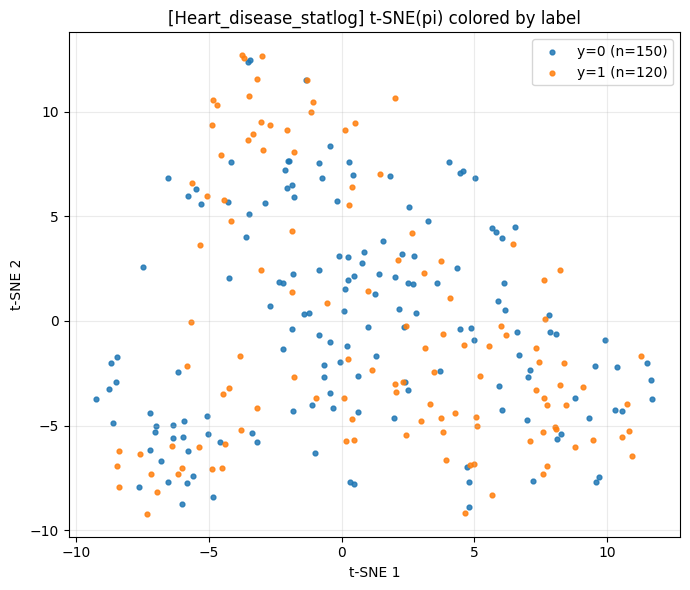

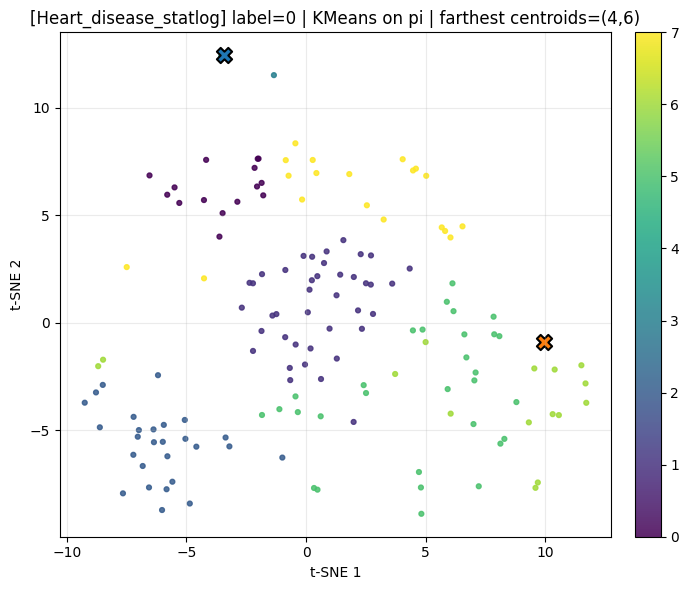

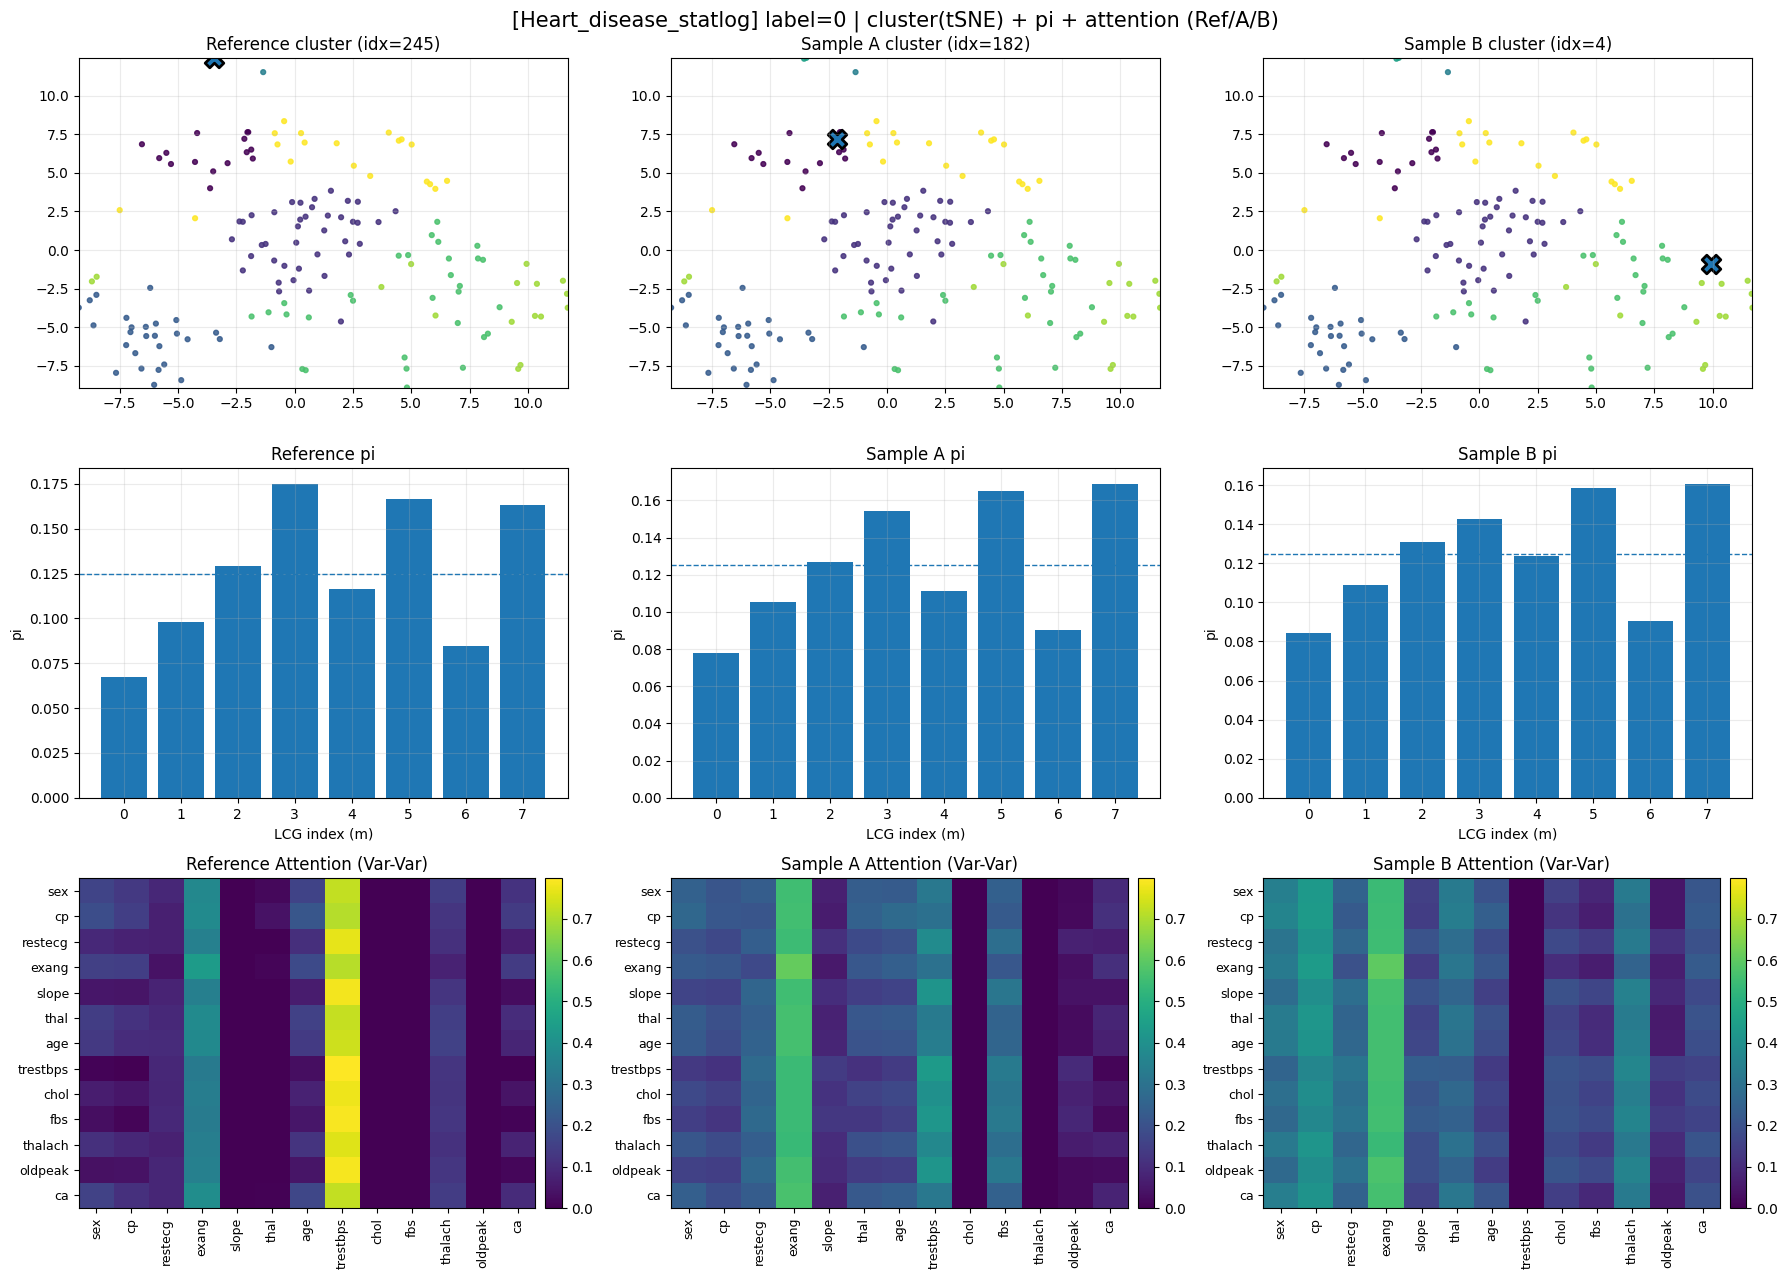

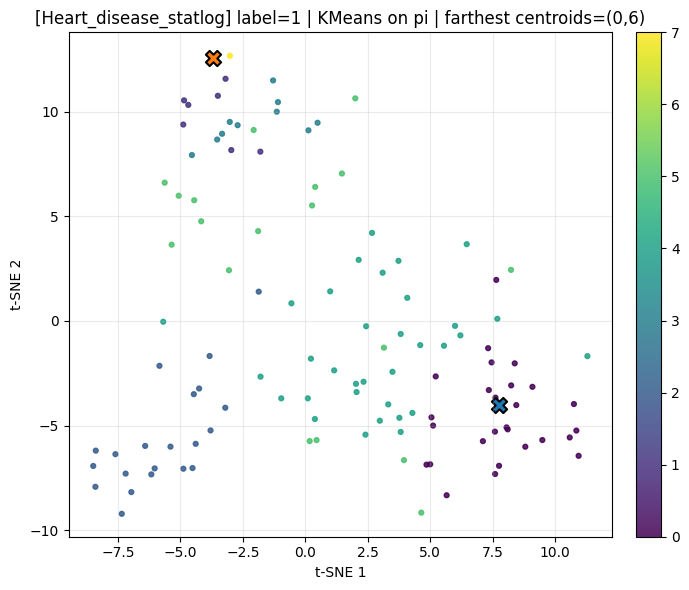

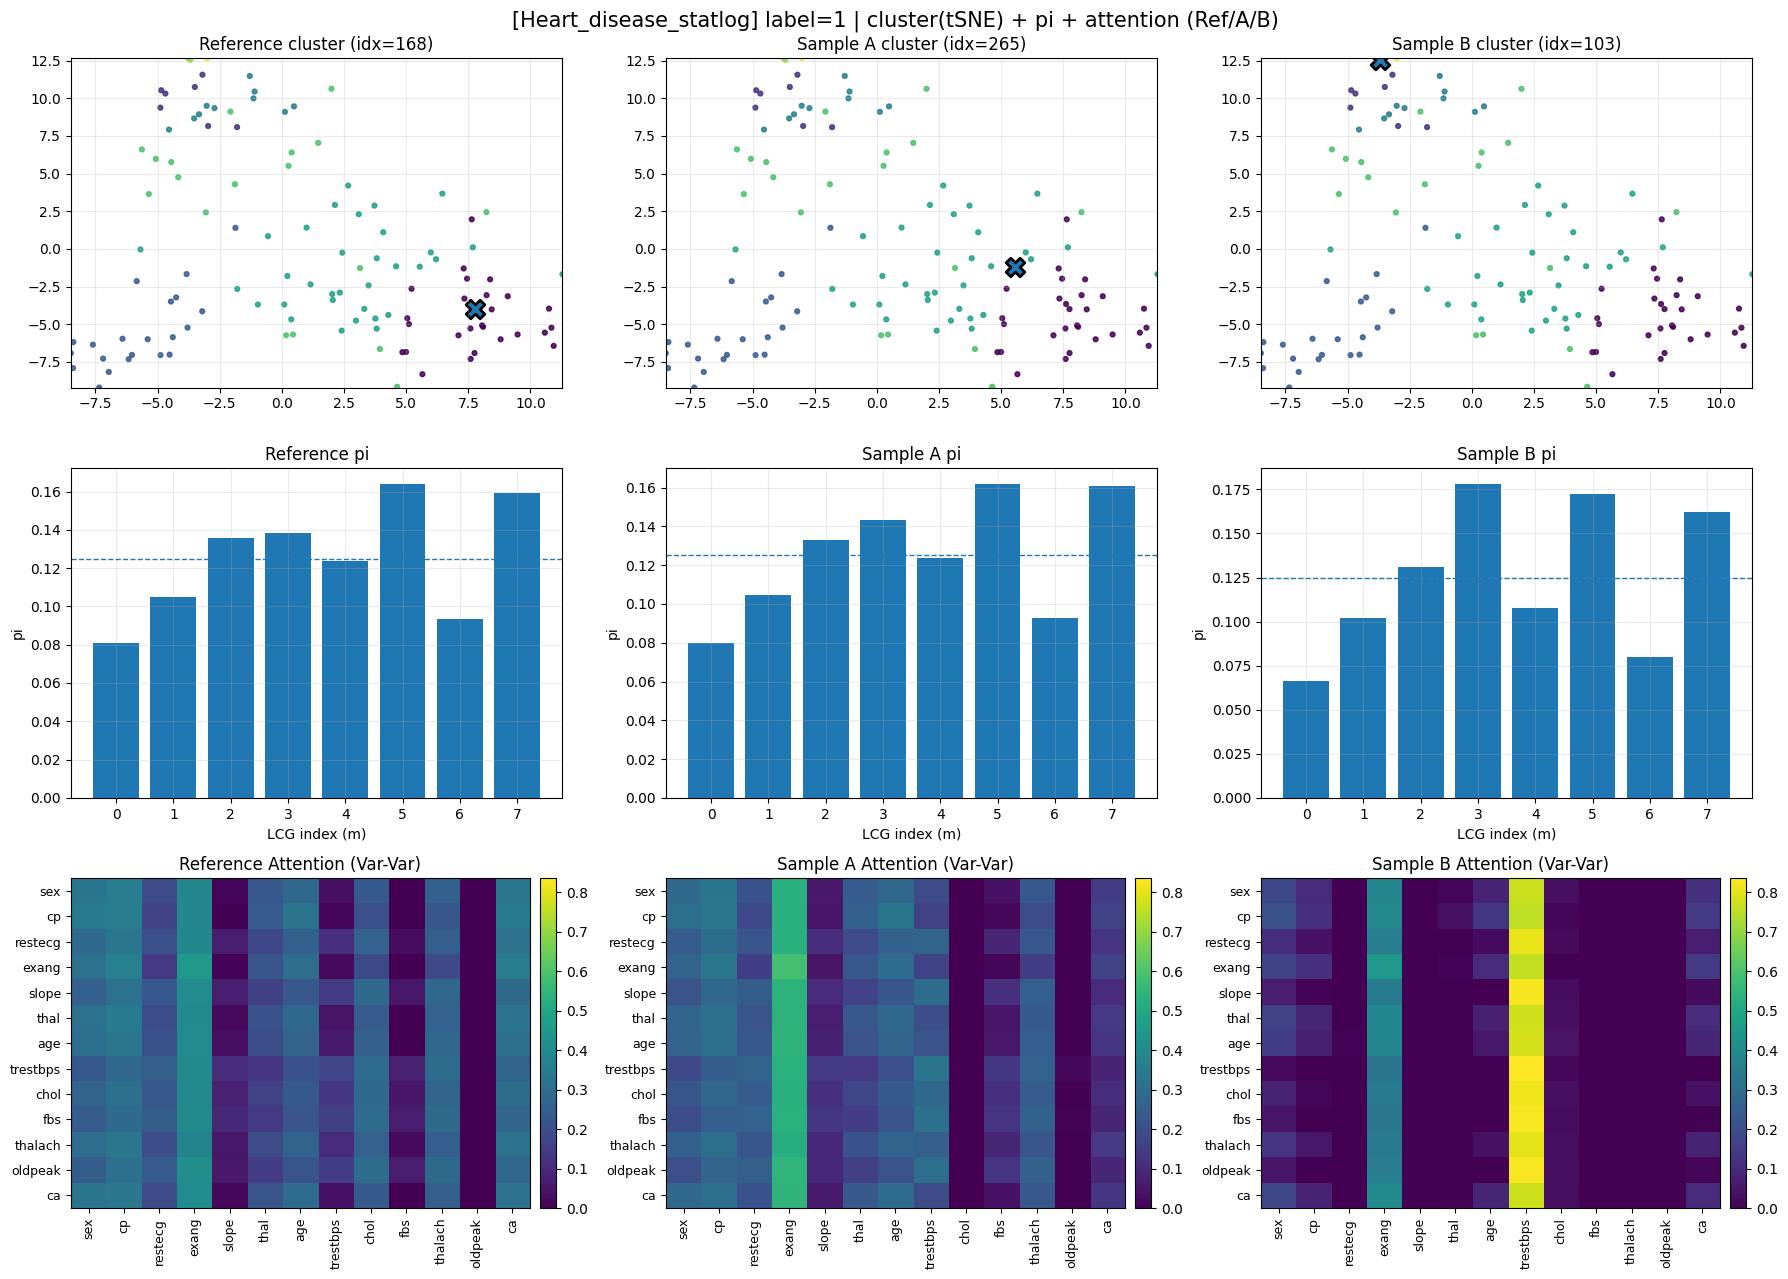

In [28]:

out = viz_source_pi_attn(model, loaders, device, source_key="heart", k=8, seed=42)

In [29]:
print(out["per_label"][0]["picked"]["ref_pi"])
print(out["per_label"][0]["picked"]["A_pi"])
print(out["per_label"][0]["picked"]["B_pi"])

[0.06760134 0.09776209 0.12937467 0.17498487 0.11616546 0.16642615
 0.08466356 0.16302183]
[0.07781466 0.10520033 0.12710468 0.1544233  0.11135959 0.16488731
 0.09033824 0.1688719 ]
[0.08447744 0.10890475 0.13113755 0.14256087 0.12374884 0.15828148
 0.09024322 0.16064581]


## Attention map based Clustering

In [30]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans

def _strip_cls_if_present(affs, names):
    affs2, names2 = [], []
    for A, nms in zip(affs, names):
        if (len(nms) == A.shape[0]) and (len(nms) > 0) and (str(nms[0]).upper() == "CLS"):
            affs2.append(A[1:, 1:])     # Var-Var only
            names2.append(nms[1:])      # Var names only
        else:
            affs2.append(A)
            names2.append(nms)
    return affs2, names2

def plot_tsne_att_by_label(att_vecs, ys, title_prefix="[heart]", seed=42):
    N = att_vecs.shape[0]
    perp = max(5, min(40, (N - 1) // 3))
    xy = TSNE(n_components=2, perplexity=perp, learning_rate=200, init="pca", random_state=seed).fit_transform(att_vecs)

    plt.figure(figsize=(7, 6))
    for lab in [0, 1]:
        m = (ys == lab)
        plt.scatter(xy[m, 0], xy[m, 1], s=12, alpha=0.85, label=f"y={lab} (n={m.sum()})")
    plt.title(f"{title_prefix} t-SNE(attention) colored by label")
    plt.xlabel("t-SNE 1"); plt.ylabel("t-SNE 2")
    plt.grid(True, alpha=0.25)
    plt.legend(frameon=True)
    plt.tight_layout()
    plt.show()
    return xy

def kmeans_on_attention_pick_result(att_vecs, ys, label, k=8, seed=42):
    idx = np.where(ys == label)[0]
    X = att_vecs[idx]  # [n_lab, D]
    k_eff = min(k, len(idx))
    km = KMeans(n_clusters=k_eff, random_state=seed, n_init=20)
    cid = km.fit_predict(X)

    return {
        "idx_lab": idx,
        "X_lab": X,
        "cid": cid,
        "km": km,
    }

def viz_source_attn_cluster_compare_with_given(
    model, loaders, device, source_key,
    picked_by_label,            # {lab: {"ref_global":.., "A_global":.., "B_global":..}}
    k=8, seed=42, labs=(0, 1)
):
    src_key, loader = get_loader_by_key(loaders, source_key)
    print("Using source:", src_key)

    pis, ys, affs, names = collect_pi_and_affinity_for_one_source(model, loader, device)

    # Var-Var only (no CLS)
    affs, names = _strip_cls_if_present(affs, names)

    # attention vectors (flatten Var-Var)
    att_vecs = np.stack([A.reshape(-1) for A in affs], axis=0)

    # t-SNE(attention) for visualization
    xy_all = plot_tsne_att_by_label(att_vecs, ys, title_prefix=f"[{src_key}]", seed=seed)

    per_label = {}
    for lab in labs:
        res_att = kmeans_on_attention_pick_result(att_vecs, ys, label=lab, k=k, seed=seed)

        idx_lab = res_att["idx_lab"]
        cid_lab = res_att["cid"]

        picked = picked_by_label[lab]
        ref_global = int(picked["ref_global"])
        A_global   = int(picked["A_global"])
        B_global   = int(picked["B_global"])

        # local indices within this label subset
        ref_local = int(np.where(idx_lab == ref_global)[0][0])
        A_local   = int(np.where(idx_lab == A_global)[0][0])
        B_local   = int(np.where(idx_lab == B_global)[0][0])

        # (간단 체크용) attention-cluster id 찍기
        print(f"\n[ATTN-KMeans] label={lab}")
        print(f"  ref: global={ref_global}, cluster={cid_lab[ref_local]}")
        print(f"  A  : global={A_global}, cluster={cid_lab[A_local]}")
        print(f"  B  : global={B_global}, cluster={cid_lab[B_local]}")

        # 3x3: (cluster on ATTENTION) + (pi = coordinate) + (attention map)
        plot_three_samples_cluster_pi_attention_3x3(
            xy_all=xy_all,
            res=res_att,          # ✅ attention 기반 KMeans 결과
            pis=pis,              # ✅ coordinate(pi)는 그대로
            affs=affs,            # ✅ Var-Var attention
            names=names,          # ✅ Var names
            ref_global=ref_global,
            A_global=A_global,
            B_global=B_global,
            ref_local=ref_local,
            A_local=A_local,
            B_local=B_local,
            title=f"[{src_key}] label={lab} | cluster(tSNE on ATTENTION) + pi + attention (given Ref/A/B)"
        )

        per_label[lab] = {"res_att": res_att, "picked_given": picked}

    return {
        "src_key": src_key,
        "pis": pis,
        "ys": ys,
        "affs": affs,
        "names": names,
        "att_vecs": att_vecs,
        "xy_all": xy_all,
        "per_label": per_label,
    }


Using source: Heart_disease_statlog


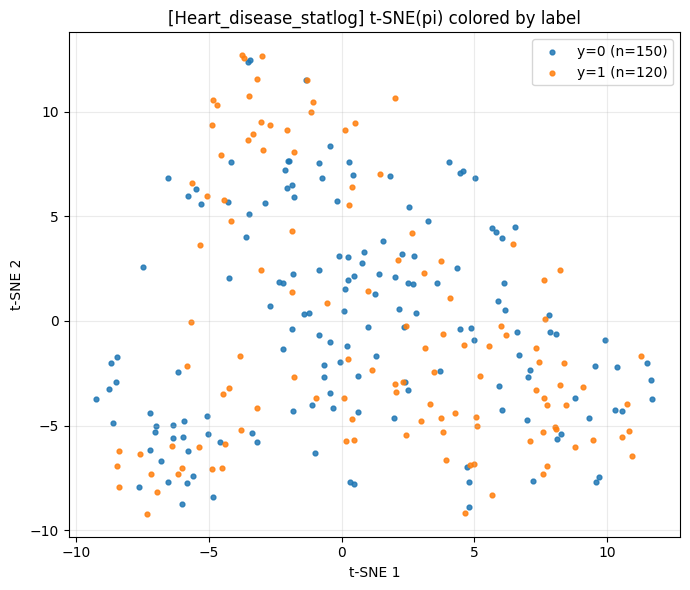

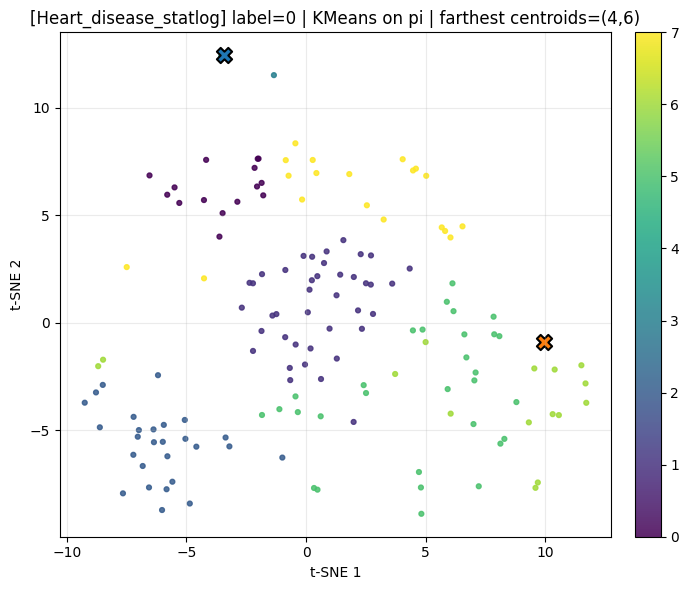

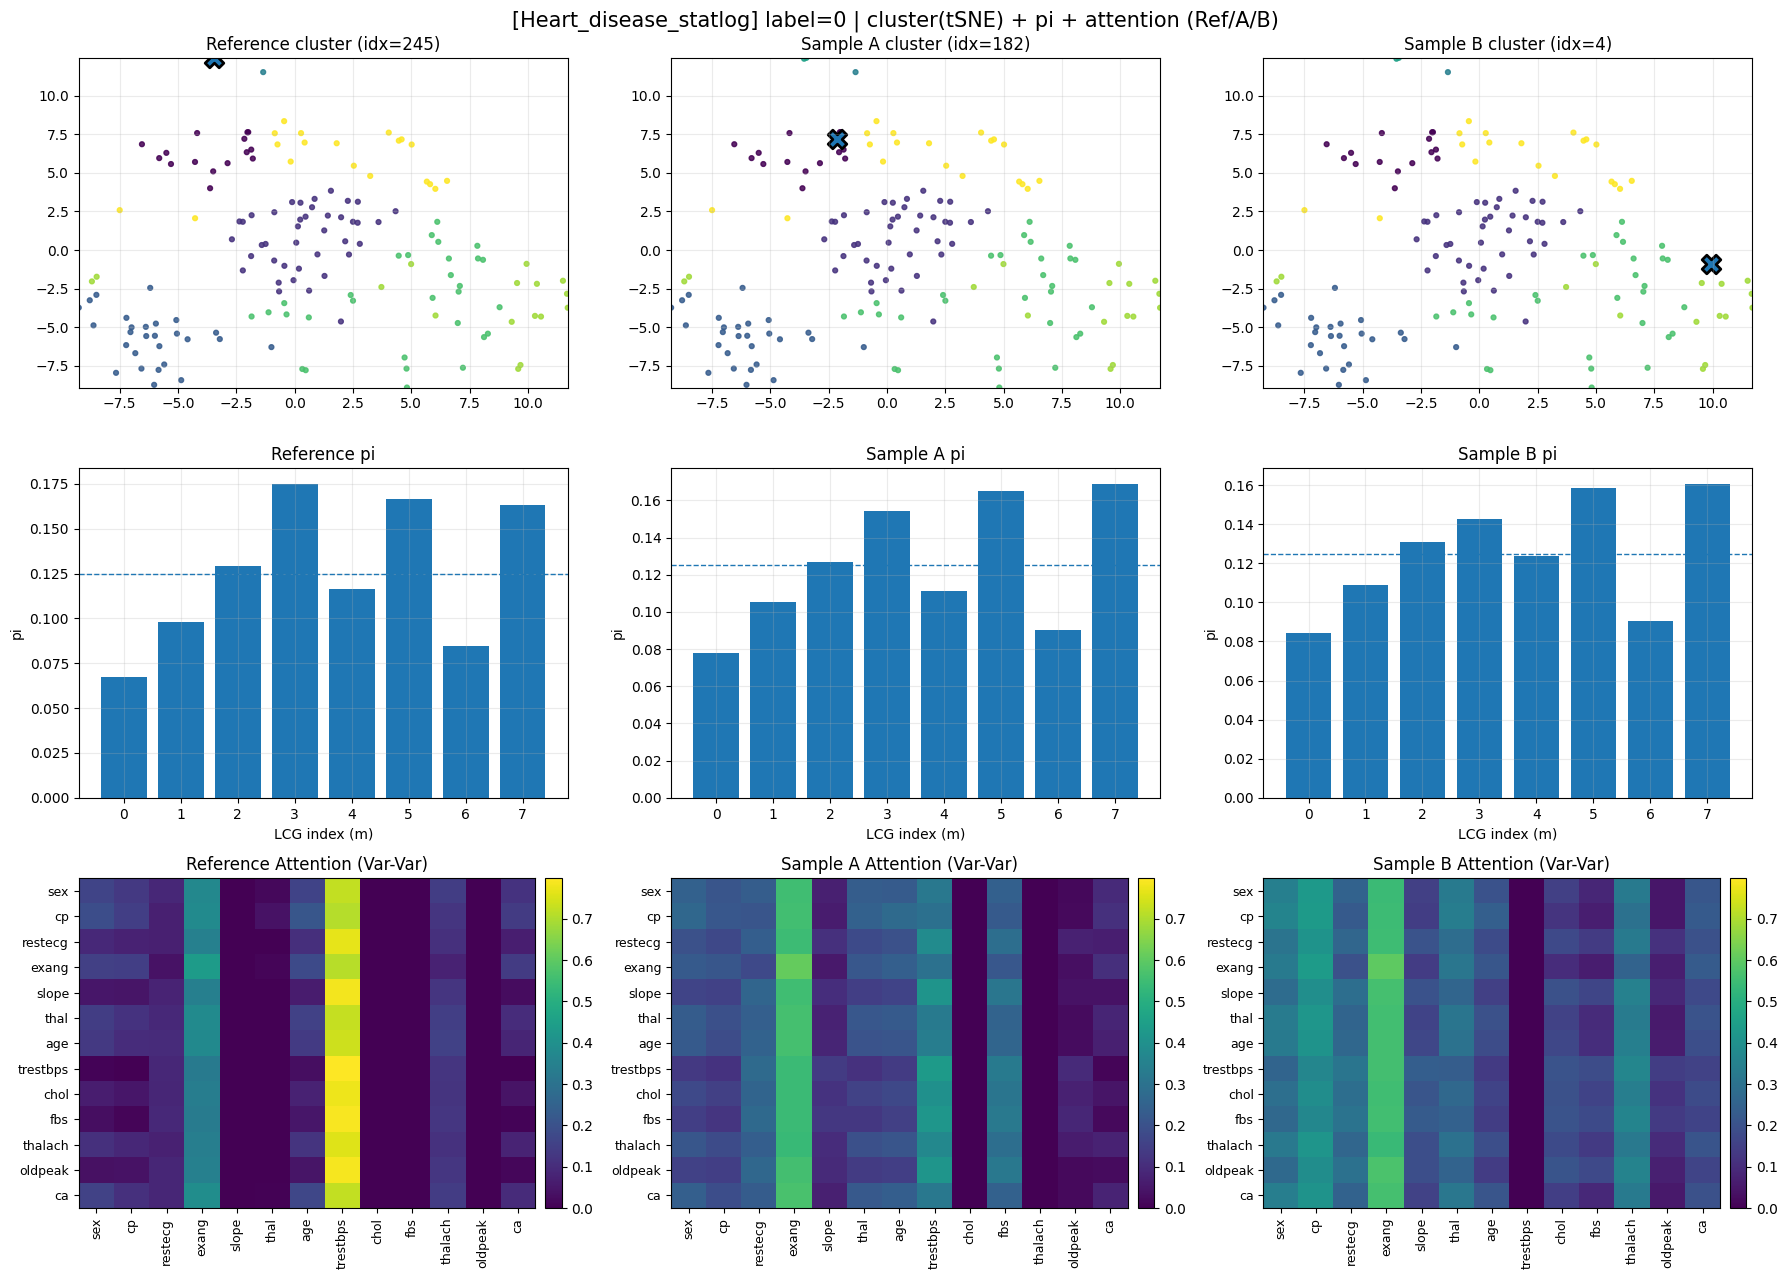

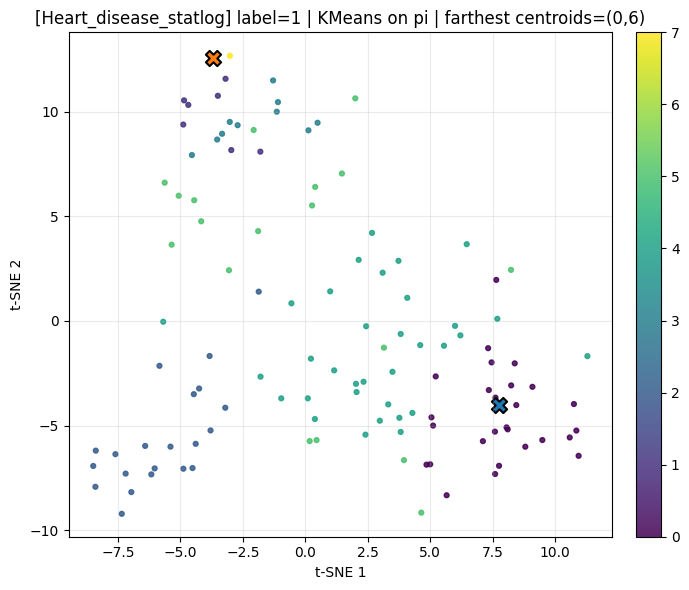

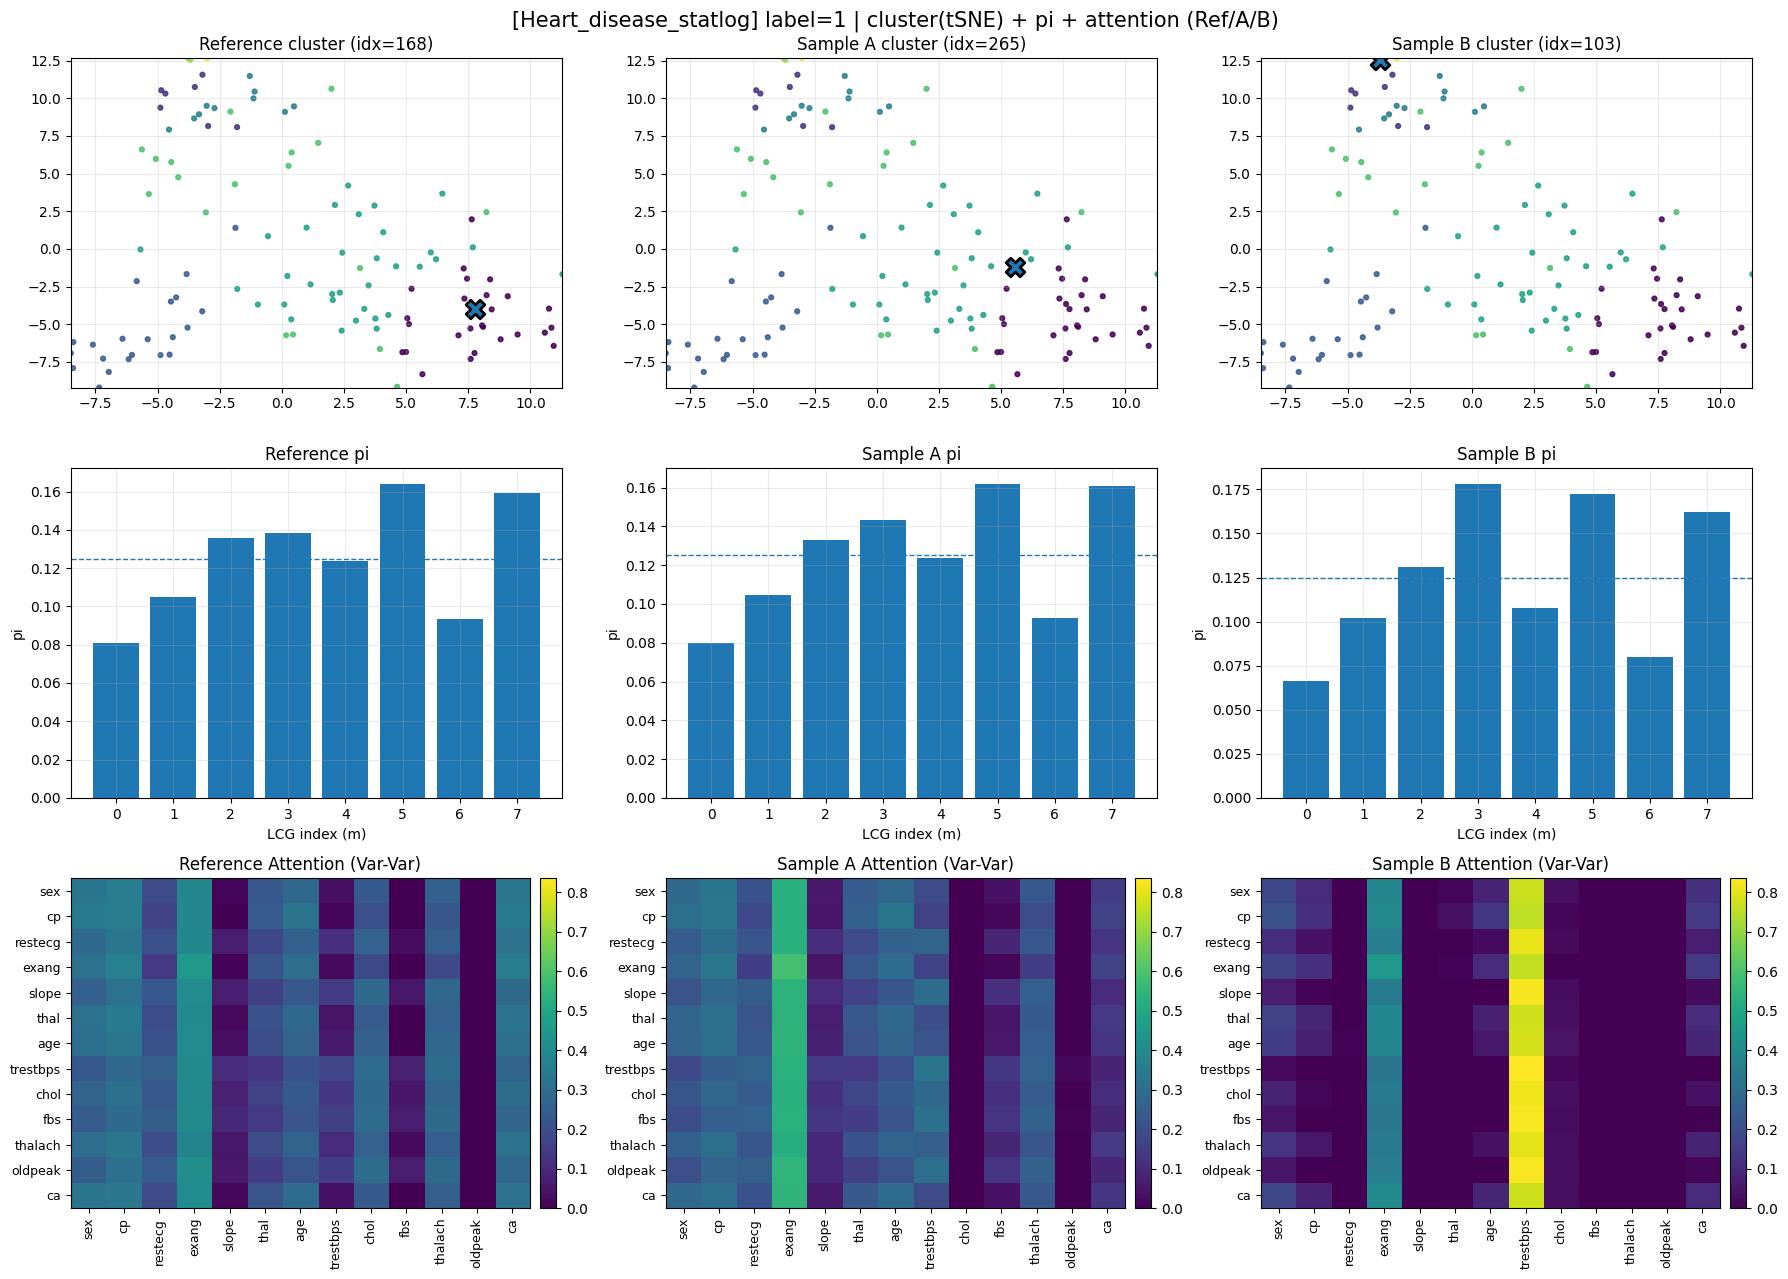

Using source: Heart_disease_statlog


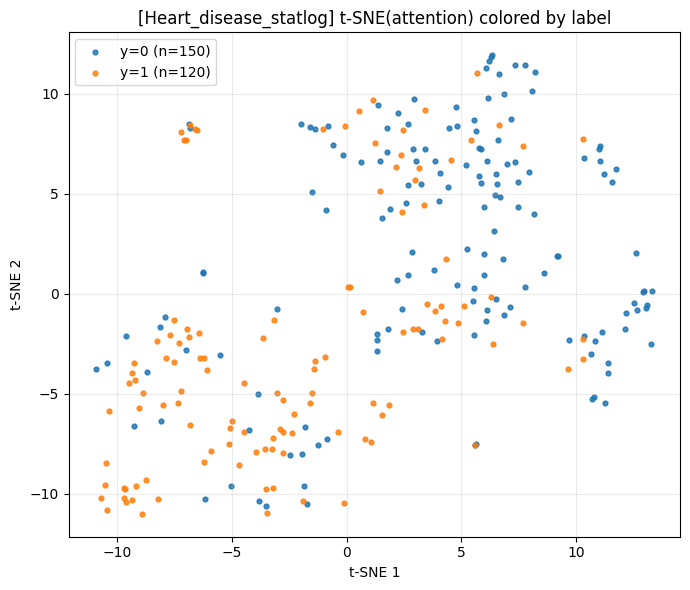


[ATTN-KMeans] label=0
  ref: global=245, cluster=4
  A  : global=182, cluster=1
  B  : global=4, cluster=0


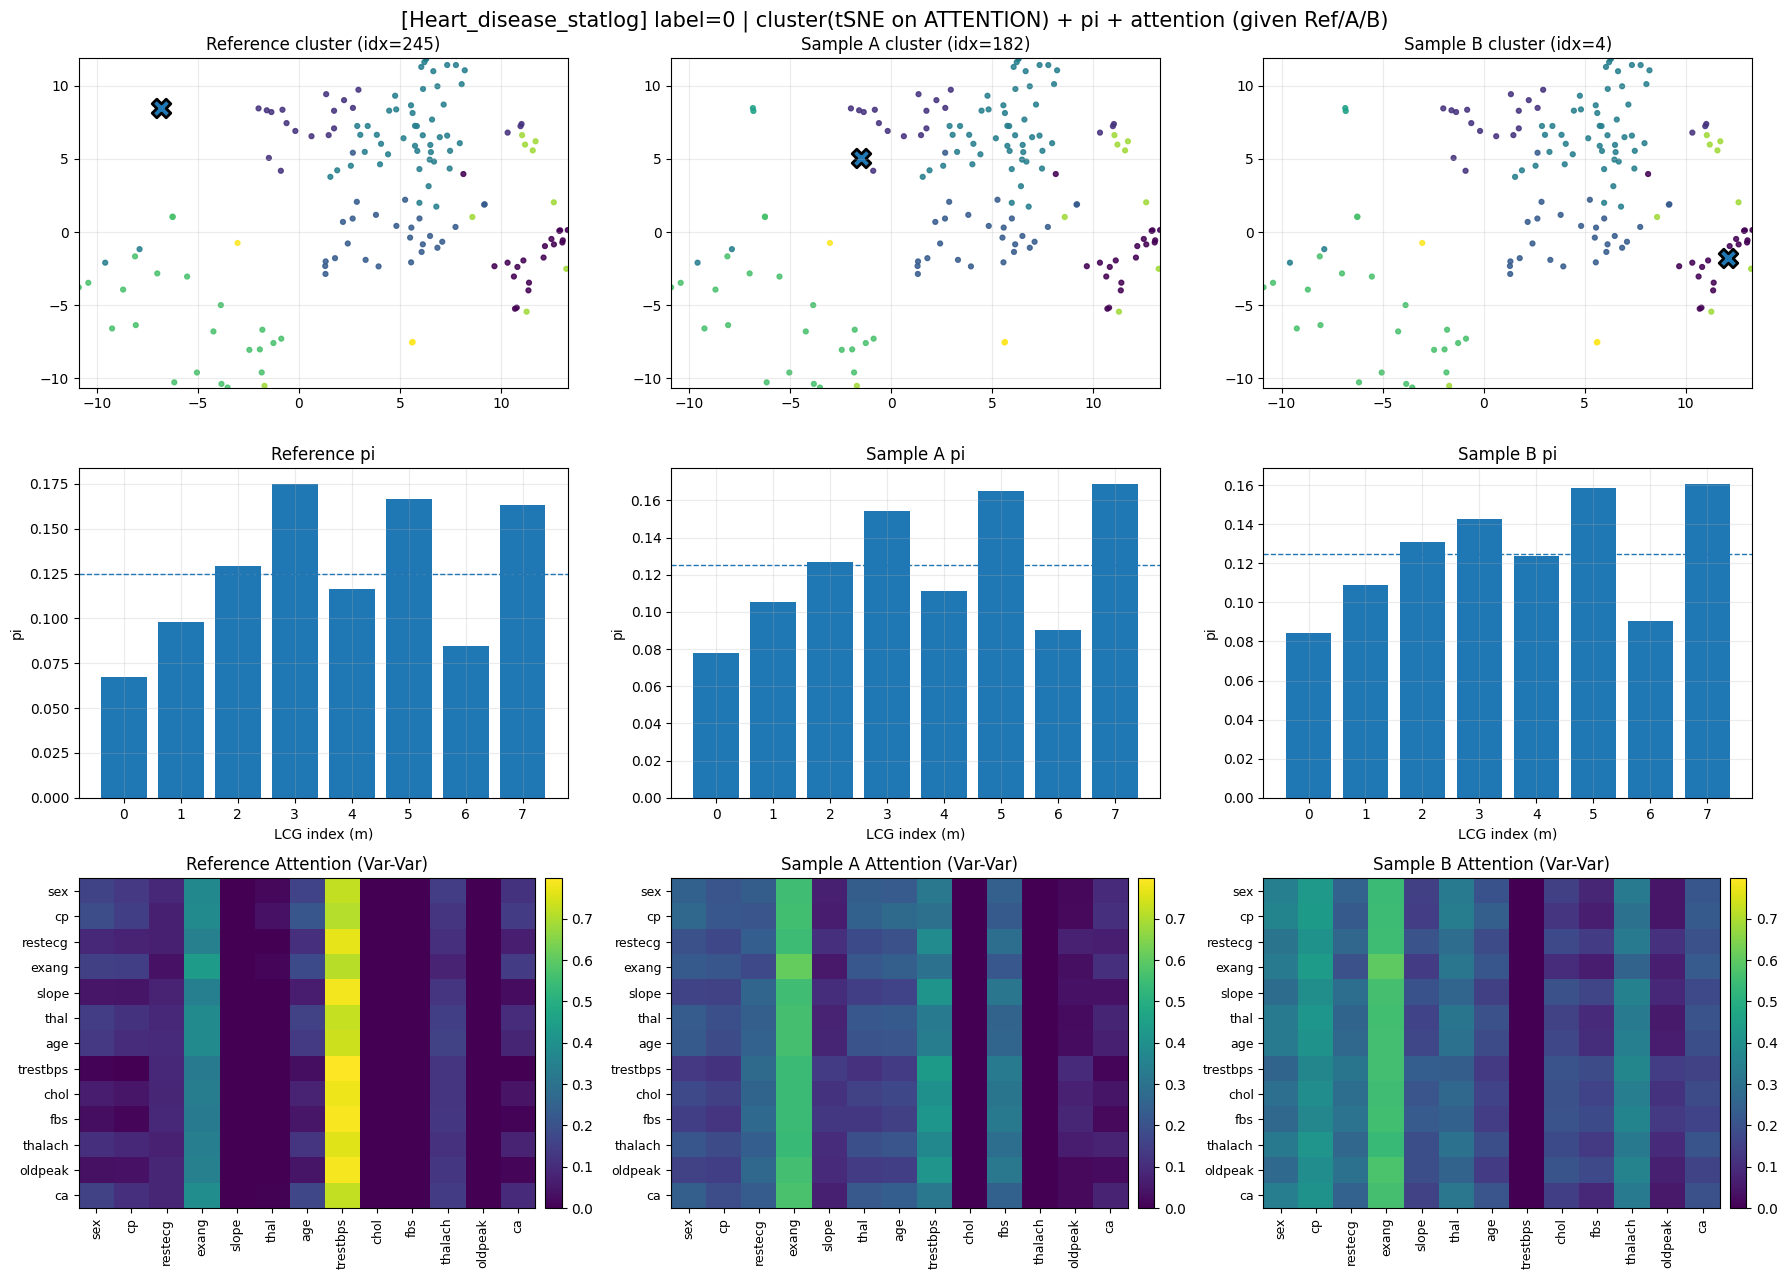


[ATTN-KMeans] label=1
  ref: global=168, cluster=0
  A  : global=265, cluster=4
  B  : global=103, cluster=3


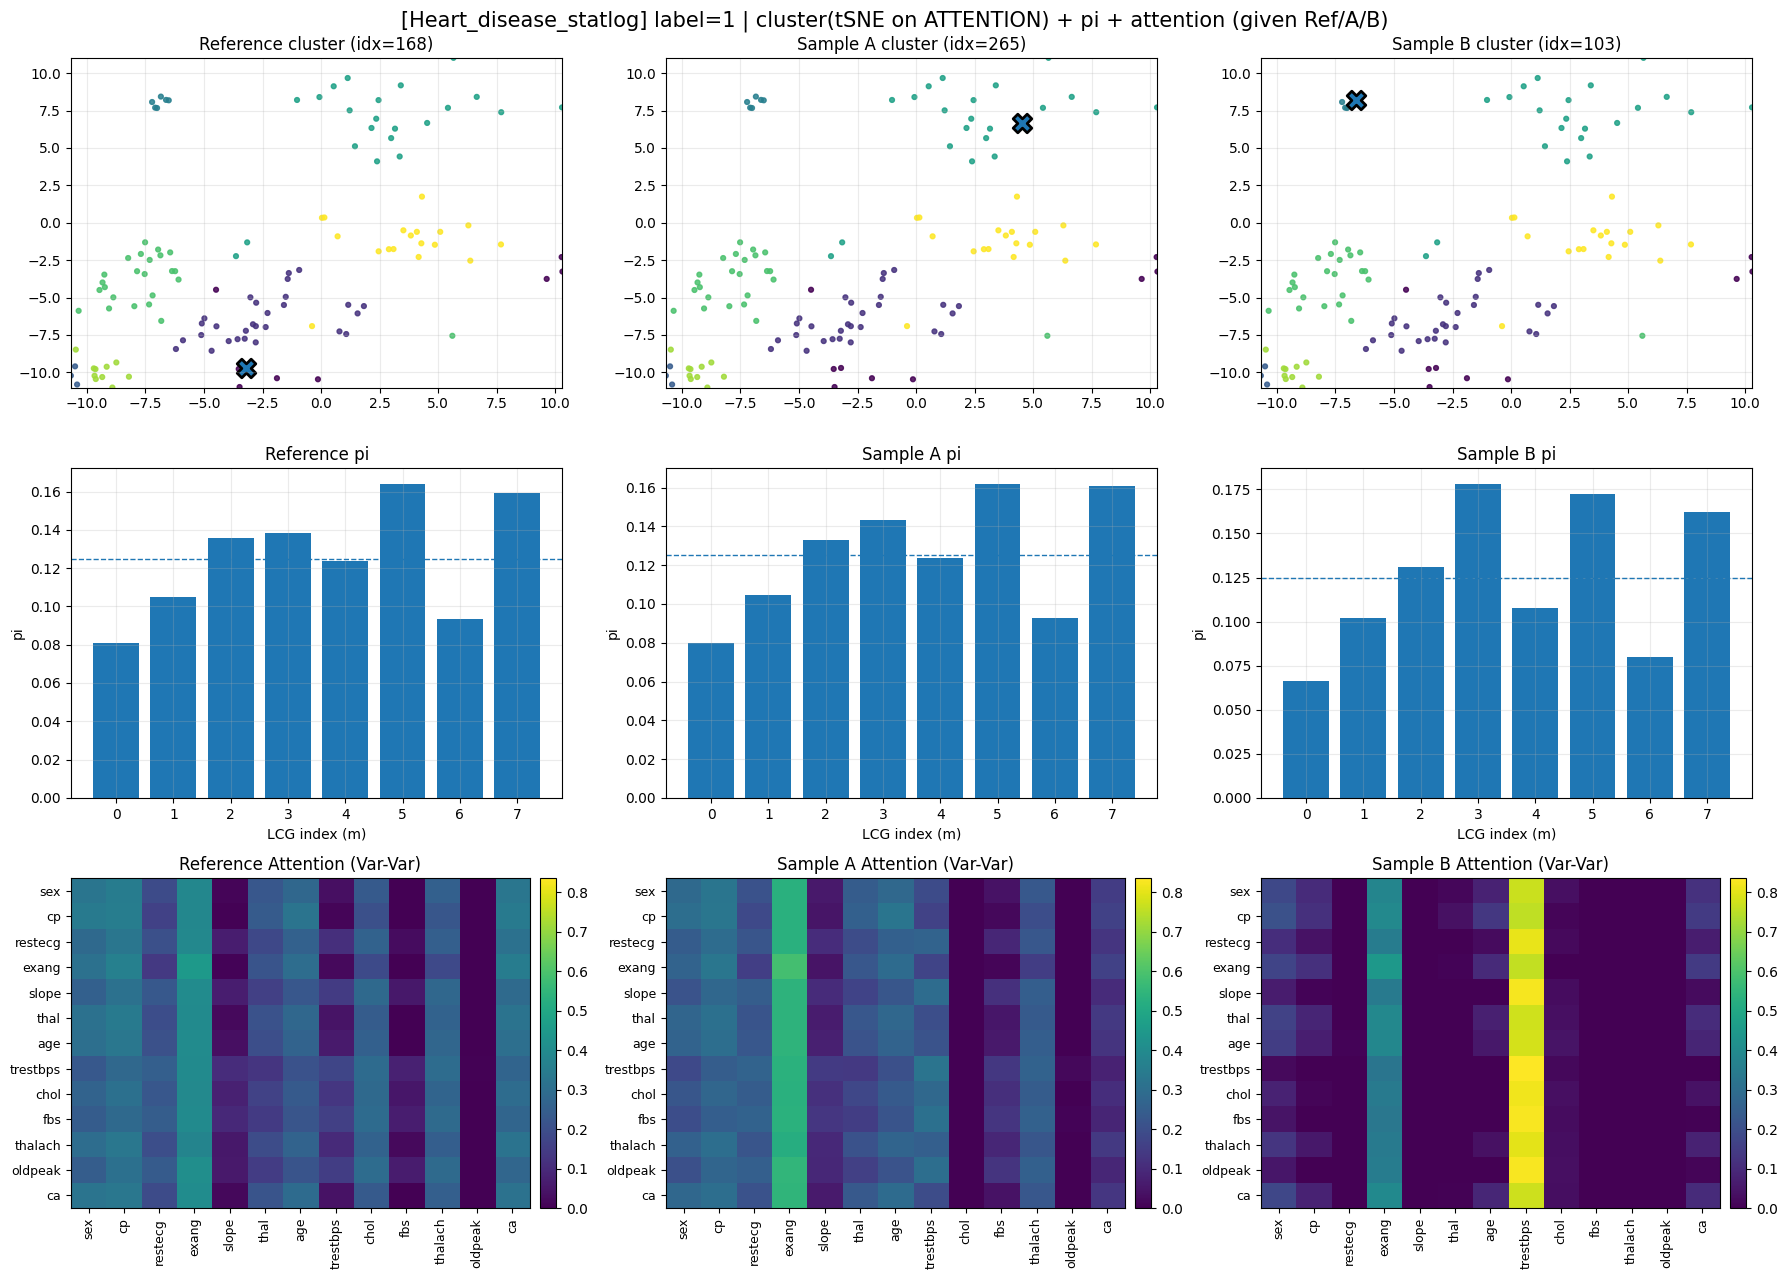

In [31]:
out_pi = viz_source_pi_attn(model, loaders, device, source_key="heart", k=8, seed=42, labs=(0,1))
picked_by_label = {lab: out_pi["per_label"][lab]["picked"] for lab in (0,1)}

out_att = viz_source_attn_cluster_compare_with_given(
    model, loaders, device,
    source_key="heart",
    picked_by_label=picked_by_label,
    k=8, seed=42, labs=(0,1)
)


## C2A, A2C가 서로 관련이 있는가?
- 우리의 Attention map은 Source마다 다 다르지만, coordinate는 모두 동일한 Space에서 살펴볼 수 있음. 

=== Group sizes by pi argmax ===
LCG 0: 0 samples
LCG 1: 0 samples
LCG 2: 0 samples
LCG 3: 5 samples
LCG 4: 0 samples
LCG 5: 108 samples
LCG 6: 0 samples
LCG 7: 157 samples

=== Attention range: [0.000, 1.000] ===


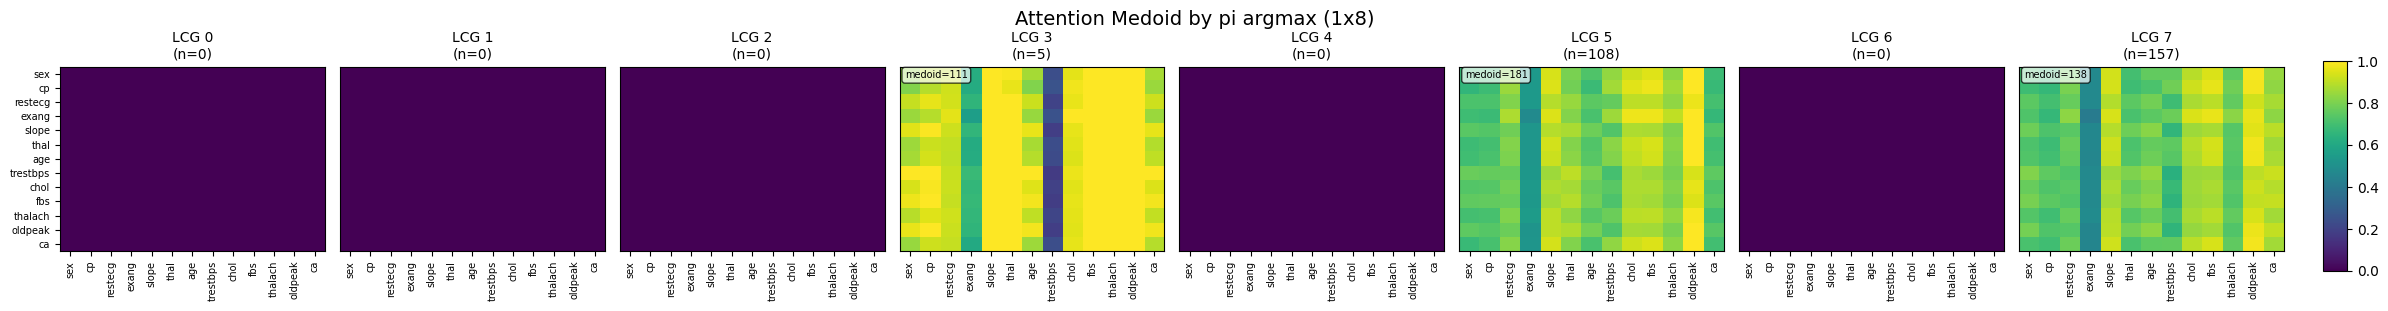

In [32]:
def plot_attention_medoid_by_pi_argmax(pis, affs, names, figsize=(24, 3)):
    """
    각 샘플의 pi argmax 인덱스로 그룹화 후, 
    각 그룹의 Attention map medoid를 1x8 subplot으로 시각화
    
    Args:
        pis: (N, 8) coordinate vectors
        affs: list of (Nvar, Nvar) affinity matrices
        names: list of variable names per sample
    """
    pis_np = np.array(pis)
    N = len(affs)
    M = 8
    
    # 1) pi argmax로 그룹화
    argmax_idx = np.argmax(pis_np, axis=1)
    groups = {i: [] for i in range(M)}
    
    for n in range(N):
        lcg_id = argmax_idx[n]
        groups[lcg_id].append(n)
    
    print("=== Group sizes by pi argmax ===")
    for i in range(M):
        print(f"LCG {i}: {len(groups[i])} samples")
    
    # 2) 각 그룹의 medoid 찾기
    medoid_atts = []
    medoid_indices = []
    
    for i in range(M):
        group_idxs = groups[i]
        
        if len(group_idxs) == 0:
            medoid_atts.append(np.zeros_like(affs[0]))
            medoid_indices.append(None)
            continue
        
        if len(group_idxs) == 1:
            # ✅ Attention = 1 - affinity
            medoid_atts.append(1.0 - affs[group_idxs[0]])
            medoid_indices.append(group_idxs[0])
            continue
        
        # medoid: 그룹 내 다른 샘플과의 Frobenius distance 합 최소
        min_dist_sum = float('inf')
        medoid_idx = group_idxs[0]
        
        for idx in group_idxs:
            A = affs[idx]
            dist_sum = sum(np.linalg.norm(A - affs[other_idx], 'fro') 
                          for other_idx in group_idxs if other_idx != idx)
            
            if dist_sum < min_dist_sum:
                min_dist_sum = dist_sum
                medoid_idx = idx
        
        # ✅ Attention = 1 - affinity
        medoid_atts.append(1.0 - affs[medoid_idx])
        medoid_indices.append(medoid_idx)
    
    # 3) colorbar 범위 (Attention 기준)
    vmin = min(A.min() for A in medoid_atts if A.size > 0)
    vmax = max(A.max() for A in medoid_atts if A.size > 0)
    
    print(f"\n=== Attention range: [{vmin:.3f}, {vmax:.3f}] ===")
    
    # 4) 1x8 subplot
    fig, axes = plt.subplots(1, M, figsize=figsize)
    
    var_names = names[0] if len(names) > 0 else None
    nvar = medoid_atts[0].shape[0]
    
    if nvar <= 20:
        fs = 7
    elif nvar <= 40:
        fs = 5
    else:
        fs = 3
    
    for i in range(M):
        ax = axes[i]
        A = medoid_atts[i]  # ✅ 이미 Attention
        
        im = ax.imshow(A, cmap='viridis', vmin=vmin, vmax=vmax, 
                      interpolation='nearest', aspect='auto')
        
        ax.set_title(f"LCG {i}\n(n={len(groups[i])})", fontsize=10)
        
        if var_names is not None:
            if i == 0:
                ax.set_yticks(range(nvar))
                ax.set_yticklabels(var_names, fontsize=fs)
            else:
                ax.set_yticks([])
            
            ax.set_xticks(range(nvar))
            ax.set_xticklabels(var_names, rotation=90, fontsize=fs)
        
        if medoid_indices[i] is not None:
            ax.text(0.02, 0.98, f"medoid={medoid_indices[i]}", 
                   transform=ax.transAxes, ha='left', va='top',
                   fontsize=7, bbox=dict(boxstyle='round,pad=0.3', 
                                        facecolor='white', alpha=0.7))
    
    plt.tight_layout(rect=[0, 0, 0.96, 1])
    
    cax = fig.add_axes([0.97, 0.15, 0.01, 0.7])
    fig.colorbar(im, cax=cax)
    
    plt.suptitle("Attention Medoid by pi argmax (1x8)", 
                fontsize=14, y=1.02)
    plt.show()
    
    return {
        "groups": groups,
        "medoid_indices": medoid_indices,
        "medoid_atts": medoid_atts
    }

# 사용
result = plot_attention_medoid_by_pi_argmax(
    pis=out_pi["pis"],
    affs=out_pi["affs"],
    names=out_pi["names"]
)

In [33]:
import numpy as np
import matplotlib.pyplot as plt

def _to_varvar(A, node_names=None):
    """
    A: [N,N] attention
    node_names: 길이 N 라벨일 수도 있음. 첫 토큰이 CLS면 CLS 제거.
    """
    if node_names is not None and len(node_names) == A.shape[0]:
        if isinstance(node_names[0], str) and node_names[0].strip().upper() == "CLS":
            # CLS row/col drop
            return A[1:, 1:], node_names[1:]
    return A, node_names

def pi_attention_alignment_single_source(pis, affs, names=None, M=8, seed=0, show_means=True):
    """
    pis: [S, M] (coordinate/pi)
    affs: list length S, each [N,N] attention (Var-Var or CLS 포함 가능)
    names: list length S, each list of token names (옵션)
    M: LCG 개수
    """

    S = pis.shape[0]
    assert S == len(affs), "pis와 affs 샘플 수가 달라요"

    # 0) 각 샘플의 Top-1 LCG 할당
    j_star = np.argmax(pis, axis=1)  # [S]

    # 1) Var-Var attention으로 통일 + (혹시 샘플마다 N 다르면 minN으로 자름)
    A_list = []
    name0 = None
    Ns = []
    for i in range(S):
        node_names = names[i] if names is not None else None
        A, nn = _to_varvar(np.asarray(affs[i]), node_names)
        A_list.append(A)
        Ns.append(A.shape[0])
        if name0 is None:
            name0 = nn

    Nmin = int(min(Ns))
    if any(n != Nmin for n in Ns):
        # 한 source에서 보통 N 고정이지만, 혹시 다르면 공통 minN으로 자름(간단 처리)
        A_list = [A[:Nmin, :Nmin] for A in A_list]
        if name0 is not None:
            name0 = name0[:Nmin]

    A_stack = np.stack(A_list, axis=0)  # [S, N, N]

    # 2) 그룹별 평균 attention (Abar_j)
    group_idxs = {j: np.where(j_star == j)[0] for j in range(M)}
    Abar = {}
    for j in range(M):
        idxs = group_idxs[j]
        if len(idxs) == 0:
            continue
        Abar[j] = A_stack[idxs].mean(axis=0)

    # 3) 거리 계산: ||A_i - Abar_group|| (Frobenius)
    def frob(X, Y):
        D = X - Y
        return float(np.sqrt(np.sum(D * D)))

    intra = []  # same group
    inter = []  # other group (min over others)
    loo_intra = []  # leave-one-out intra (자기 샘플 빼고 평균)
    ok_loo = []      # LOO 거리 < 다른 그룹 최소거리 ?

    # 미리 다른 그룹 평균 리스트 만들어두기
    Abar_keys = sorted(list(Abar.keys()))

    for i in range(S):
        gi = int(j_star[i])
        Ai = A_stack[i]

        # other groups min dist
        other_dists = []
        for j in Abar_keys:
            if j == gi:
                continue
            other_dists.append(frob(Ai, Abar[j]))
        d_other_min = float(min(other_dists)) if len(other_dists) > 0 else np.nan
        inter.append(d_other_min)

        # intra dist (그룹 평균 포함 버전)
        d_intra = frob(Ai, Abar[gi])
        intra.append(d_intra)

        # LOO intra: 그룹 내 샘플이 2개 이상일 때만 의미 있음
        idxs = group_idxs[gi]
        if len(idxs) >= 2:
            # leave-one-out mean
            others = idxs[idxs != i]
            Abar_loo = A_stack[others].mean(axis=0)
            d_loo = frob(Ai, Abar_loo)
            loo_intra.append(d_loo)
            ok_loo.append(d_loo < d_other_min)
        # len(idxs)==1 이면 skip (loo_intra에 넣지 않음)

    intra = np.array(intra, dtype=float)
    inter = np.array(inter, dtype=float)
    loo_intra = np.array(loo_intra, dtype=float)

    # 4) 요약 출력
    print("=== pi(top1) -> attention 정렬(연관) 체크 ===")
    print(f"#samples: {S}, #LCG(M): {M}, Var-Var N(min): {Nmin}")
    print("group counts:", {j: int(len(group_idxs[j])) for j in range(M)})

    print("\n[Distance summary]  (Frobenius)")
    print(f"intra  mean={np.nanmean(intra):.4f}  std={np.nanstd(intra):.4f}")
    print(f"inter  mean={np.nanmean(inter):.4f}  std={np.nanstd(inter):.4f}")
    print(f"gap(inter-intra)={np.nanmean(inter)-np.nanmean(intra):.4f}  | ratio(inter/intra)={np.nanmean(inter)/max(1e-12,np.nanmean(intra)):.3f}")

    if len(loo_intra) > 0:
        acc_loo = float(np.mean(ok_loo))
        print("\n[Leave-one-out check]")
        print(f"LOO-intra mean={loo_intra.mean():.4f}  (n={len(loo_intra)})")
        print(f"fraction(LOO-intra < nearest-other) = {acc_loo:.3f}")
    else:
        print("\n[Leave-one-out check] 그룹 크기 때문에 계산 불가(각 그룹이 1개뿐일 수 있음).")

    # 5) 간단 플롯: intra vs inter
    plt.figure(figsize=(6,4))
    plt.boxplot([intra[~np.isnan(intra)], inter[~np.isnan(inter)]], labels=["intra (same j*)", "inter (min other)"])
    plt.title("Distance(A_i, group-mean attention)")
    plt.ylabel("Frobenius distance")
    plt.grid(True, alpha=0.25)
    plt.tight_layout()
    plt.show()

    # 6) (옵션) 그룹 평균 attention 시각화
    # 6) (옵션) 그룹 평균 attention 시각화  --- FIXED: 항상 M개 + colorbar 분리
    if show_means:
        ncol = 4
        nrow = int(np.ceil(M / ncol))

        # vmin/vmax: 실제 존재하는 그룹(Abar)에 대해서만 계산
        if len(Abar) > 0:
            vmin = min(Abar[j].min() for j in Abar.keys())
            vmax = max(Abar[j].max() for j in Abar.keys())
        else:
            vmin, vmax = 0.0, 1.0

        fig = plt.figure(figsize=(3.2 * ncol + 0.8, 3.0 * nrow))
        gs = fig.add_gridspec(
            nrow, ncol + 1,
            width_ratios=[1] * ncol + [0.06],  # 마지막 열: colorbar
            wspace=0.25, hspace=0.35
        )

        last_im = None

        # ✅ 항상 j=0..M-1 전부 그리기 (샘플 0개면 빈(0) 맵)
        for j in range(M):
            r, c = divmod(j, ncol)
            ax = fig.add_subplot(gs[r, c])

            if j in Abar:
                mat = Abar[j]
                n_j = int(len(group_idxs[j]))
            else:
                mat = np.zeros((Nmin, Nmin), dtype=float)  # 샘플 0개면 0으로 채움
                n_j = 0

            last_im = ax.imshow(
                mat, vmin=vmin, vmax=vmax,
                aspect="auto", interpolation="nearest",
                cmap="viridis"
            )
            ax.set_title(f"Mean Attention | j*={j} (n={n_j})", fontsize=10)

            if name0 is not None and Nmin <= 30:
                ax.set_xticks(range(Nmin))
                ax.set_yticks(range(Nmin))
                ax.set_xticklabels(name0, rotation=90, fontsize=7)
                ax.set_yticklabels(name0, fontsize=7)
            else:
                ax.set_xticks([])
                ax.set_yticks([])

        # 남는 칸 끄기 (M이 8이 아니거나 ncol 나눠떨어지지 않을 때 대비)
        for j in range(M, nrow * ncol):
            r, c = divmod(j, ncol)
            ax = fig.add_subplot(gs[r, c])
            ax.axis("off")

        # ✅ colorbar 전용 축: 절대 겹치지 않음
        cax = fig.add_subplot(gs[:, -1])
        fig.colorbar(last_im, cax=cax)

        fig.suptitle("Group-mean attention maps by top1(pi)", y=0.99, fontsize=13)
        plt.show()


    return {
        "j_star": j_star,
        "group_idxs": group_idxs,
        "Abar": Abar,
        "intra": intra,
        "inter": inter,
        "loo_intra": loo_intra,
        "loo_ok": np.array(ok_loo, dtype=bool),
        "Nmin": Nmin,
        "name0": name0,
    }


=== pi(top1) -> attention 정렬(연관) 체크 ===
#samples: 270, #LCG(M): 8, Var-Var N(min): 13
group counts: {0: 0, 1: 0, 2: 0, 3: 5, 4: 0, 5: 108, 6: 0, 7: 157}

[Distance summary]  (Frobenius)
intra  mean=1.0017  std=0.4847
inter  mean=1.0923  std=0.4552
gap(inter-intra)=0.0906  | ratio(inter/intra)=1.090

[Leave-one-out check]
LOO-intra mean=1.0154  (n=270)
fraction(LOO-intra < nearest-other) = 0.700


/tmp/ipykernel_837475/368437393.py:124: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([intra[~np.isnan(intra)], inter[~np.isnan(inter)]], labels=["intra (same j*)", "inter (min other)"])


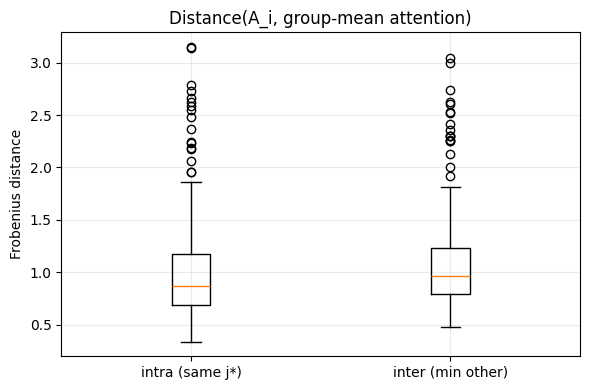

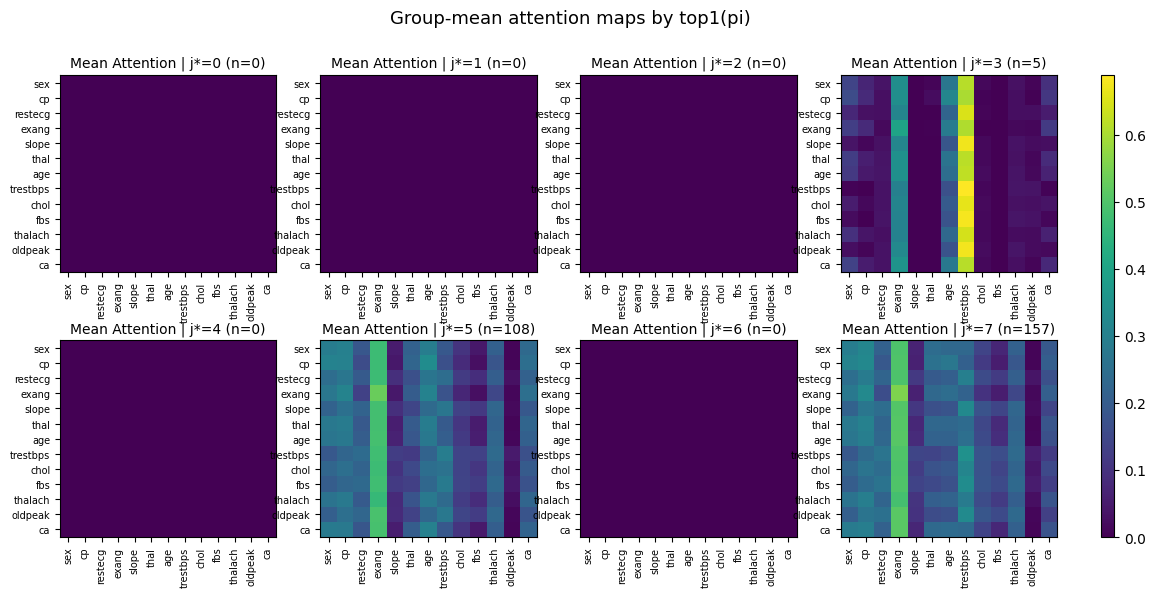

In [34]:
# 이미 이거 있지?
# pis, ys, affs, names = collect_pi_and_affinity_for_one_source(model, loader, device)

out_align = pi_attention_alignment_single_source(
    pis=pis,
    affs=affs,
    names=names,
    M=pis.shape[1],   # 보통 8
    show_means=True
)


## Qualitative Analysis - Coordinate-to-Attention_map clustering

In [35]:
@torch.no_grad()
def collect_pi_y_phat(model, loader, device):
    model.eval()
    pis, ys, phats = [], [], []

    def _find_tensor(obj):
        """obj 안에서 [B], [B,1], [B,2] 같은 prediction 후보 tensor를 찾아서 반환"""
        # tensor
        if torch.is_tensor(obj):
            return obj
        # numpy
        if isinstance(obj, np.ndarray):
            return torch.from_numpy(obj)
        # dict: 먼저 흔한 키들 우선
        if isinstance(obj, dict):
            for k in ["prob", "probs", "p", "pred_prob", "y_prob", "logit", "logits", "y_logit", "pred", "preds", "y_pred"]:
                if k in obj and obj[k] is not None:
                    t = _find_tensor(obj[k])
                    if t is not None:
                        return t
            # 그래도 없으면 값들 중 tensor 찾아보기
            for v in obj.values():
                t = _find_tensor(v)
                if t is not None:
                    return t
            return None
        # tuple/list: 안을 훑어서 tensor 찾아보기
        if isinstance(obj, (list, tuple)):
            for v in obj:
                t = _find_tensor(v)
                if t is not None:
                    return t
            return None
        # 그 외는 실패
        return None

    def to_prob(out):
        """
        out: model.predict 반환값 (dict/tensor/tuple/list/np.ndarray...)
        return: p_hat in [0,1], shape [B]
        """
        t = _find_tensor(out)
        if t is None:
            raise RuntimeError(f"predict output에서 tensor를 못 찾음. type(out)={type(out)}")

        t = t.detach()
        # [B,2]면 binary class logits/prob로 해석
        if t.ndim == 2 and t.shape[1] == 2:
            # 이미 probability면(0~1이고 row sum ~1) 그대로
            if (t.min() >= 0.0) and (t.max() <= 1.0):
                row_sum = t.sum(dim=1)
                if torch.allclose(row_sum, torch.ones_like(row_sum), atol=1e-2, rtol=1e-2):
                    p = t[:, 1]
                else:
                    p = torch.softmax(t.float(), dim=1)[:, 1]
            else:
                p = torch.softmax(t.float(), dim=1)[:, 1]
            return torch.clamp(p.float(), 0.0, 1.0)

        # [B,1] -> [B]
        if t.ndim == 2 and t.shape[1] == 1:
            t = t[:, 0]

        # [B] 형태: 값 범위가 0~1이면 prob로 보고, 아니면 logit로 보고 sigmoid
        if t.ndim == 1:
            if (t.min() >= 0.0) and (t.max() <= 1.0):
                return torch.clamp(t.float(), 0.0, 1.0)
            else:
                return torch.clamp(torch.sigmoid(t.float()), 0.0, 1.0)

        raise RuntimeError(f"예상 못한 pred tensor shape={tuple(t.shape)}")

    for batch in loader:
        batch_t = {k: (v.to(device) if torch.is_tensor(v) else v) for k, v in batch.items()}

        out = model.predict(batch_t, return_all=True)

        pi = model.graph_quantizer.last_pi  # [B, M]
        if pi is None:
            raise RuntimeError("last_pi가 None. use_lcg=True인지 확인.")

        p_hat = to_prob(out)  # [B]
        y = batch_t["y"].detach().view(-1).long()

        pis.append(pi.detach().cpu().numpy())
        phats.append(p_hat.detach().cpu().numpy())
        ys.append(y.detach().cpu().numpy())

    pis = np.concatenate(pis, axis=0)
    phats = np.concatenate(phats, axis=0)
    ys = np.concatenate(ys, axis=0)
    return pis, ys, phats

import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans

# ----------------------------
# t-SNE (subset용)
# ----------------------------
def compute_tsne_coords(pis, seed=42):
    N = pis.shape[0]
    perp = max(5, min(40, (N - 1) // 3))
    xy = TSNE(
        n_components=2,
        perplexity=perp,
        learning_rate=200,
        init="pca",
        random_state=seed
    ).fit_transform(pis)
    return xy

# ----------------------------
# KMeans + cluster별 대표 샘플(representative) 뽑기
# ----------------------------
def fit_kmeans_and_pick_reps(pis, ys, label, K=8, seed=42):
    idx = np.where(ys == label)[0]
    if len(idx) == 0:
        return {"idx": idx, "X": None, "cid": None, "km": None, "reps_global": [], "k_eff": 0}

    X = pis[idx]
    k_eff = min(K, len(idx))
    km = KMeans(n_clusters=k_eff, random_state=seed, n_init=20)
    cid = km.fit_predict(X)
    C = km.cluster_centers_

    reps_global = []
    for c in range(k_eff):
        mask = (cid == c)
        Xi = X[mask]
        d = np.linalg.norm(Xi - C[c][None, :], axis=1)
        within = int(np.argmin(d))
        local_candidates = np.where(mask)[0]
        local = int(local_candidates[within])
        reps_global.append(int(idx[local]))

    return {"idx": idx, "X": X, "cid": cid, "km": km, "reps_global": reps_global, "k_eff": k_eff}

# =========================================================
# NEW: label별로 3xK 그림을 1장씩 (총 2장: y=0, y=1)
#   Row1: cluster(tSNE) - 해당 cluster는 실색, 나머지는 회색+투명
#   Row2: centroid pi bar
#   Row3: rep sample attention heatmap
# =========================================================
def plot_3xK_per_label_centroid_pi_attention(
    pis, ys, affs, names,
    label, K=8, seed=42,
    title_prefix="[heart]",
    bg_alpha=0.12, fg_alpha=0.90,
    bg_size=10, fg_size=14
):
    res = fit_kmeans_and_pick_reps(pis, ys, label=label, K=K, seed=seed)
    k_eff = res["k_eff"]
    if k_eff == 0:
        print(f"[warn] label={label} has no samples.")
        return

    idx_lab = res["idx"]          # global idx list for this label
    X_lab   = res["X"]            # [n_lab, M]
    cid     = res["cid"]          # [n_lab]
    C       = res["km"].cluster_centers_
    reps_g  = res["reps_global"]  # len=k_eff

    # (1) tSNE는 label subset에서만 계산
    xy_lab = compute_tsne_coords(X_lab, seed=seed)

    # axis limits (고정)
    x_min, x_max = xy_lab[:, 0].min(), xy_lab[:, 0].max()
    y_min, y_max = xy_lab[:, 1].min(), xy_lab[:, 1].max()
    # 약간 margin
    mx = 0.03 * (x_max - x_min + 1e-9)
    my = 0.03 * (y_max - y_min + 1e-9)
    x_min, x_max = x_min - mx, x_max + mx
    y_min, y_max = y_min - my, y_max + my

    # (2) pi y-limit: centroid들 기준으로 통일
    pi_ymin = float(C[:k_eff].min())
    pi_ymax = float(C[:k_eff].max())

    # (3) attention color scale: label 내 reps 기준으로 통일
    mats = [affs[g] for g in reps_g]
    vmin = min(m.min() for m in mats)
    vmax = max(m.max() for m in mats)

    fig, axes = plt.subplots(3, K, figsize=(4.2 * K, 12))
    if K == 1:
        axes = np.expand_dims(axes, 1)

    def draw_cluster(ax, c):
        # background: all points (grey + transparent)
        ax.scatter(xy_lab[:, 0], xy_lab[:, 1], s=bg_size, alpha=bg_alpha, color="gray")

        # foreground: this cluster only (solid color)
        m = (cid == c)
        if m.sum() > 0:
            # 색은 matplotlib 기본 cycle을 쓰되 cluster마다 다르게
            ax.scatter(xy_lab[m, 0], xy_lab[m, 1], s=fg_size, alpha=fg_alpha, color=f"C{c % 10}")

            # cluster center (tSNE 상에서의 평균 위치; “centroid”의 시각적 앵커)
            cx, cy = xy_lab[m, 0].mean(), xy_lab[m, 1].mean()
            ax.scatter([cx], [cy], s=160, marker="*", edgecolors="black", linewidths=1.2, color=f"C{c % 10}")

        # rep sample highlight (X)
        rep_g = reps_g[c]
        rep_local = int(np.where(idx_lab == rep_g)[0][0])  # subset-local index
        ax.scatter(
            [xy_lab[rep_local, 0]], [xy_lab[rep_local, 1]],
            s=200, marker="X", edgecolors="black", linewidths=2.0, color=f"C{c % 10}"
        )

        ax.set_title(f"y={label} | c={c} | cluster highlight", fontsize=11)
        ax.set_xlim(x_min, x_max); ax.set_ylim(y_min, y_max)
        ax.grid(True, alpha=0.25)

    def draw_pi_bar(ax, c):
        centroid_pi = C[c]
        M = centroid_pi.shape[0]
        x = np.arange(M)
        ax.bar(x, centroid_pi)
        ax.axhline(1.0 / M, linestyle="--", linewidth=1)
        ax.set_ylim(pi_ymin, pi_ymax)
        ax.set_title(f"y={label} | c={c} centroid pi", fontsize=11)
        ax.set_xlabel("LCG index (m)", fontsize=9)
        ax.set_ylabel("pi", fontsize=9)
        ax.grid(True, alpha=0.25)

    def draw_att(ax, c):
        rep_g = reps_g[c]
        A = affs[rep_g]
        node_names = names[rep_g]

        N = A.shape[0]
        labels = list(node_names)
        # v0 같은 인위적 이름 생성 대신, 부족하면 빈칸으로 패딩
        if len(labels) > N:
            labels = labels[:N]
        elif len(labels) < N:
            labels = labels + [""] * (N - len(labels))

        im = ax.imshow(A, vmin=vmin, vmax=vmax, aspect="auto")
        ax.set_title(f"y={label} | c={c} rep idx={rep_g}", fontsize=11)
        ax.set_xticks(range(N)); ax.set_yticks(range(N))
        ax.set_xticklabels(labels, rotation=90, fontsize=8)
        ax.set_yticklabels(labels, fontsize=8)
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.02)

    for c in range(K):
        if c >= k_eff:
            axes[0, c].axis("off")
            axes[1, c].axis("off")
            axes[2, c].axis("off")
            continue

        # Row1: cluster highlight
        draw_cluster(axes[0, c], c)

        # Row2: centroid pi
        draw_pi_bar(axes[1, c], c)

        # Row3: rep attention
        draw_att(axes[2, c], c)

    fig.suptitle(f"{title_prefix} | label={label} | 3x{K}: cluster(tSNE)+centroid pi+rep attention", fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.965])
    plt.show()

# ----------------------------
# WRAPPER: 두 장 출력 (label=0, label=1)
# ----------------------------
def plot_3xK_two_pages_by_label(pis, ys, affs, names, K=8, seed=42, title_prefix="[heart]"):
    plot_3xK_per_label_centroid_pi_attention(
        pis, ys, affs, names, label=0, K=K, seed=seed, title_prefix=title_prefix
    )
    plot_3xK_per_label_centroid_pi_attention(
        pis, ys, affs, names, label=1, K=K, seed=seed, title_prefix=title_prefix
    )

def plot_3xK_two_pages_by_source(model, loaders, device, source_name, K=6, seed=42):
    """
    source_name만 넣으면:
      1) 해당 source loader 찾고
      2) (pi, y, attention, node_names) 수집한 뒤
      3) label=0/1에 대해 3xK plot을 각각 1장씩 출력
    """
    src_key, loader = get_loader_by_key(loaders, source_name)
    print("Using source:", src_key)

    # 기존 코드 그대로 재사용
    pis, ys, affs, names = collect_pi_and_affinity_for_one_source(model, loader, device)

    plot_3xK_two_pages_by_label(
        pis, ys, affs, names,
        K=K, seed=seed,
        title_prefix=f"[{src_key}]"
    )

    # 필요하면 바깥에서 재활용 가능하게 반환
    return {"src_key": src_key, "pis": pis, "ys": ys, "affs": affs, "names": names}


Using source: Heart_disease_statlog


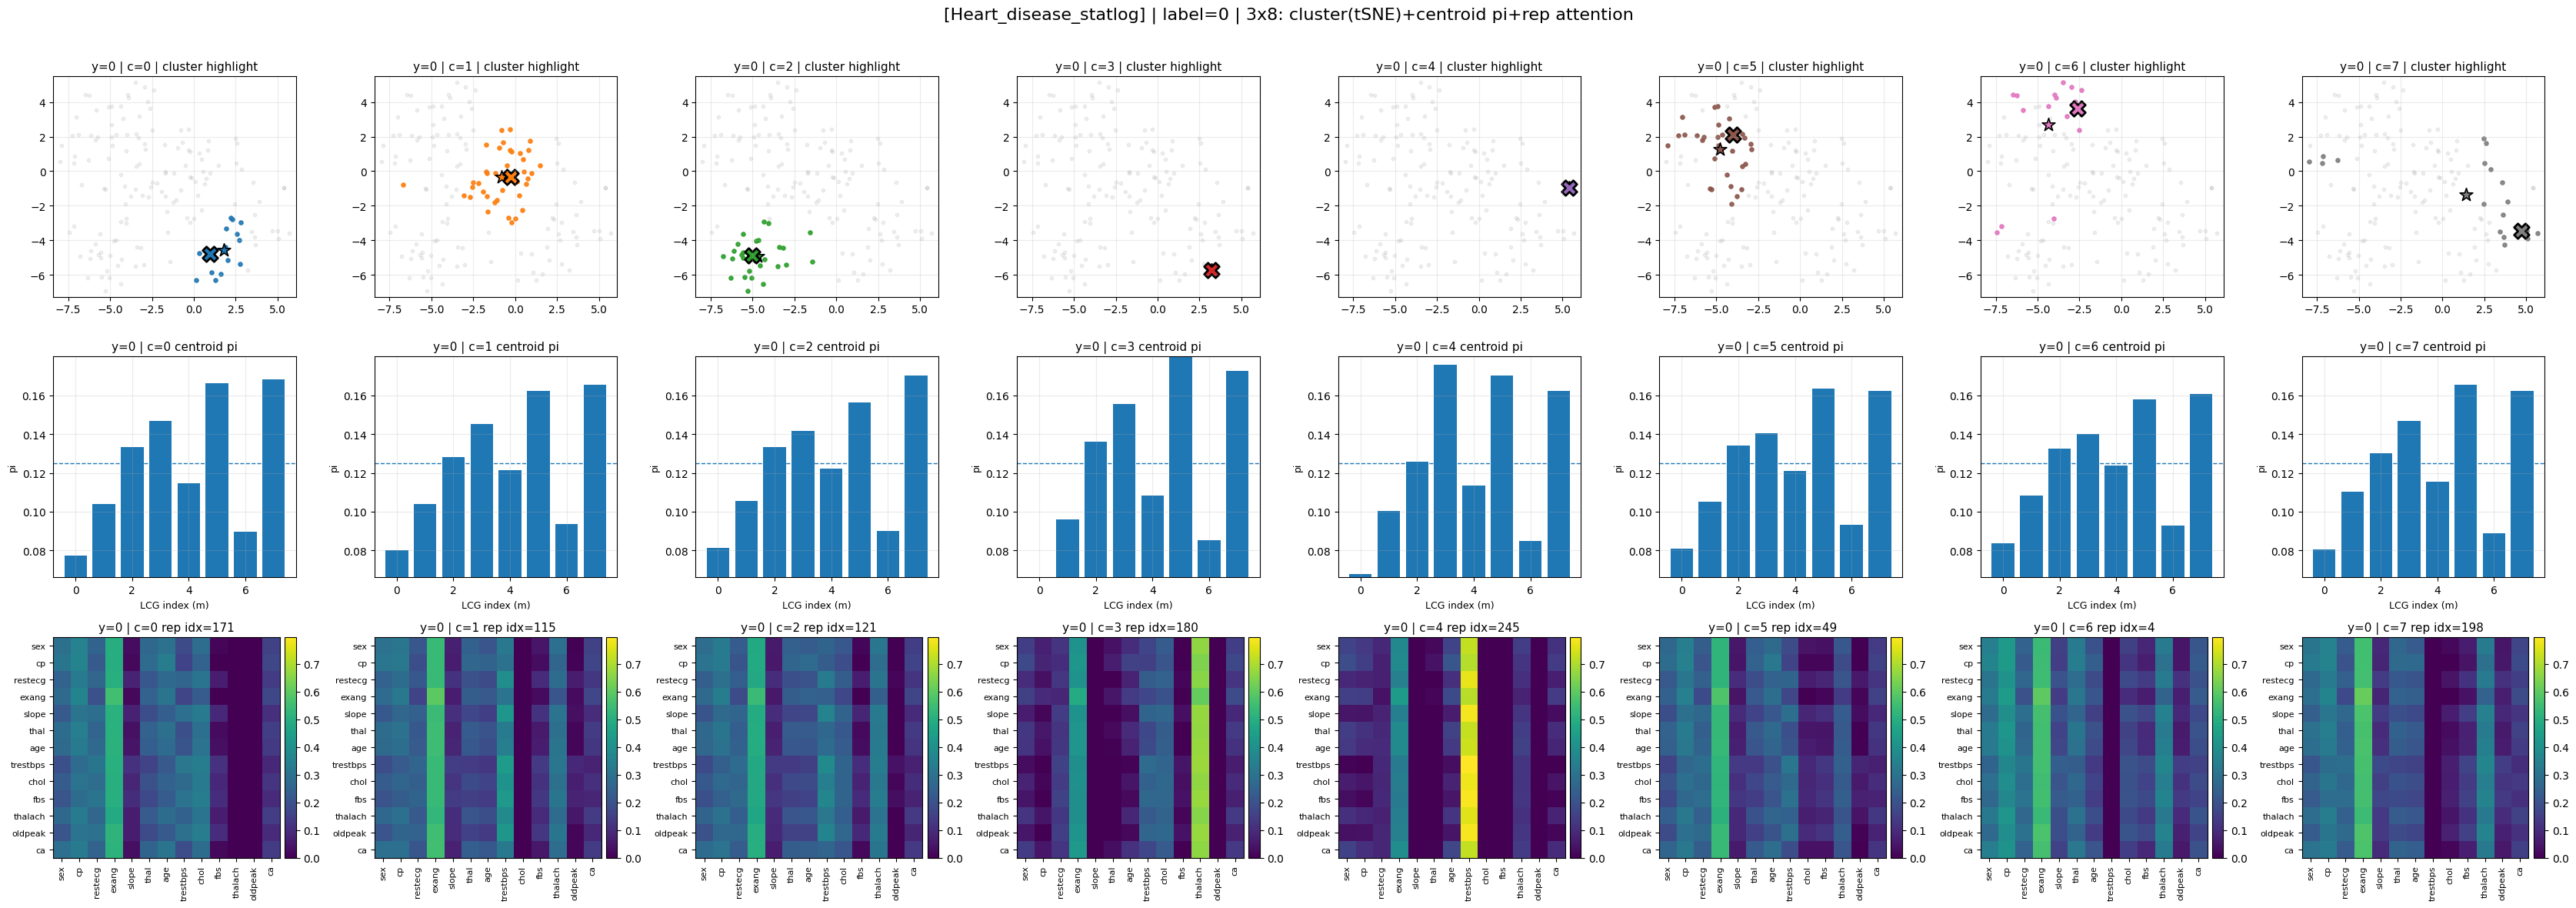

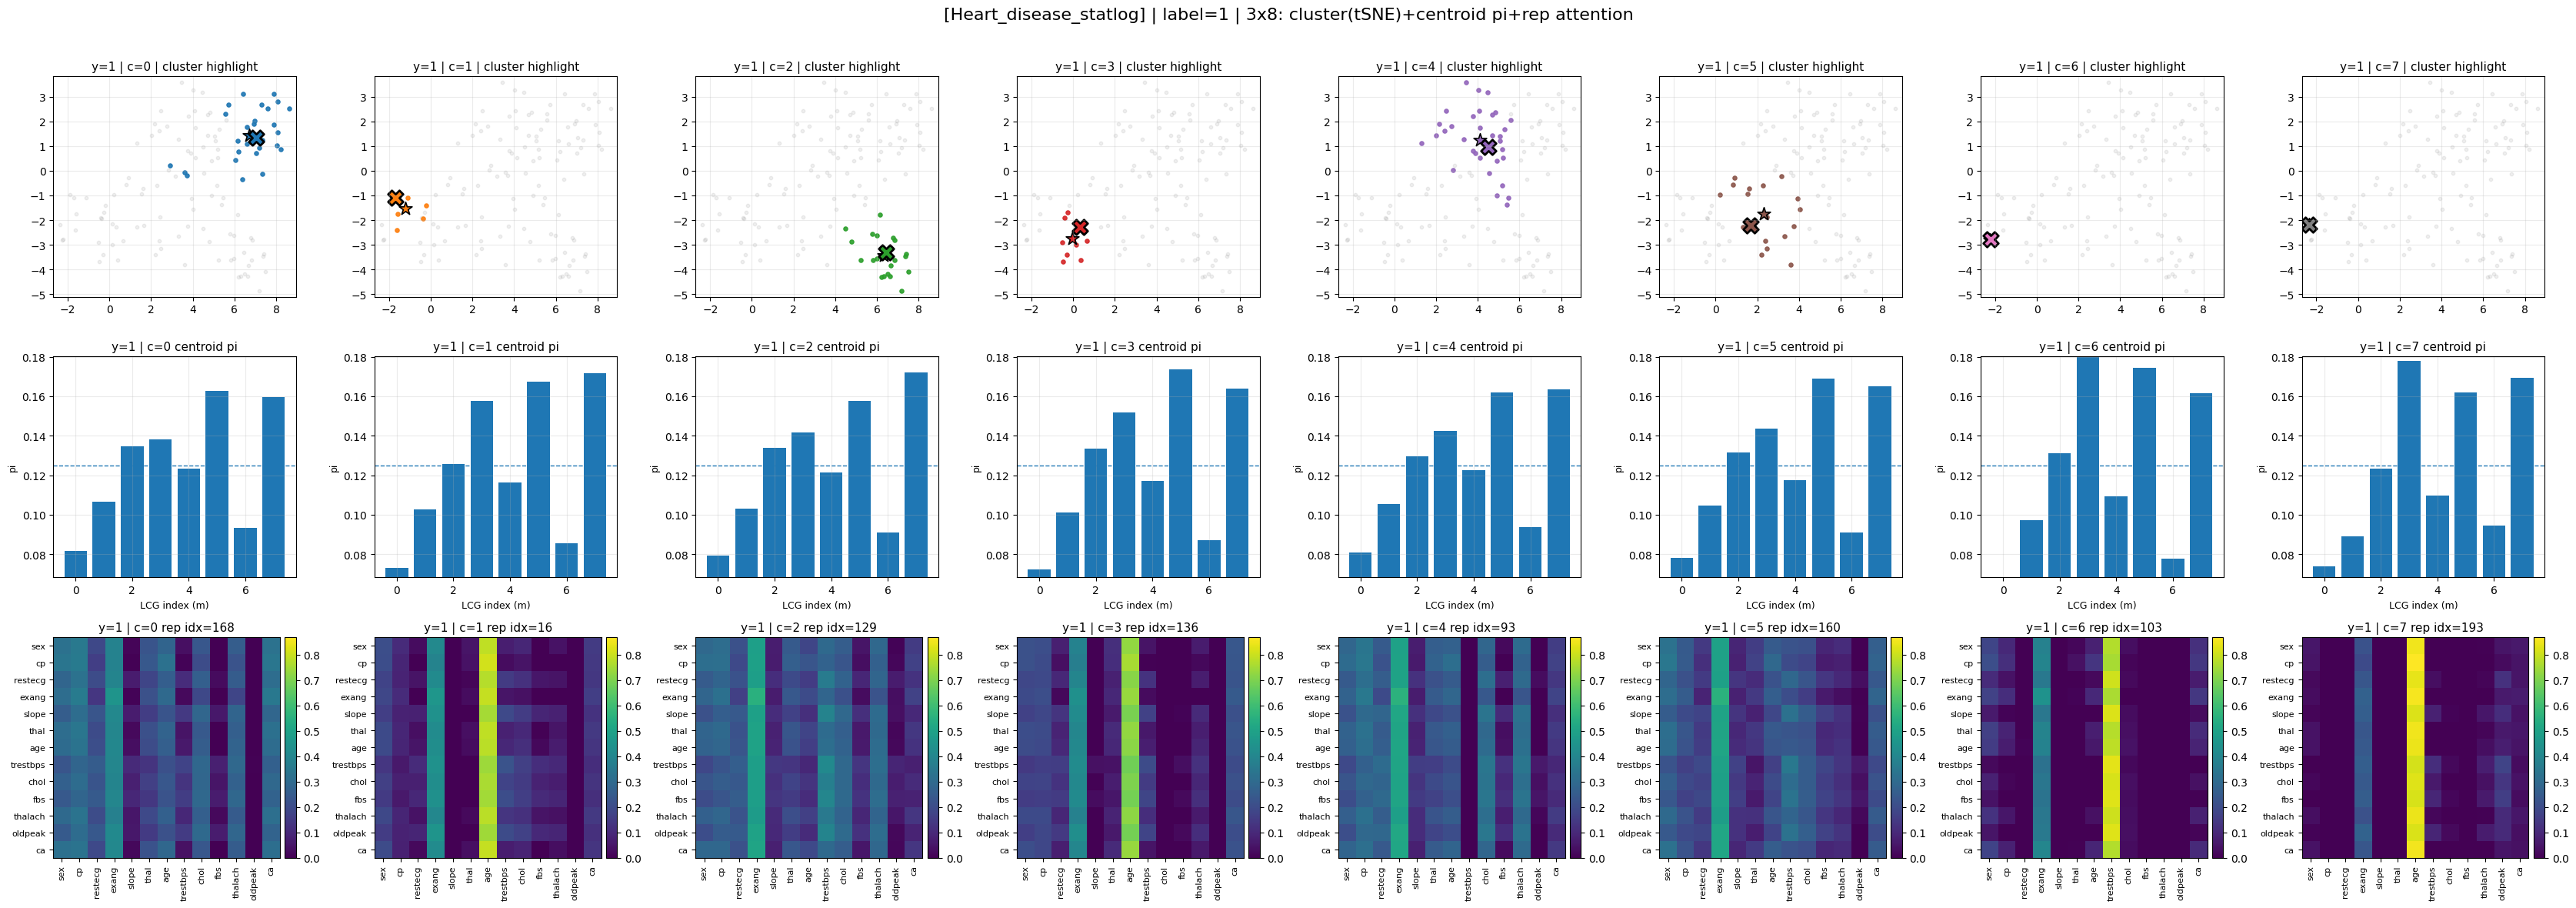

In [36]:
out = plot_3xK_two_pages_by_source(model, loaders, device, "heart", K=8, seed=42)

## Qualitative Analysis - Attention_map-to-Coordinates

In [37]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
from collections import Counter

def _strip_cls_if_needed(A, node_names, include_cls=False):
    if include_cls:
        return A, node_names
    if node_names is not None and len(node_names) > 0 and str(node_names[0]).upper() == "CLS":
        if A.shape[0] == len(node_names) and A.shape[0] >= 2:
            return A[1:, 1:], node_names[1:]
    return A, node_names

def _pad_square(A, Nmax, pad_value=0.0):
    N = A.shape[0]
    B = np.full((Nmax, Nmax), pad_value, dtype=A.dtype)
    n = min(N, Nmax)
    B[:n, :n] = A[:n, :n]
    return B

def _tsne_2d(X, seed=42):
    N = X.shape[0]
    perp = max(5, min(40, (N - 1) // 3))
    return TSNE(
        n_components=2, perplexity=perp, learning_rate=200,
        init="pca", random_state=seed
    ).fit_transform(X)

def _fit_kmeans_att_and_pick_reps(X_att, K=8, seed=42):
    n = X_att.shape[0]
    k_eff = min(int(K), int(n))
    if k_eff < 2:
        return None

    km = KMeans(n_clusters=k_eff, random_state=seed, n_init=20)
    cid = km.fit_predict(X_att)
    C = km.cluster_centers_

    reps_local = []
    for c in range(k_eff):
        idx = np.where(cid == c)[0]
        d = np.linalg.norm(X_att[idx] - C[c][None, :], axis=1)
        reps_local.append(int(idx[int(np.argmin(d))]))
    return {"k_eff": k_eff, "km": km, "cid": cid, "reps_local": reps_local}

def _plot_3xK_one_label_attention_cluster_then_pi(
    pi_lab, ys_lab, A_lab_list, names_lab_list,
    label, K=8, seed=42, title_prefix="[src]",
    bg_alpha=0.12, fg_alpha=0.90, bg_size=10, fg_size=14
):
    n_lab, M = pi_lab.shape
    if n_lab < 2:
        print(f"[warn] label={label} samples too few: n={n_lab}")
        return

    # attention pad -> flatten (Frobenius 기준 KMeans와 동일)
    Nmax = max(A.shape[0] for A in A_lab_list)
    X_att = np.stack([_pad_square(A.astype(np.float32), Nmax).reshape(-1) for A in A_lab_list], axis=0)

    res = _fit_kmeans_att_and_pick_reps(X_att, K=K, seed=seed)
    if res is None:
        print(f"[warn] label={label} clustering not possible (n={n_lab}).")
        return

    k_eff = res["k_eff"]
    cid = res["cid"]
    reps_local = res["reps_local"]

    # t-SNE는 pi에서 (label subset에서만)
    xy = _tsne_2d(pi_lab, seed=seed)

    # axis 고정
    x_min, x_max = xy[:, 0].min(), xy[:, 0].max()
    y_min, y_max = xy[:, 1].min(), xy[:, 1].max()
    mx = 0.03 * (x_max - x_min + 1e-9)
    my = 0.03 * (y_max - y_min + 1e-9)
    x_min, x_max = x_min - mx, x_max + mx
    y_min, y_max = y_min - my, y_max + my

    # cluster별 mean pi
    mean_pis = []
    for c in range(k_eff):
        idx = np.where(cid == c)[0]
        mean_pis.append(pi_lab[idx].mean(axis=0))
    mean_pis = np.stack(mean_pis, axis=0)
    pi_ymin = float(mean_pis.min())
    pi_ymax = float(mean_pis.max())
    uniform = 1.0 / M

    # heatmap scale: reps 기준으로 통일
    rep_mats = [A_lab_list[r] for r in reps_local]
    vmin = min(m.min() for m in rep_mats)
    vmax = max(m.max() for m in rep_mats)

    fig, axes = plt.subplots(3, K, figsize=(4.2 * K, 12))
    if K == 1:
        axes = np.expand_dims(axes, 1)

    def draw_cluster(ax, c):
        ax.scatter(xy[:, 0], xy[:, 1], s=bg_size, alpha=bg_alpha, color="gray")
        m = (cid == c)
        ax.scatter(xy[m, 0], xy[m, 1], s=fg_size, alpha=fg_alpha, color=f"C{c % 10}")

        r = reps_local[c]
        ax.scatter([xy[r, 0]], [xy[r, 1]],
                   s=200, marker="X", edgecolors="black", linewidths=2.0, color=f"C{c % 10}")

        ax.set_title(f"y={label} | att-cluster c={c} (n={m.sum()})", fontsize=11)
        ax.set_xlim(x_min, x_max); ax.set_ylim(y_min, y_max)
        ax.grid(True, alpha=0.25)

    def draw_pi(ax, c):
        mp = mean_pis[c]
        ax.bar(np.arange(M), mp)
        ax.axhline(uniform, linestyle="--", linewidth=1)
        ax.set_ylim(pi_ymin, pi_ymax)
        ax.set_title(f"y={label} | c={c} mean pi", fontsize=11)
        ax.set_xlabel("LCG index (m)", fontsize=9)
        ax.set_ylabel("pi", fontsize=9)
        ax.grid(True, alpha=0.25)

    def draw_att(ax, c):
        r = reps_local[c]
        A = A_lab_list[r]
        nm = list(names_lab_list[r]) if names_lab_list[r] is not None else []

        N = A.shape[0]
        if len(nm) > N:
            nm = nm[:N]
        elif len(nm) < N:
            nm = nm + [""] * (N - len(nm))

        im = ax.imshow(A, vmin=vmin, vmax=vmax, aspect="auto")
        ax.set_title(f"y={label} | rep(local)={r}", fontsize=11)
        ax.set_xticks(range(N)); ax.set_yticks(range(N))
        ax.set_xticklabels(nm, rotation=90, fontsize=8)
        ax.set_yticklabels(nm, fontsize=8)
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.02)

    for c in range(K):
        if c >= k_eff:
            axes[0, c].axis("off"); axes[1, c].axis("off"); axes[2, c].axis("off")
            continue
        draw_cluster(axes[0, c], c)
        draw_pi(axes[1, c], c)
        draw_att(axes[2, c], c)

    fig.suptitle(f"{title_prefix} | label={label} | Attention-cluster -> pi consistency | 3x{K}", fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.965])
    plt.show()


def plot_attention_cluster_then_pi_by_label(
    model, loaders, device, source_name,
    K=8, seed=42, include_cls=False
):
    # 1) source loader
    src_key, loader = get_loader_by_key(loaders, source_name)
    print("Using source:", src_key)

    # 2) collect (기존 함수 그대로)
    pis, ys, affs, names = collect_pi_and_affinity_for_one_source(model, loader, device)
    print(f"[{src_key}] collected: N={pis.shape[0]}, M={pis.shape[1]}, labels={Counter(ys.tolist())}")

    # 3) (옵션) CLS 제거한 attention/names로 변환 (샘플별)
    A_list = []
    name_list = []
    for A, nm in zip(affs, names):
        A2, nm2 = _strip_cls_if_needed(A, nm, include_cls=include_cls)
        A_list.append(A2)
        name_list.append(nm2)

    # 4) label별로 따로(2장)
    for lab in [0, 1]:
        idx = np.where(ys == lab)[0]
        pi_lab = pis[idx]
        ys_lab = ys[idx]
        A_lab_list = [A_list[i] for i in idx]
        names_lab_list = [name_list[i] for i in idx]

        _plot_3xK_one_label_attention_cluster_then_pi(
            pi_lab, ys_lab, A_lab_list, names_lab_list,
            label=lab, K=K, seed=seed,
            title_prefix=f"[{src_key}]",
        )

    return {"src_key": src_key, "pis": pis, "ys": ys}



Using source: Heart_disease_statlog
[Heart_disease_statlog] collected: N=270, M=8, labels=Counter({0: 150, 1: 120})


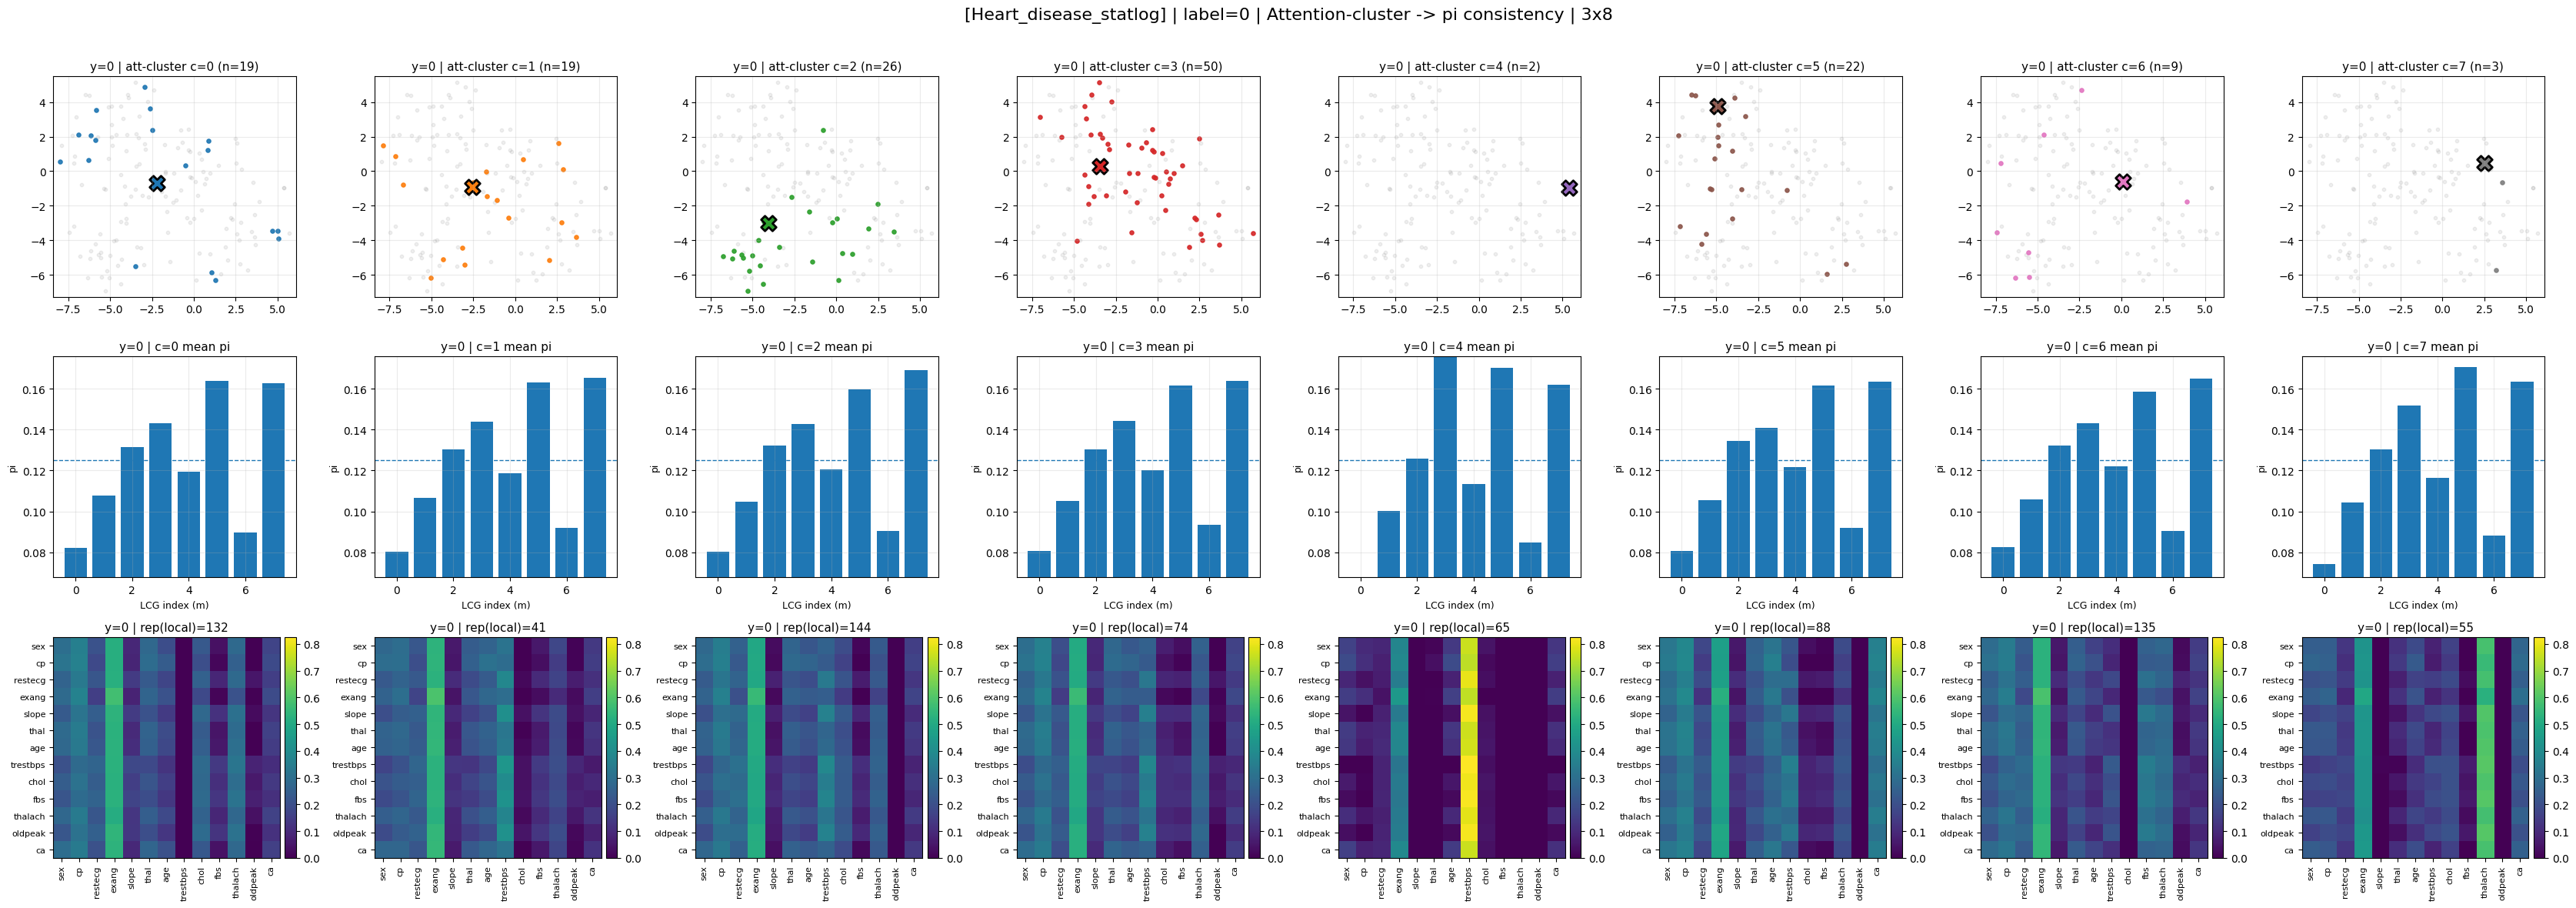

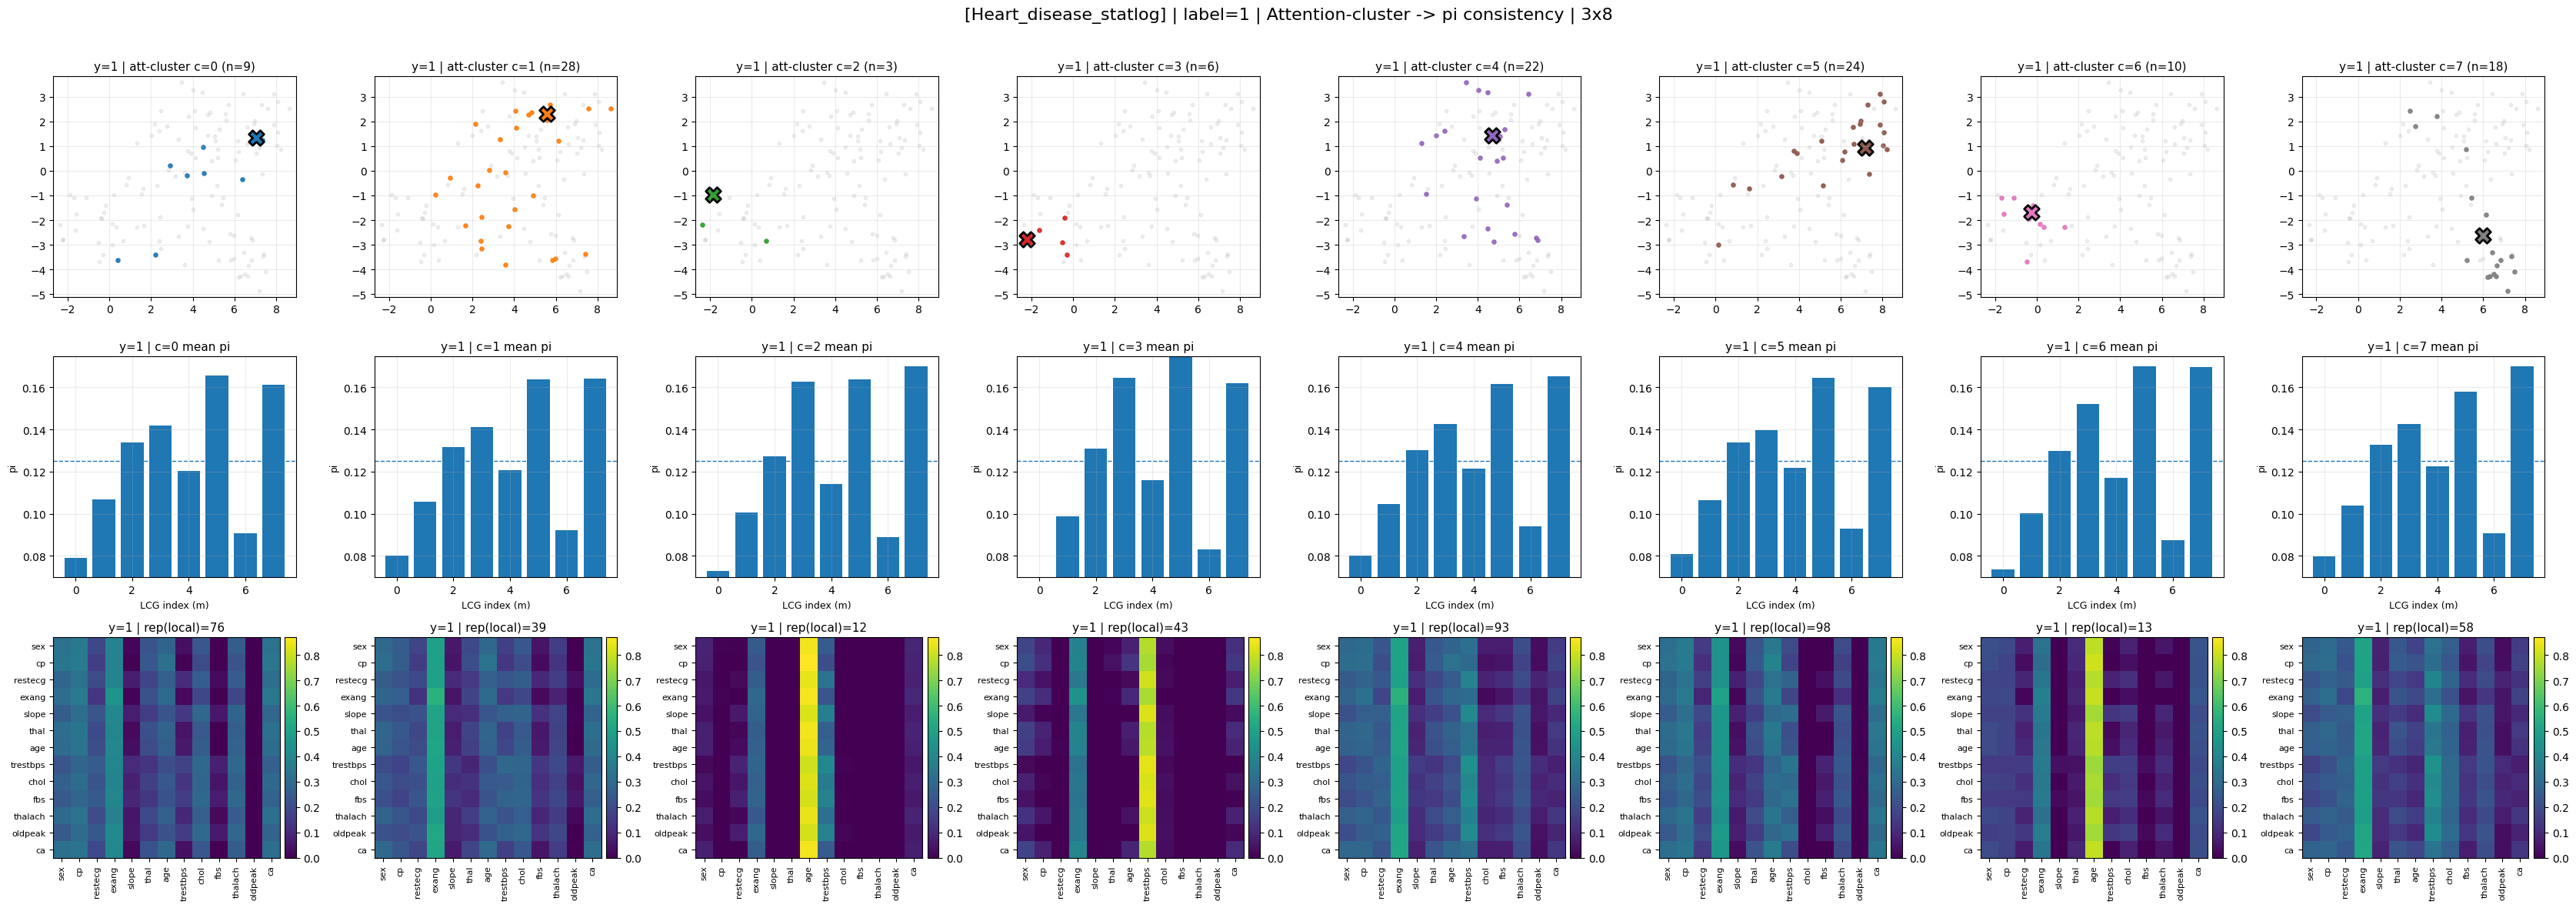

In [38]:
out = plot_attention_cluster_then_pi_by_label(model, loaders, device, "heart", K=8, seed=42, include_cls=False)

## Qualitative Analysis - Coordinate distribution 

In [39]:
def summarize_pi_by_label(pis, ys, title_prefix="[Medicaldataset]"):
    pis = np.asarray(pis)          # [N, M]
    ys  = np.asarray(ys).astype(int)

    M = pis.shape[1]
    u = np.ones(M) / M
    eps = 1e-12

    # vector -> scalar summaries
    l2_to_uniform = np.linalg.norm(pis - u[None, :], axis=1)                 # [N]
    entropy = -np.sum(pis * np.log(np.clip(pis, eps, 1.0)), axis=1)          # [N]
    maxprob = np.max(pis, axis=1)                                            # [N]

    def stats(arr):
        return arr.mean(), arr.std()

    metrics = [
        ("L2(pi, uniform)", l2_to_uniform),
        ("Entropy(pi)", entropy),
        ("Max(pi)", maxprob),
    ]

    # print mean/std
    print(f"{title_prefix} N={len(ys)} | M={M} | n(y=0)={(ys==0).sum()} | n(y=1)={(ys==1).sum()}")
    for name, arr in metrics:
        m0, s0 = stats(arr[ys==0])
        m1, s1 = stats(arr[ys==1])
        print(f"- {name:15s} | y=0: mean={m0:.6f}, std={s0:.6f} | y=1: mean={m1:.6f}, std={s1:.6f}")

    # plot distributions (3 panels)
    fig, axes = plt.subplots(1, 3, figsize=(13, 4))

    for ax, (name, arr) in zip(axes, metrics):
        a0 = arr[ys==0]; a1 = arr[ys==1]
        bins = 60

        ax.hist(a0, bins=bins, density=True, alpha=0.5, label=f"y=0 (n={len(a0)})")
        ax.hist(a1, bins=bins, density=True, alpha=0.5, label=f"y=1 (n={len(a1)})")

        m0, s0 = a0.mean(), a0.std()
        m1, s1 = a1.mean(), a1.std()

        ax.axvline(m0, linestyle="--", linewidth=1)
        ax.axvline(m1, linestyle="--", linewidth=1)

        ax.set_title(name)
        ax.set_xlabel("value"); ax.set_ylabel("density")
        ax.grid(True, alpha=0.25)
        ax.legend(frameon=True, fontsize=8)

    plt.tight_layout()
    plt.show()


@torch.no_grad()
def collect_pi_and_affinity_for_one_source(model, loader, device):
    model.eval()
    pis = []
    ys = []
    affs = []
    names = []

    for batch in loader:
        batch_t = {k: (v.to(device) if torch.is_tensor(v) else v) for k, v in batch.items()}

        _ = model.predict(batch_t, return_all=True)

        pi = model.graph_quantizer.last_pi          # [B, M]
        P_1matt  = model._last_P_basis              # [B, N, N]  == (1 - att)

        if pi is None or P_1matt is None:
            raise RuntimeError("pi 또는 _last_P_basis가 None. args.use_lcg=True인지 확인.")

        # attention 자체로 변환
        att = 1.0 - P_1matt
        att = torch.clamp(att, 0.0, 1.0)

        # 변수명은 batch 기준으로 뽑음 (배치 내 샘플들 동일 전제)
        var_names = extract_feature_names(batch)

        B = pi.shape[0]
        for b in range(B):
            A = att[b].detach().cpu().numpy()
            N = A.shape[0]

            # 축 라벨 길이를 A 크기에 맞춤 (v0 같은 거 안 쓰고, 가능한 이름만 씀)
            if N == len(var_names) + 1:
                node_names = ["CLS"] + var_names
            elif N == len(var_names):
                node_names = var_names
            elif N < len(var_names):
                node_names = var_names[:N]
            else:
                node_names = var_names + [""] * (N - len(var_names))

            pis.append(pi[b].detach().cpu().numpy())              # [M]
            ys.append(int(batch_t["y"][b].item()))
            affs.append(A)                                        # [N,N]  (attention)
            names.append(node_names)                              # 길이 N 라벨

    pis = np.stack(pis, axis=0)
    ys  = np.array(ys, dtype=int)
    return pis, ys, affs, names

def summarize_pi_by_label_for_source(
    model, loaders, device,
    source_name: str,
    title_prefix: str = None
):
    # 0) loader 찾기
    src_key, loader = get_loader_by_key(loaders, source_name)

    # 1) pi, y 수집 (기존 로직 유지: collect_pi_and_affinity_for_one_source 사용)
    pis, ys, _, _ = collect_pi_and_affinity_for_one_source(model, loader, device)

    # 2) 요약 + plot
    if title_prefix is None:
        title_prefix = f"[SOURCE:{src_key}]"
    summarize_pi_by_label(pis, ys, title_prefix=title_prefix)

    return src_key, pis, ys


[SOURCE:Heart_disease_statlog] N=270 | M=8 | n(y=0)=150 | n(y=1)=120
- L2(pi, uniform) | y=0: mean=0.083294, std=0.005888 | y=1: mean=0.085615, std=0.008480
- Entropy(pi)     | y=0: mean=2.050987, std=0.004274 | y=1: mean=2.049204, std=0.006341
- Max(pi)         | y=0: mean=0.166302, std=0.003796 | y=1: mean=0.167855, std=0.005313


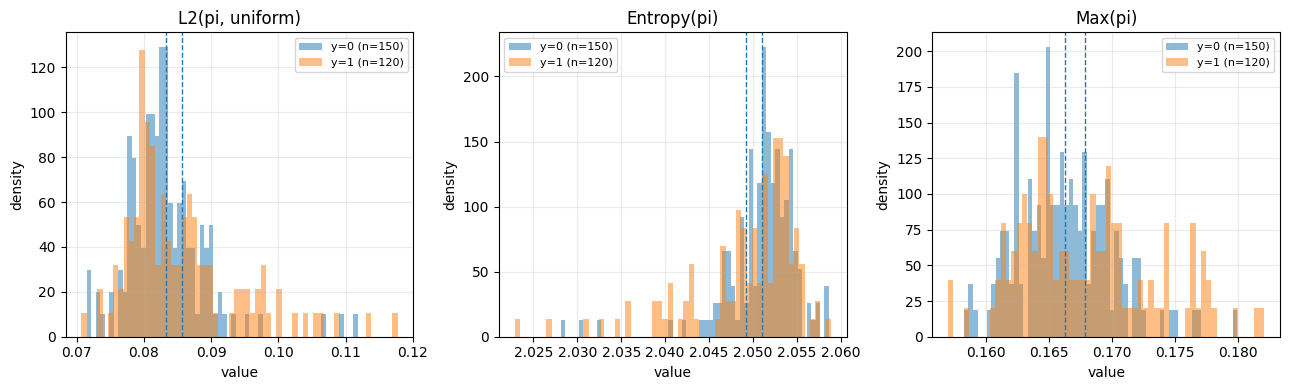

In [40]:
src_key, pis_s, ys_s = summarize_pi_by_label_for_source(model, loaders, device, "heart")

In [41]:
args.source_data

['Medicaldataset',
 'Cardiovascular_Disease_Dataset',
 'Heart_disease_statlog',
 'Erbil_Cardiovascular_Health_Dataset',
 'cardio_SAheart',
 'heart_failure_clinical_records']

[SOURCE:Heart_disease_statlog] N=270 | M=8 | n(y=0)=150 | n(y=1)=120
- L2(pi, uniform) | y=0: mean=0.083294, std=0.005888 | y=1: mean=0.085615, std=0.008480
- Entropy(pi)     | y=0: mean=2.050987, std=0.004274 | y=1: mean=2.049204, std=0.006341
- Max(pi)         | y=0: mean=0.166302, std=0.003796 | y=1: mean=0.167855, std=0.005313


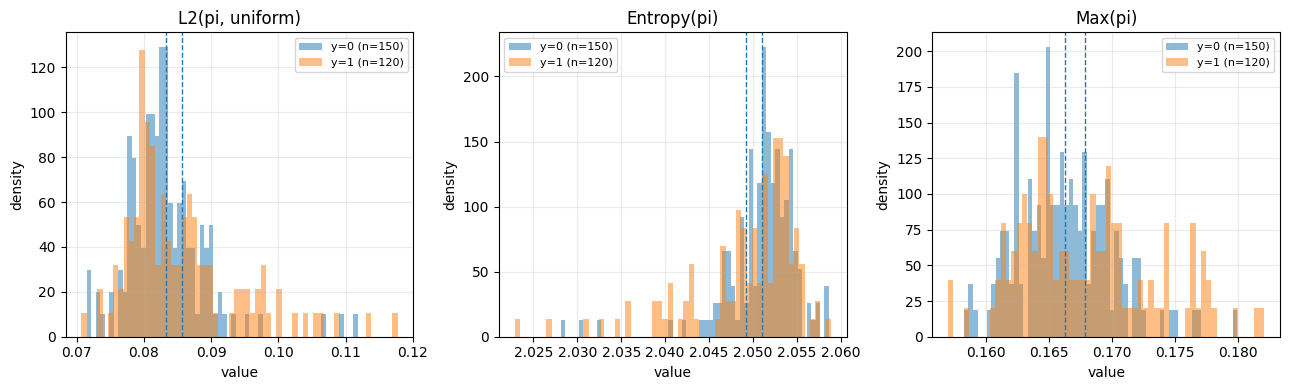

In [42]:
src_key, pis_s, ys_s = summarize_pi_by_label_for_source(model, loaders, device, "heart")

[SOURCE:Heart_disease_statlog] N=270 | M=8 | n(y=0)=150 | n(y=1)=120
- L2(pi, uniform) | y=0: mean=0.083294, std=0.005888 | y=1: mean=0.085615, std=0.008480
- Entropy(pi)     | y=0: mean=2.050987, std=0.004274 | y=1: mean=2.049204, std=0.006341
- Max(pi)         | y=0: mean=0.166302, std=0.003796 | y=1: mean=0.167855, std=0.005313


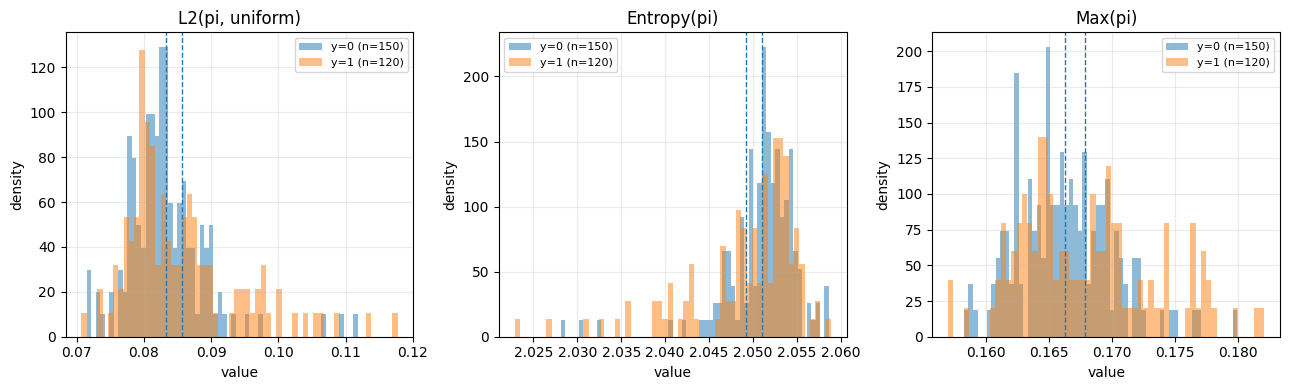

In [43]:
src_key, pis_s, ys_s = summarize_pi_by_label_for_source(model, loaders, device, "Heart_disease_statlog")

[SOURCE:cardio_SAheart] N=462 | M=8 | n(y=0)=302 | n(y=1)=160
- L2(pi, uniform) | y=0: mean=0.075647, std=0.006591 | y=1: mean=0.076656, std=0.007000
- Entropy(pi)     | y=0: mean=2.055829, std=0.004131 | y=1: mean=2.055148, std=0.004479
- Max(pi)         | y=0: mean=0.163873, std=0.004264 | y=1: mean=0.163121, std=0.003897


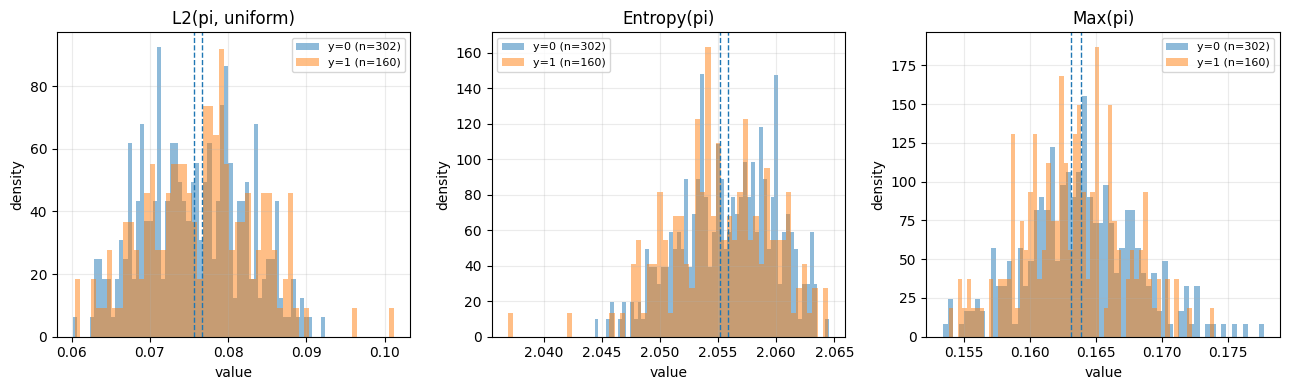

In [44]:
src_key, pis_s, ys_s = summarize_pi_by_label_for_source(model, loaders, device, "cardio_SAheart")

## Qualitative Analysis - Risk Stratification 

- label-wise risk stratification
- label-wise Attention map 
- label-wise Gap between the stratification bin 
- label-wise coordinates assigned to corresponding stratification bin

In [45]:
from matplotlib import gridspec

In [46]:
import numpy as np
import matplotlib.pyplot as plt


@torch.no_grad()
def collect_pi_y_phat_att_names_one_source(model, loader, device):
    model.eval()

    pis, ys, phats = [], [], []
    affs, names = [], []

    def _is_pred_shape(t, B):
        if not torch.is_tensor(t):
            return False
        if t.ndim == 2 and t.shape[0] == B and t.shape[1] in (1, 2):
            return True
        if t.ndim == 1 and t.shape[0] == B:
            return True
        return False

    def _find_pred_tensor(obj, B):
        # tensor
        if torch.is_tensor(obj):
            return obj if _is_pred_shape(obj, B) else None
        # numpy
        if isinstance(obj, np.ndarray):
            t = torch.from_numpy(obj)
            return t if _is_pred_shape(t, B) else None
        # dict: 흔한 키 우선
        if isinstance(obj, dict):
            for k in ["logits", "logit", "y_logit", "pred_logit",
                      "prob", "probs", "p", "pred_prob", "y_prob",
                      "pred", "preds", "y_pred"]:
                if k in obj and obj[k] is not None:
                    t = _find_pred_tensor(obj[k], B)
                    if t is not None:
                        return t
            # fallback: 모든 value 탐색
            for v in obj.values():
                t = _find_pred_tensor(v, B)
                if t is not None:
                    return t
            return None
        # tuple/list: 앞에서부터 탐색 (보통 logits가 첫 원소)
        if isinstance(obj, (tuple, list)):
            for v in obj:
                t = _find_pred_tensor(v, B)
                if t is not None:
                    return t
            return None
        return None

    def to_prob(out, B):
        t = _find_pred_tensor(out, B)
        if t is None:
            raise RuntimeError(f"predict output에서 [B] / [B,1] / [B,2] 텐서를 못 찾음. type(out)={type(out)}")

        t = t.detach()

        # [B,2] -> softmax class-1
        if t.ndim == 2 and t.shape[1] == 2:
            # 이미 prob일 수도 있으니(0~1, row sum ~1) 체크
            if (t.min() >= 0.0) and (t.max() <= 1.0):
                row_sum = t.sum(dim=1)
                if torch.allclose(row_sum, torch.ones_like(row_sum), atol=1e-2, rtol=1e-2):
                    p = t[:, 1]
                else:
                    p = torch.softmax(t.float(), dim=1)[:, 1]
            else:
                p = torch.softmax(t.float(), dim=1)[:, 1]
            return torch.clamp(p.float(), 0.0, 1.0)

        # [B,1] -> [B]
        if t.ndim == 2 and t.shape[1] == 1:
            t = t[:, 0]

        # [B] : prob면 그대로, logit이면 sigmoid
        if t.ndim == 1:
            if (t.min() >= 0.0) and (t.max() <= 1.0):
                return torch.clamp(t.float(), 0.0, 1.0)
            return torch.clamp(torch.sigmoid(t.float()), 0.0, 1.0)

        raise RuntimeError(f"예상 못한 pred tensor shape={tuple(t.shape)}")

    for batch in loader:
        batch_t = {k: (v.to(device) if torch.is_tensor(v) else v) for k, v in batch.items()}

        out = model.predict(batch_t, return_all=True)

        pi = model.graph_quantizer.last_pi              # [B, M]
        if pi is None:
            raise RuntimeError("last_pi가 None. use_lcg=True인지 확인.")

        P_1matt = model._last_P_basis                   # [B, N, N]  (1-att)
        if P_1matt is None:
            raise RuntimeError("_last_P_basis가 None. forward에서 저장되는지 확인.")

        att = 1.0 - P_1matt
        att = torch.clamp(att, 0.0, 1.0)

        B = pi.shape[0]
        p_hat = to_prob(out, B)                         # [B]
        y = batch_t["y"].detach().view(-1).long()       # [B]

        # feature names (batch에서 추출)
        var_names = extract_feature_names(batch)

        for b in range(B):
            A = att[b].detach().cpu().numpy()
            Nn = A.shape[0]

            if Nn == len(var_names) + 1:
                node_names = ["CLS"] + var_names
            else:
                node_names = var_names[:Nn] + [""] * max(0, Nn - len(var_names))

            pis.append(pi[b].detach().cpu().numpy())
            ys.append(int(y[b].item()))
            phats.append(float(p_hat[b].item()))
            affs.append(A)
            names.append(node_names)

    pis   = np.stack(pis, axis=0)
    ys    = np.array(ys, dtype=int)
    phats = np.array(phats, dtype=float)
    return pis, ys, phats, affs, names

import numpy as np
from matplotlib import gridspec

# =========================================================
# 1) robust_center
#   - arr: [n] or [n, d] ...
#   - axis=0 기준으로 robust center 반환
# =========================================================
def robust_center(arr, method="median", trim=0.1, axis=0):
    x = np.asarray(arr)

    if x.size == 0:
        raise ValueError("robust_center: empty array")

    method = str(method).lower()

    if method in ["median", "med"]:
        return np.median(x, axis=axis)

    if method in ["mean", "avg", "average"]:
        return np.mean(x, axis=axis)

    if method in ["trimmed", "trim", "trimmed_mean", "trimmean"]:
        # trimmed mean along axis=0
        n = x.shape[axis]
        if n <= 2:
            return np.mean(x, axis=axis)

        k = int(np.floor(trim * n))
        k = max(0, min(k, (n - 1) // 2))  # 최소 1개는 남기기

        x_sorted = np.sort(x, axis=axis)

        # slice [k : n-k]
        slicer = [slice(None)] * x_sorted.ndim
        slicer[axis] = slice(k, n - k)
        x_trim = x_sorted[tuple(slicer)]

        return np.mean(x_trim, axis=axis)

    raise ValueError(f"robust_center: unknown method={method}")


# =========================================================
# 2) robust_spread_mad
#   - MAD = median(|x - median(x)|)
# =========================================================
def robust_spread_mad(arr, axis=0):
    x = np.asarray(arr)
    if x.size == 0:
        raise ValueError("robust_spread_mad: empty array")

    med = np.median(x, axis=axis, keepdims=True)
    mad = np.median(np.abs(x - med), axis=axis)
    return mad


# =========================================================
# 3) compute_pi_summaries
#   - pis: [N, M]
#   - return dict: {"l2": [N], "ent": [N], "max": [N]}
# =========================================================
def compute_pi_summaries(pis, eps=1e-12):
    P = np.asarray(pis, dtype=float)
    if P.ndim != 2:
        raise ValueError(f"compute_pi_summaries: pis must be 2D, got shape={P.shape}")

    N, M = P.shape

    # 혹시 row-sum이 1이 아닐 경우를 대비한 정규화(큰 변화는 없을 것)
    s = P.sum(axis=1, keepdims=True)
    s = np.where(s <= eps, 1.0, s)
    Pn = P / s

    u = np.full((1, M), 1.0 / M, dtype=float)

    l2 = np.sqrt(((Pn - u) ** 2).sum(axis=1))
    ent = -(Pn * np.log(Pn + eps)).sum(axis=1)
    mx = Pn.max(axis=1)

    return {"l2": l2, "ent": ent, "max": mx}


# =========================================================
# 4) stratify_kmedoids_1d
#   - 1D에서 "k-medoids(L1)" 최적 partition (sorted contiguous)
#   - 사실상 optimal k-medians과 동일하며 medoid=median-point (data point)
#   - 반환:
#       clusters: list of np.array (각 bin에 속한 local index들)
#       medoids : list of int (각 bin medoid의 local index)
# =========================================================
def stratify_kmedoids_1d(x, n_bins=5, seed=0):
    x = np.asarray(x, dtype=float).reshape(-1)
    n = len(x)
    K = int(n_bins)
    if K <= 0:
        raise ValueError("stratify_kmedoids_1d: n_bins must be >= 1")
    if n == 0:
        raise ValueError("stratify_kmedoids_1d: empty x")
    if K > n:
        # bin 수가 더 크면: 각 점을 1개짜리 bin으로 만들고 나머지는 합치기보단
        # 호출부에서 이미 방어하니까 여기선 안전하게 K를 줄임
        K = n

    order = np.argsort(x)
    xs = x[order]

    pref = np.cumsum(xs)  # pref[j] = sum_{0..j}

    def seg_cost(i, j):
        """cost for segment xs[i..j] (inclusive) under L1 with medoid at median point"""
        m = (i + j) // 2
        xm = xs[m]

        left_sum = pref[m] - (pref[i - 1] if i > 0 else 0.0)
        right_sum = (pref[j] - pref[m])

        # left part: sum_{i..m} (xm - xs[t])
        left_cost = xm * (m - i + 1) - left_sum
        # right part: sum_{m+1..j} (xs[t] - xm)
        right_cost = right_sum - xm * (j - m)

        return left_cost + right_cost

    INF = 1e30
    dp = np.full((K + 1, n), INF, dtype=float)
    bk = np.full((K + 1, n), -1, dtype=int)

    # k=1
    for j in range(n):
        dp[1, j] = seg_cost(0, j)
        bk[1, j] = -1

    # k=2..K
    for k in range(2, K + 1):
        # 최소 j는 k-1 이상이어야 k개로 나눌 수 있음
        for j in range(k - 1, n):
            best = INF
            best_t = -1
            # 이전 경계 t: (0..t)까지 k-1개, (t+1..j)가 마지막 cluster
            for t in range(k - 2, j):
                val = dp[k - 1, t] + seg_cost(t + 1, j)
                if val < best:
                    best = val
                    best_t = t
            dp[k, j] = best
            bk[k, j] = best_t

    # reconstruct segments in sorted-index space
    segments = []
    j = n - 1
    k = K
    while k >= 1:
        t = bk[k, j]
        i = 0 if t < 0 else (t + 1)
        segments.append((i, j))
        j = t
        k -= 1
    segments = segments[::-1]  # low -> high

    clusters = []
    medoids = []
    for (i, j) in segments:
        idx_sorted = np.arange(i, j + 1)
        idx_local = order[idx_sorted]  # local indices in original x
        clusters.append(idx_local.astype(int))

        m = (i + j) // 2
        medoids.append(int(order[m]))

    return clusters, medoids


# =========================================================
# 2) label별: risk bins(k-medoids) + medoids(global index) 만들기
# =========================================================
def build_bins_and_medoids_global(ys, phats, label, n_bins=5, seed=0):
    idx_lab = np.where(ys == label)[0]                 # global indices
    ph_l = phats[idx_lab]                              # label subset

    clusters_local, medoids_local = stratify_kmedoids_1d(ph_l, n_bins=n_bins, seed=seed)

    # bin id (label-subset local index 기준)
    bin_id_local = np.empty(len(idx_lab), dtype=int)
    for b, cl in enumerate(clusters_local):
        bin_id_local[cl] = b

    # medoids global index로 변환
    medoids_global = [int(idx_lab[m]) for m in medoids_local]

    return idx_lab, bin_id_local, medoids_global


# =========================================================
# 3) label별: t-SNE(pi)에서 bin highlight + medoid 표시
# =========================================================
def plot_tsne_pi_bins_with_medoids(pis, ys, phats, label, idx_lab, bin_id_local, medoids_global,
                                  n_bins=5, tsne_seed=42, title_prefix="[source]"):
    X = pis[idx_lab]  # [n_lab, M]
    n = X.shape[0]
    perp = max(5, min(40, (n - 1) // 3))
    xy = TSNE(n_components=2, perplexity=perp, learning_rate=200, init="pca", random_state=tsne_seed).fit_transform(X)

    plt.figure(figsize=(7.2, 6.2))
    for b in range(n_bins):
        m = (bin_id_local == b)
        plt.scatter(xy[m, 0], xy[m, 1], s=12, alpha=0.55, label=f"bin{b} (n={m.sum()})")

        # medoid (X)
        g = medoids_global[b]
        l = int(np.where(idx_lab == g)[0][0])
        plt.scatter(xy[l, 0], xy[l, 1], s=220, marker="X", edgecolors="black", linewidths=2.0)
        plt.text(xy[l, 0], xy[l, 1], f"  b{b}", fontsize=10, weight="bold")

    plt.title(f"{title_prefix} | y={label} | t-SNE(pi) colored by risk bins + medoids")
    plt.xlabel("t-SNE 1"); plt.ylabel("t-SNE 2")
    plt.grid(True, alpha=0.25)
    plt.legend(fontsize=8, frameon=True)
    plt.tight_layout()
    plt.show()

# =========================================================
# (NEW) Δpi: label 0/1을 한 figure로 (2x1)
# =========================================================
def plot_delta_pi_kmedoids_robust_2labels(pis, ys, phats, n_bins=5, seed=0, center="median", trim=0.1, title_prefix=""):
    pis = np.asarray(pis)
    ys = np.asarray(ys).astype(int)
    phats = np.asarray(phats).reshape(-1)

    fig, axes = plt.subplots(2, 1, figsize=(10, 5.6), sharex=True)
    labels = [0, 1]

    for r, lab in enumerate(labels):
        idx = np.where(ys == lab)[0]
        ax = axes[r]

        if len(idx) < n_bins:
            ax.set_title(f"y={lab} (too few: n={len(idx)})")
            ax.axis("off")
            continue

        pis_l = pis[idx]
        ph_l  = phats[idx]

        clusters, _ = stratify_kmedoids_1d(ph_l, n_bins=n_bins, seed=seed)

        pi_low  = robust_center(pis_l[clusters[0]],  method=center, trim=trim)
        pi_high = robust_center(pis_l[clusters[-1]], method=center, trim=trim)
        d = pi_high - pi_low  # (이건 stratification plot이라 유지)

        ax.bar(np.arange(pis.shape[1]), d, width=0.7)
        ax.axhline(0.0, linestyle="--", linewidth=1)
        ax.grid(True, alpha=0.25)
        #ax.set_title(f"y={lab} | Δpi = {center}(high_bin) - {center}(low_bin) | n_low={len(clusters[0])}, n_high={len(clusters[-1])}",
        #             fontsize=10)

    axes[-1].set_xlabel("prototype index (m)")
    fig.suptitle(f"{title_prefix} Δpi (2 labels)", fontsize=13)
    plt.tight_layout(rect=[0, 0, 1, 0.94])
    plt.show()


# =========================================================
# (NEW) scatter 2x3 (rows=label, cols=metrics)
# =========================================================
def plot_risk_scatter_metrics_kmedoids_robust_2labels(pis, ys, phats, n_bins=5, seed=0, center="median", trim=0.1, title_prefix=""):
    pis = np.asarray(pis)
    ys = np.asarray(ys).astype(int)
    phats = np.asarray(phats).reshape(-1)

    fig, axes = plt.subplots(2, 3, figsize=(14.5, 6.6))
    labels = [0, 1]
    metric_keys = [("l2", "L2(pi, uniform)"), ("ent", "Entropy(pi)"), ("max", "Max(pi)")]

    for r, lab in enumerate(labels):
        idx = np.where(ys == lab)[0]
        if len(idx) < n_bins:
            for c in range(3):
                axes[r, c].axis("off")
            continue

        pis_l = pis[idx]
        ph_l  = phats[idx]
        met = compute_pi_summaries(pis_l)

        clusters, _ = stratify_kmedoids_1d(ph_l, n_bins=n_bins, seed=seed)

        cx    = np.array([robust_center(ph_l[cl], method=center, trim=trim) for cl in clusters])
        c_l2  = np.array([robust_center(met["l2"][cl],  method=center, trim=trim) for cl in clusters])
        c_ent = np.array([robust_center(met["ent"][cl], method=center, trim=trim) for cl in clusters])
        c_max = np.array([robust_center(met["max"][cl], method=center, trim=trim) for cl in clusters])
        centers = {"l2": c_l2, "ent": c_ent, "max": c_max}

        for c, (k, name) in enumerate(metric_keys):
            ax = axes[r, c]
            ax.scatter(ph_l, met[k], s=14, alpha=0.35)
            ax.plot(cx, centers[k], marker="o")
            ax.set_xlabel("p_hat (risk)")
            ax.set_ylabel(name)
            ax.grid(True, alpha=0.25)
            ax.set_title(f"y={lab}", fontsize=10)

    #fig.suptitle(f"{title_prefix} k-medoids bins + {center} centers (2x3)", fontsize=13)
    plt.tight_layout(rect=[0, 0, 1, 0.94])
    plt.show()


# =========================================================
# (NEW) center±MAD 2x3
# =========================================================
def plot_cluster_curves_center_mad_2labels(pis, ys, phats, n_bins=5, seed=0, center="median", trim=0.1, title_prefix=""):
    pis = np.asarray(pis)
    ys = np.asarray(ys).astype(int)
    phats = np.asarray(phats).reshape(-1)

    fig, axes = plt.subplots(2, 3, figsize=(14.5, 6.0))
    labels = [0, 1]
    metric_keys = [("l2", "L2(pi, uniform)"), ("ent", "Entropy(pi)"), ("max", "Max(pi)")]

    for r, lab in enumerate(labels):
        idx = np.where(ys == lab)[0]
        if len(idx) < n_bins:
            for c in range(3):
                axes[r, c].axis("off")
            continue

        pis_l = pis[idx]
        ph_l  = phats[idx]
        met = compute_pi_summaries(pis_l)

        clusters, _ = stratify_kmedoids_1d(ph_l, n_bins=n_bins, seed=seed)
        x = np.arange(len(clusters))

        def _center(arr):
            return np.array([robust_center(arr[cl], method=center, trim=trim) for cl in clusters])

        def _mad(arr):
            return np.array([robust_spread_mad(arr[cl]) for cl in clusters])

        mu_l2, md_l2   = _center(met["l2"]),  _mad(met["l2"])
        mu_ent, md_ent = _center(met["ent"]), _mad(met["ent"])
        mu_max, md_max = _center(met["max"]), _mad(met["max"])

        series = {"l2": (mu_l2, md_l2), "ent": (mu_ent, md_ent), "max": (mu_max, md_max)}

        for c, (k, name) in enumerate(metric_keys):
            ax = axes[r, c]
            mu, md = series[k]
            ax.errorbar(x, mu, yerr=md, marker="o", capsize=3)
            ax.set_xlabel("k-medoids bin (low → high)")
            ax.set_xticks(x)
            ax.set_ylabel(name)
            ax.grid(True, alpha=0.25)
            ax.set_title(f"y={lab}", fontsize=10)

    #fig.suptitle(f"{title_prefix} k-medoids bins + {center}±MAD (2x3)", fontsize=13)
    plt.tight_layout(rect=[0, 0, 1, 0.94])
    plt.show()

def plot_4xBins_attention_and_delta(
    phats, affs, names,
    medoids_global_y0, medoids_global_y1,
    n_bins=5, title_prefix="[source]",
    cell_size=3.4,
    cbar_ratio=0.06,   # <- 얇게 하고 싶으면 0.04~0.06 추천
    wspace=0.35,
    hspace=0.55
):
    import numpy as np
    import matplotlib.pyplot as plt

    K = int(n_bins)

    mats0 = [affs[int(g)] for g in medoids_global_y0]
    base0 = mats0[0]
    del0  = [m - base0 for m in mats0]
    vmin0 = min(m.min() for m in mats0)
    vmax0 = max(m.max() for m in mats0)
    vmaxd0 = max(np.abs(d).max() for d in del0)
    vmind0 = -vmaxd0

    mats1 = [affs[int(g)] for g in medoids_global_y1]
    base1 = mats1[0]
    del1  = [m - base1 for m in mats1]
    vmin1 = min(m.min() for m in mats1)
    vmax1 = max(m.max() for m in mats1)
    vmaxd1 = max(np.abs(d).max() for d in del1)
    vmind1 = -vmaxd1

    # ---- GridSpec: (4 rows) x (K heatmaps + 1 colorbar column) ----
    fig = plt.figure(figsize=(cell_size * (K + 0.9), cell_size * 4.0))
    gs = gridspec.GridSpec(
        4, K + 1,
        width_ratios=[1.0] * K + [cbar_ratio],
        wspace=wspace, hspace=hspace
    )

    def _draw(ax, A, node_names, title, vmin, vmax):
        Nn = A.shape[0]
        labels = node_names[:Nn] + [""] * max(0, Nn - len(node_names))
        im = ax.imshow(A, vmin=vmin, vmax=vmax, aspect="equal", interpolation="nearest")
        ax.set_title(title, fontsize=9)
        ax.set_xticks(range(Nn))
        ax.set_yticks(range(Nn))
        ax.set_xticklabels(labels, rotation=90, fontsize=7)
        ax.set_yticklabels(labels, fontsize=7)
        return im

    im_row0 = im_row1 = im_row2 = im_row3 = None

    for b in range(K):
        g0 = int(medoids_global_y0[b])
        g1 = int(medoids_global_y1[b])

        ax00 = fig.add_subplot(gs[0, b])
        im0 = _draw(
            ax00, mats0[b], names[g0],
            f"y=0 | bin{b} | medoid={g0}\nphat={phats[g0]:.3f}",
            vmin0, vmax0
        )

        ax10 = fig.add_subplot(gs[1, b])
        im1 = _draw(
            ax10, del0[b], names[g0],
            f"y=0 | Δatt (bin{b}-bin0)",
            vmind0, vmaxd0
        )

        ax20 = fig.add_subplot(gs[2, b])
        im2 = _draw(
            ax20, mats1[b], names[g1],
            f"y=1 | bin{b} | medoid={g1}\nphat={phats[g1]:.3f}",
            vmin1, vmax1
        )

        ax30 = fig.add_subplot(gs[3, b])
        im3 = _draw(
            ax30, del1[b], names[g1],
            f"y=1 | Δatt (bin{b}-bin0)",
            vmind1, vmaxd1
        )

        if im_row0 is None: im_row0 = im0
        if im_row1 is None: im_row1 = im1
        if im_row2 is None: im_row2 = im2
        if im_row3 is None: im_row3 = im3

    # ---- colorbar: 각 row 마지막 컬럼에 고정(겹침 X, 폭 고정) ----
    cax0 = fig.add_subplot(gs[0, K])
    cax1 = fig.add_subplot(gs[1, K])
    cax2 = fig.add_subplot(gs[2, K])
    cax3 = fig.add_subplot(gs[3, K])

    fig.colorbar(im_row0, cax=cax0)
    fig.colorbar(im_row1, cax=cax1)
    fig.colorbar(im_row2, cax=cax2)
    fig.colorbar(im_row3, cax=cax3)

    #fig.suptitle(f"{title_prefix} | 4x{K}: medoid attention & Δattention (bin n - bin0) per label", fontsize=14)
    fig.subplots_adjust(top=0.92)
    plt.show()

# =========================================================
# (NEW) "coordinate(pi) 자체"만: 2xK (row=y, col=bin), 각 cell은 pi bar
#   - pi-uniform 절대 안 함
#   - ylim 자동 (medoid들에서의 pi 범위 기반)
#   - 배치: 1xK가 아니라 2xK (요청한 1x5는 row별로 충족)
# =========================================================
def plot_bin_medoid_pi_bars_2xK(
    pis, phats,
    medoids_global_y0, medoids_global_y1,
    n_bins=5,
    title_prefix="[source]",
    bar_width=0.8
):
    pis   = np.asarray(pis)
    phats = np.asarray(phats).reshape(-1)

    K = int(n_bins)
    M = int(pis.shape[1])
    xs = np.arange(M)

    all_medoids = list(map(int, medoids_global_y0)) + list(map(int, medoids_global_y1))
    max_pi = max(float(np.max(pis[g])) for g in all_medoids)
    min_pi = min(float(np.min(pis[g])) for g in all_medoids)

    span = (max_pi - min_pi) + 1e-12
    lo = max(0.0, min_pi - 0.25 * span)
    hi = max_pi + 0.25 * span
    if hi <= lo + 1e-6:
        lo = max(0.0, min_pi - 1e-3)
        hi = max_pi + 1e-3

    fig, axes = plt.subplots(2, K, figsize=(4.2 * K, 6.2), sharey=True)
    if K == 1:
        axes = np.array([[axes[0]], [axes[1]]])

    for b in range(K):
        g0 = int(medoids_global_y0[b])
        ax0 = axes[0, b]
        ax0.bar(xs, pis[g0], width=bar_width)
        ax0.set_ylim(lo, hi)
        ax0.grid(True, alpha=0.22)
        ax0.set_title(f"y=0 | b{b}\nmedoid={g0} | p={phats[g0]:.3f}", fontsize=10)
        ax0.set_xticks([])

        g1 = int(medoids_global_y1[b])
        ax1 = axes[1, b]
        ax1.bar(xs, pis[g1], width=bar_width)
        ax1.set_ylim(lo, hi)
        ax1.grid(True, alpha=0.22)
        ax1.set_title(f"y=1 | b{b}\nmedoid={g1} | p={phats[g1]:.3f}", fontsize=10)
        ax1.set_xticks(xs)
        ax1.set_xticklabels([str(i) for i in xs], fontsize=9)

    axes[0, 0].set_ylabel("pi value", fontsize=11)
    axes[1, 0].set_ylabel("pi value", fontsize=11)
    axes[1, K//2].set_xlabel("prototype index (m)", fontsize=11)

    #fig.suptitle(f"{title_prefix} bin-medoid PI coordinates (pi itself, 2x{K})", fontsize=14)
    plt.tight_layout(rect=[0, 0, 1, 0.94])
    plt.show()


# =========================================================
# (NEW) stratification wrapper: 3개 figure만 출력
# =========================================================
def run_stratification_viz_kmedoids_A_2labels(pis, ys, phats, n_bins=5, seed=0, center="median", trim=0.1, title_prefix=""):
    plot_delta_pi_kmedoids_robust_2labels(
        pis, ys, phats, n_bins=n_bins, seed=seed, center=center, trim=trim, title_prefix=title_prefix
    )
    plot_risk_scatter_metrics_kmedoids_robust_2labels(
        pis, ys, phats, n_bins=n_bins, seed=seed, center=center, trim=trim, title_prefix=title_prefix
    )
    plot_cluster_curves_center_mad_2labels(
        pis, ys, phats, n_bins=n_bins, seed=seed, center=center, trim=trim, title_prefix=title_prefix
    )


# =========================================================
# (교체) WRAP-UP: tsne_seed는 받아두되(에러 방지), 여기서는 안 씀
# =========================================================
def plot_source_risk_bins_medoids_coord_att(
    model, loaders, device,
    source_name,
    n_bins=5,
    seed=0,
    center="median",
    trim=0.1,
    tsne_seed=42  # <- 에러 방지용으로 받기만 함 (지금은 사용 안 함)
):
    src_key, loader = get_loader_by_key(loaders, source_name)

    pis, ys, phats, affs, names = collect_pi_y_phat_att_names_one_source(model, loader, device)

    # (A) stratification: 3개 figure만 (label 통합)
    run_stratification_viz_kmedoids_A_2labels(
        pis, ys, phats,
        n_bins=n_bins, seed=seed, center=center, trim=trim,
        title_prefix=f"[{src_key}]"
    )

    # (B) bins + medoids
    _, _, med0 = build_bins_and_medoids_global(ys, phats, label=0, n_bins=n_bins, seed=seed)
    _, _, med1 = build_bins_and_medoids_global(ys, phats, label=1, n_bins=n_bins, seed=seed)

    # (C) 원하는 "coordinate(pi) 자체"만: 2xK (row별로 1xK 충족)
    plot_bin_medoid_pi_bars_2xK(
        pis=pis, phats=phats,
        medoids_global_y0=med0, medoids_global_y1=med1,
        n_bins=n_bins,
        title_prefix=f"[{src_key}]",
        bar_width=0.35
    )

    # (D) attention + delta attention (기존 유지)
    plot_4xBins_attention_and_delta(
        phats=phats, affs=affs, names=names,
        medoids_global_y0=med0, medoids_global_y1=med1,
        n_bins=n_bins,
        title_prefix=f"[{src_key}]",
        cell_size=3.4
    )

    return {"pis": pis, "ys": ys, "phats": phats, "affs": affs, "names": names, "src_key": src_key}


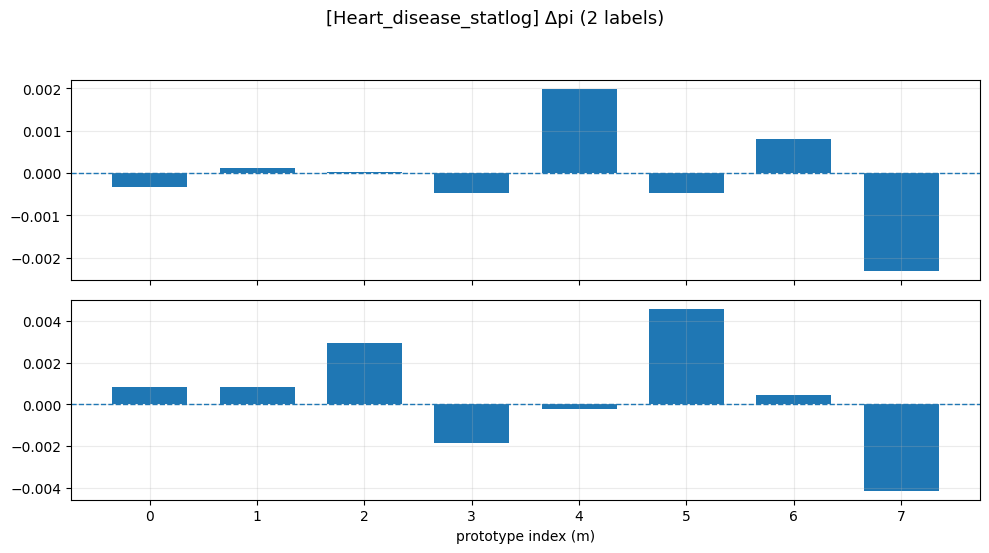

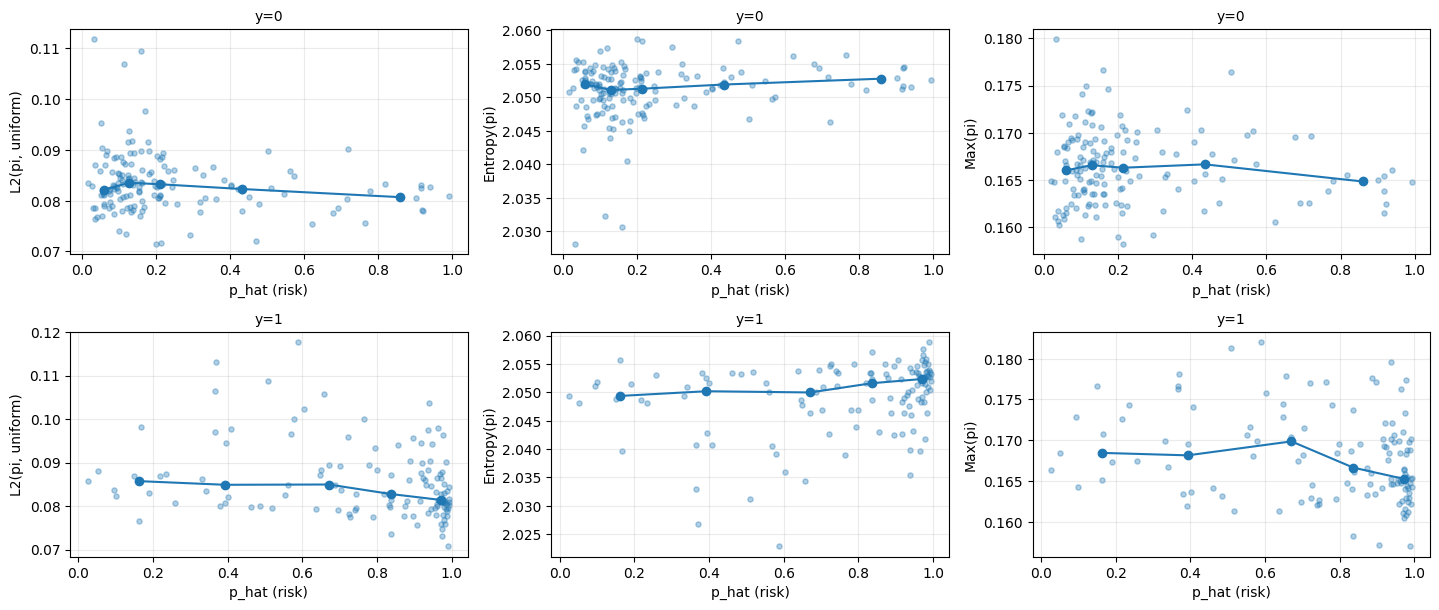

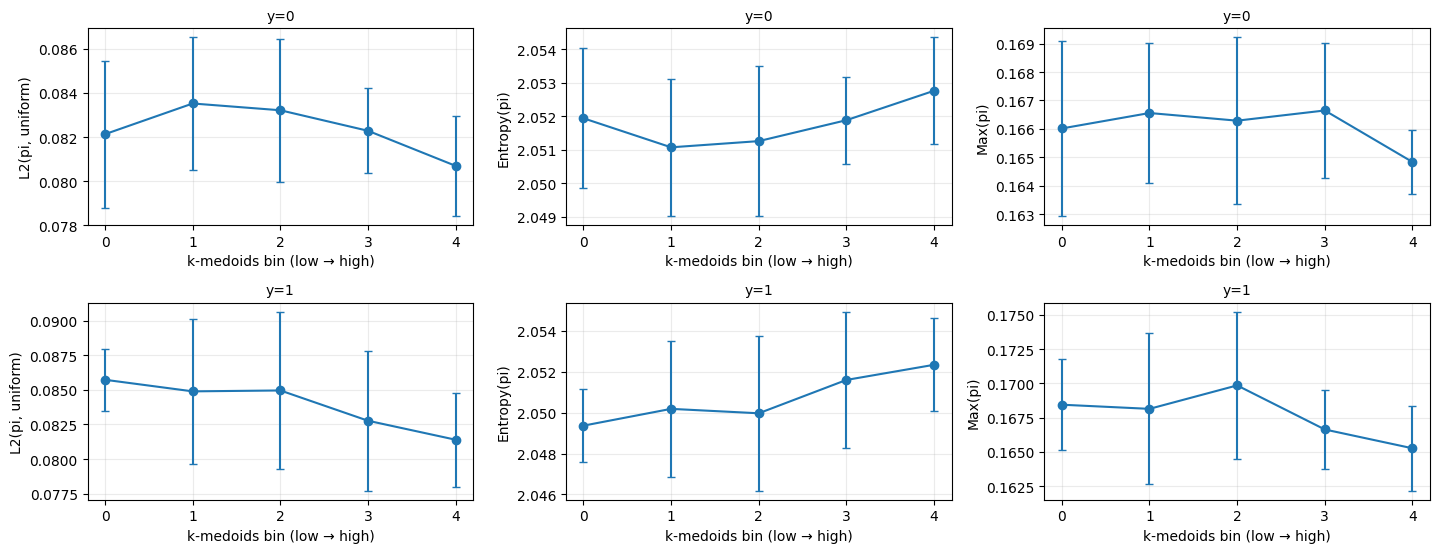

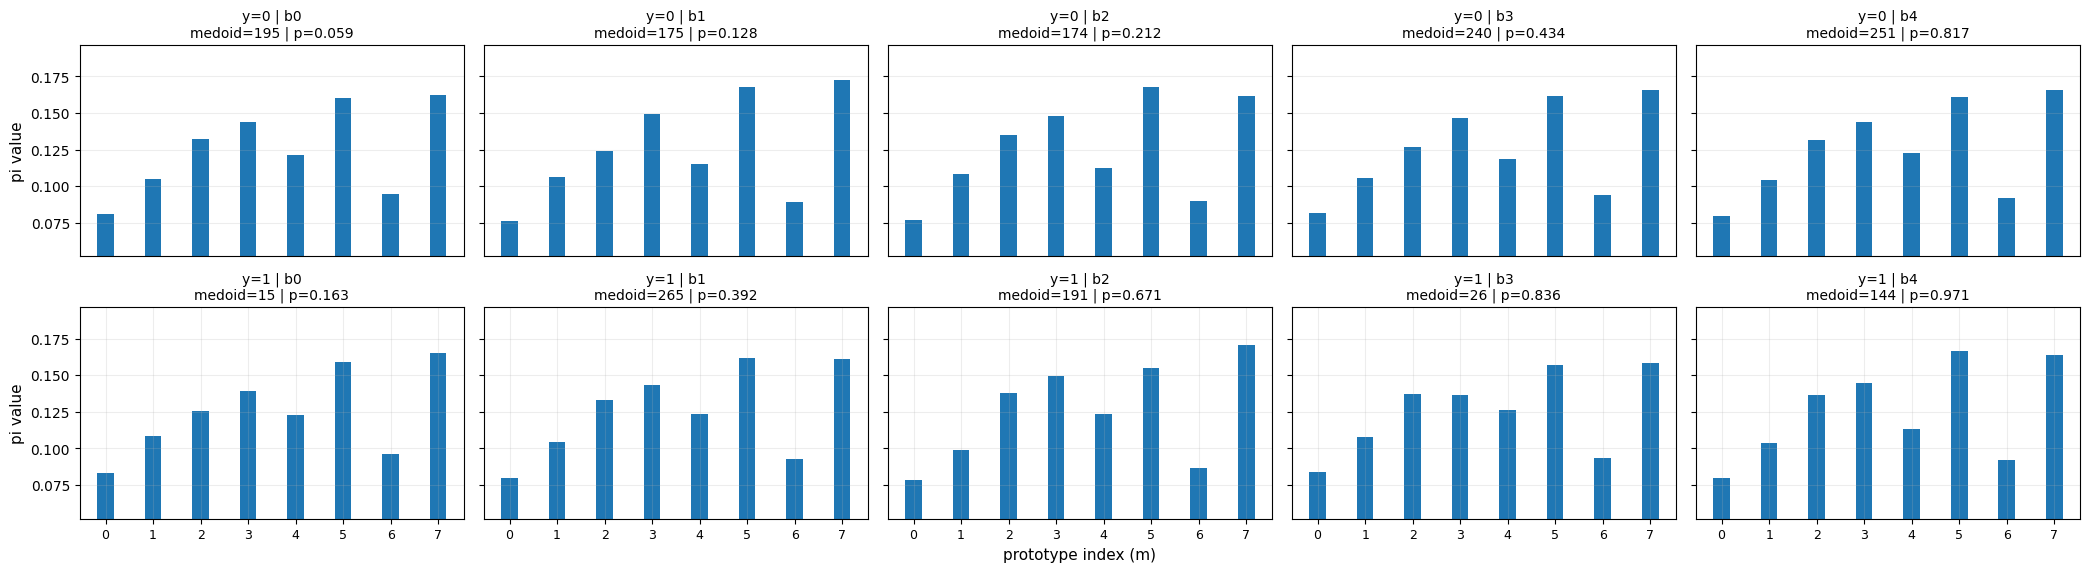

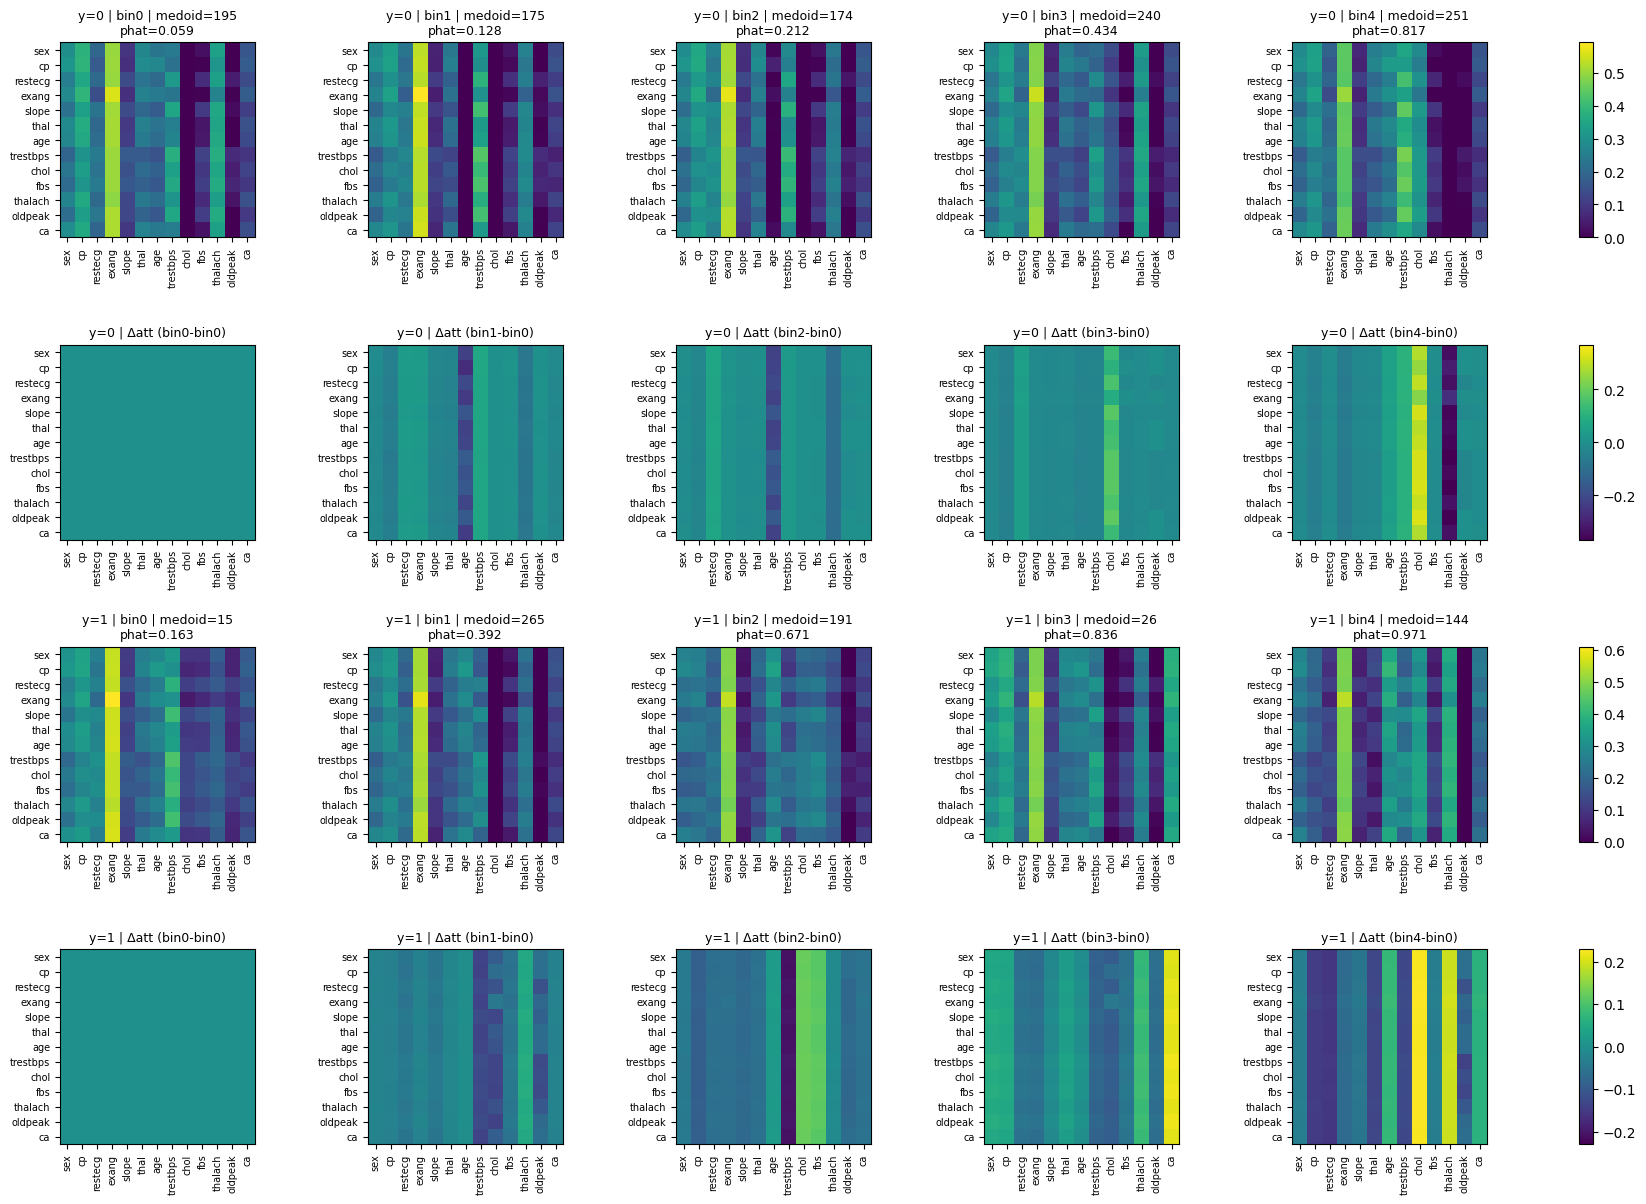

In [47]:
res = plot_source_risk_bins_medoids_coord_att(
    model, loaders, device,
    source_name="heart",
    n_bins=5,
    seed=0,
    center="median",
    tsne_seed=42
)


In [48]:
args.source_data

['Medicaldataset',
 'Cardiovascular_Disease_Dataset',
 'Heart_disease_statlog',
 'Erbil_Cardiovascular_Health_Dataset',
 'cardio_SAheart',
 'heart_failure_clinical_records']

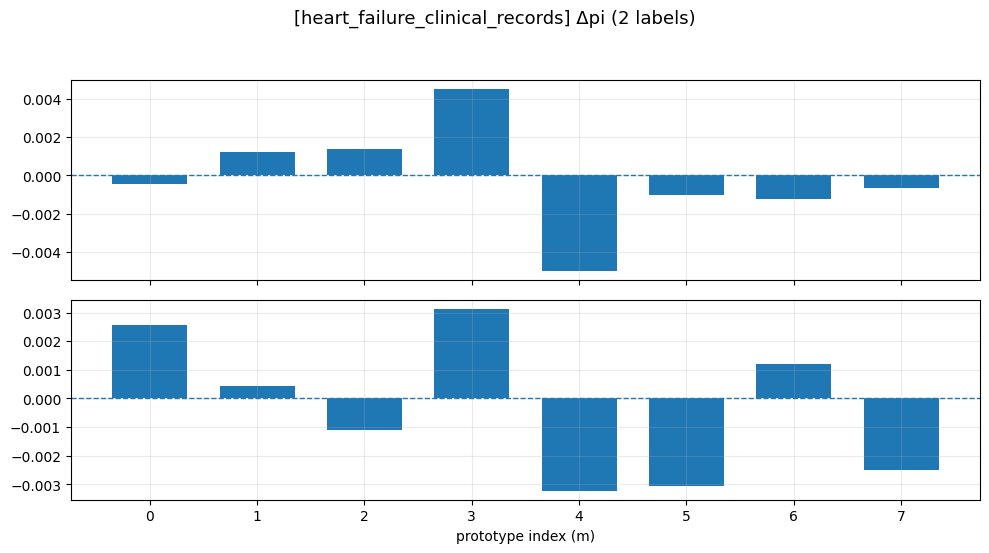

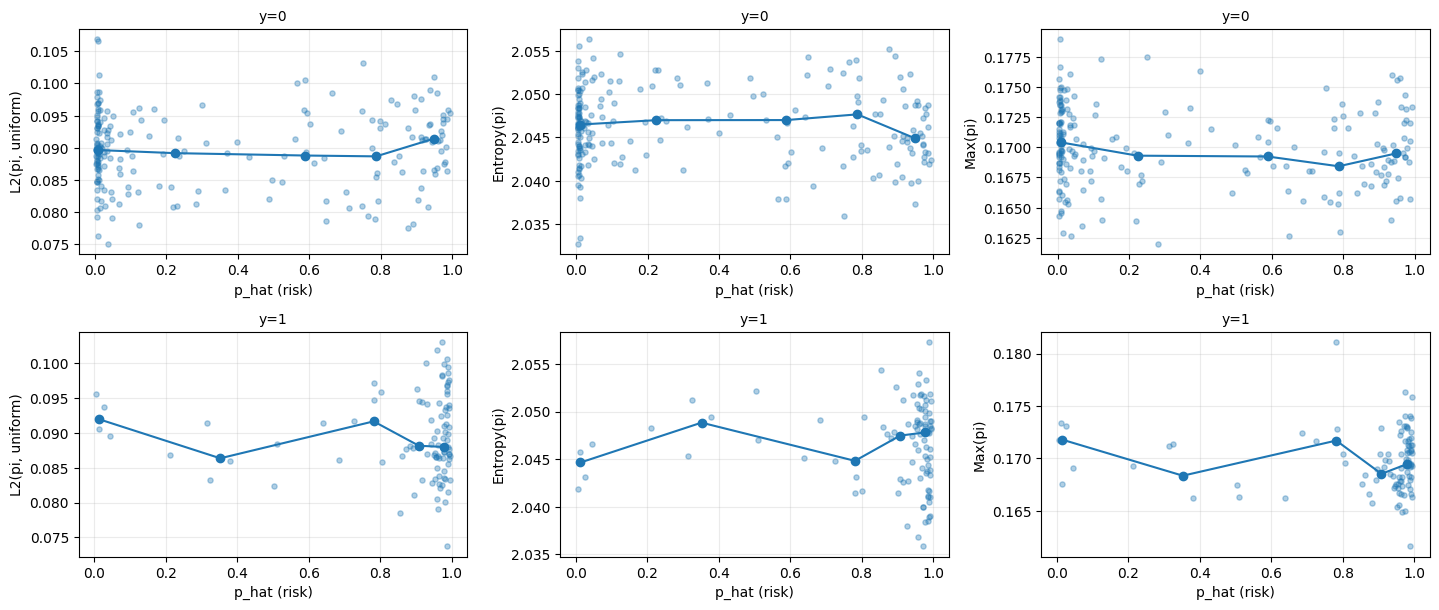

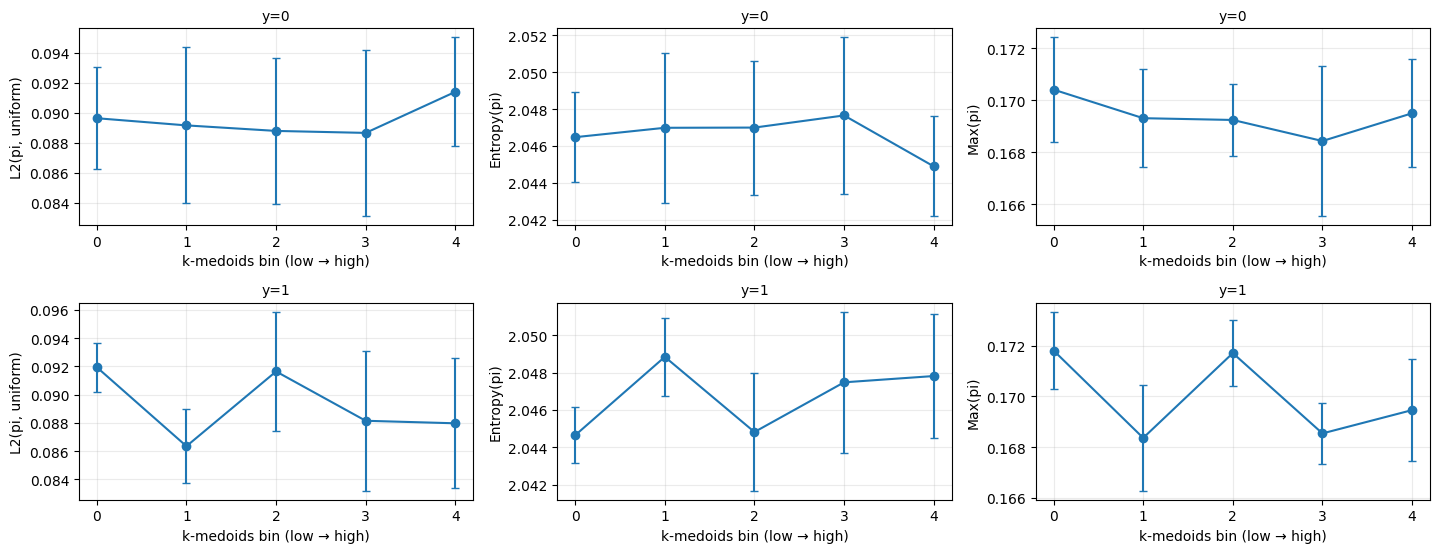

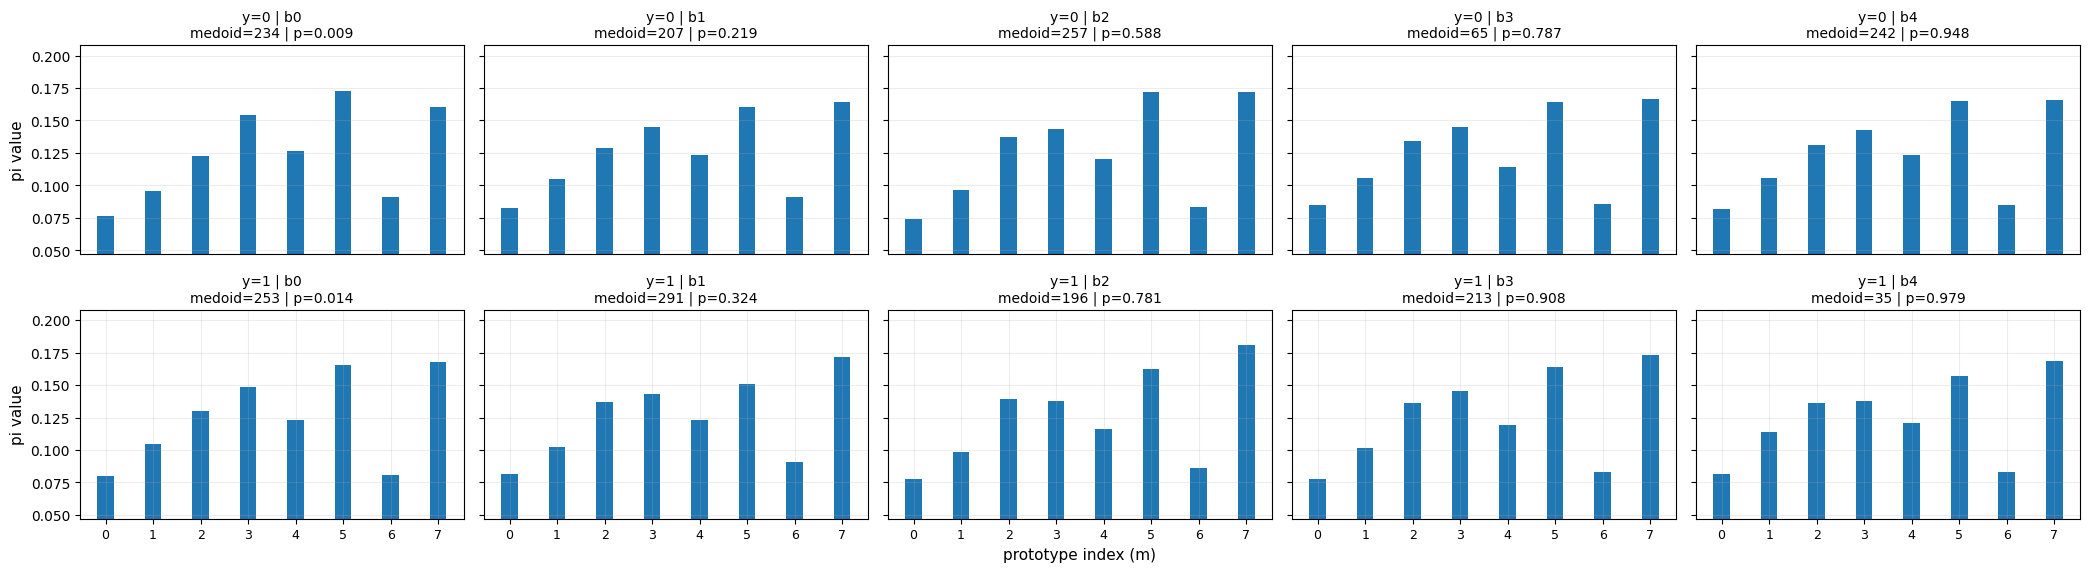

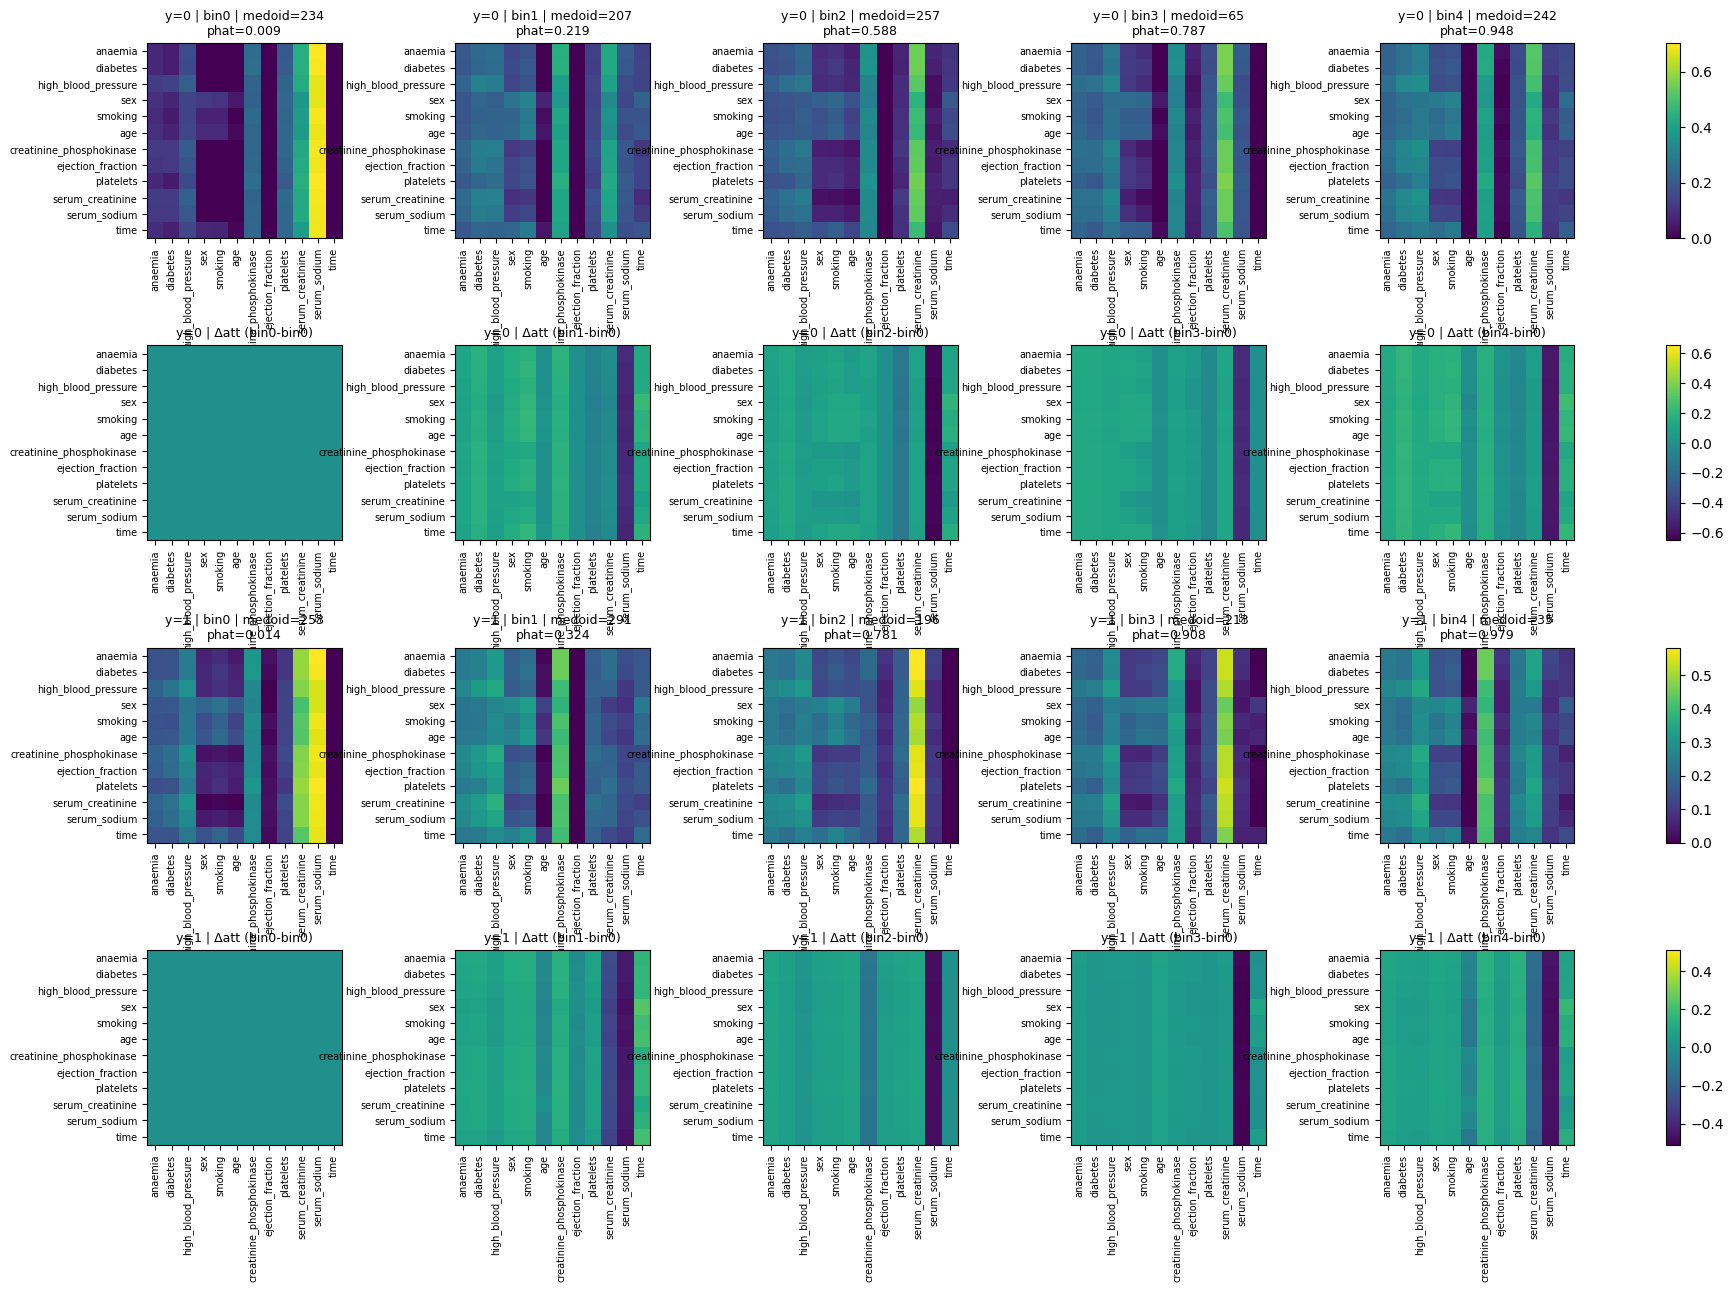

In [49]:
res = plot_source_risk_bins_medoids_coord_att(
    model, loaders, device,
    source_name="heart_failure_clinical_records",
    n_bins=5,
    seed=0,
    center="median",
    tsne_seed=42
)


## Target

In [50]:
ckpt = torch.load(target_rr_ckpt_path, map_location=device)
args = ckpt['args'] if 'args' in ckpt else args  # fallback: 기존 args
sd = ckpt.get('model_state_dict', ckpt.get('state_dict', ckpt))
model = Model(
    args,
    args.input_dim,
    args.hidden_dim,
    args.output_dim,
    args.dropout_rate,
    args.llm_model,
    experiment_id="viz",
    mode="viz"
).to(device)

missing, unexpected = model.load_state_dict(sd, strict=False)
print("Missing keys:", missing)
print("Unexpected keys:", unexpected)

model.eval()


Missing keys: ['graph_quantizer.usage_count', 'graph_quantizer.reset_counter']
Unexpected keys: []


Model(
  (latent_graph): LatentCompositeGraph()
  (graph_quantizer): GraphQuantizer()
  (gnn_experts): LatentCompositeGNN(
    (graph_gnns): ModuleList(
      (0-7): 8 x lightGraphNeuralNet(
        (dropout): Dropout(p=0.2, inplace=False)
        (linear): Linear(in_features=768, out_features=192, bias=True)
        (update): Linear(in_features=192, out_features=768, bias=True)
        (norm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      )
    )
    (readouts): ModuleList(
      (0-7): 8 x GraphReadout(
        (proj): Sequential(
          (0): Linear(in_features=768, out_features=192, bias=True)
          (1): ReLU()
          (2): Dropout(p=0.2, inplace=False)
          (3): Linear(in_features=192, out_features=768, bias=True)
        )
        (norm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      )
    )
  )
  (basis_layers): ModuleList(
    (0-1): 2 x BasisGATLayer_IND(
      (attn_dropout): Dropout(p=0.2, inplace=False)
      (q_proj_list): ModuleLis

In [51]:
args2 = args
fix_seed(args2.random_seed)

# source_data가 리스트일 경우 여러 개
target = args2.source_data if isinstance(args2.target_data, (list, tuple)) else [args2.target_data]

loaders_t = {}
for tgt in target:
    print(f"Loading dataloader for source: {tgt}")
    res = prepare_embedding_dataloaders(args2, tgt)
    tr, va, te = res['loaders']
    
    from torch.utils.data import ConcatDataset, DataLoader
    ds = ConcatDataset([tr.dataset, va.dataset, te.dataset])
    
    loaders_t[tgt] = DataLoader(ds, batch_size=32, shuffle=False)


>>> [System] Seed 50 FIXED. Deterministic algorithms ENABLED.
Loading dataloader for source: Medicaldataset
Loading embeddings from: /storage/personal/eungyeop/dataset/embedding/tabular_embeddings_carte/gpt2_mean/embedding_Medicaldataset.pkl
>>> [DataLoader] Created isolated generator with seed 50
Training data size: 791
Validation data size: 264
Test data size: 264


In [52]:
loaders_t

{'Medicaldataset': <torch.utils.data.dataloader.DataLoader at 0x7f5df12755a0>}

In [53]:
args.target_data

'Medicaldataset'

In [54]:
res = plot_source_risk_bins_medoids_coord_att(
    model, loaders_t, device,
    source_name=args.target_data,
    n_bins=5,
    seed=0,
    center="median",
    tsne_seed=42
)


AttributeError: 'Namespace' object has no attribute 'feat_distance'

In [ ]:
loader_t = loaders_t[tgt]

# 여기서 loader=loader_t 로 넣어야 함
out = run_ref_sim_other_attention_viz(
    model,
    loader=loader_t,          # <-- 이거!
    device=device,
    source_name=tgt,
    extract_feature_names_fn=extract_feature_names,
    reference_idx=16
)